In [412]:
from pathlib import Path

import pandas as pd
import numpy as np


def resolve_meps_dir() -> Path:
    """Walk up from CWD looking for data/MEPS/(excels/)? that contains h248a.xlsx.

    Works whether the kernel CWD is the repo root, Notebooks/, or Notebooks/MEPS/.
    """
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "data" / "MEPS" / "excels",
        cwd / "data" / "MEPS",
        cwd / "MEPS" / "excels",
        cwd / "MEPS",
        cwd,
        cwd.parent / "data" / "MEPS" / "excels",
        cwd.parent / "data" / "MEPS",
        cwd.parent.parent / "data" / "MEPS" / "excels",
        cwd.parent.parent / "data" / "MEPS",
        cwd.parent.parent.parent / "data" / "MEPS" / "excels",
        cwd.parent.parent.parent / "data" / "MEPS",
    ]
    for d in candidates:
        if d.exists() and any(d.glob("h248a.xlsx")):
            return d
    return candidates[0]


MEPS_DIR = resolve_meps_dir()
print(f"MEPS directory: {MEPS_DIR}")


MEPS directory: /Users/friana/Medical Adherence/data/MEPS


In [413]:
df_248 = pd.read_excel(MEPS_DIR / "h248a.xlsx", engine="calamine")

In [414]:
pd.set_option('display.max_columns', None)
df_248.head()

,DUID,PID,DUPERSID,DRUGIDX,RXRECIDX,LINKIDX,PANEL,PURCHRD,RXBEGMM,RXBEGYRX,RXNAME,RXDRGNAM,RXNDC,RXQUANTY,RXFORM,RXFRMUNT,RXSTRENG,RXSTRUNT,RXDAYSUP,PHARTP1,PHARTP2,PHARTP3,PHARTP4,PHARTP5,PHARTP6,RXFLG,IMPFLAG,PCIMPFLG,DIABEQUIP,INPCFLG,TC1,TC1S1,TC1S1_1,TC1S1_2,TC1S2,TC1S2_1,TC1S3,TC1S3_1,TC2,TC2S1,TC2S1_1,TC2S1_2,TC2S2,TC3,TC3S1,TC3S1_1,RXSF23X,RXMR23X,RXMD23X,RXPV23X,RXVA23X,RXTR23X,RXOF23X,RXSL23X,RXWC23X,RXOT23X,RXXP23X,PERWT23F,VARSTR,VARPSU
0,2790002,101,2790002101,2790002101002,2790002101002303001,2790002101002303,27,3,-1,-1,BD PEN NEEDL,-15,8290320550,100.0,MISC,EA,-15,-15,-8,4,-1,-1,-1,-1,-1,1,4,2,1,1,-15,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,13.00,0.0,0.0,41.78,0.0,0.0,0.0,0.0,0.0,0.0,54.78,11664.426815,2019,1
1,2790002,101,2790002101,2790002101006,2790002101006403001,2790002101006403,27,4,5,2023,PREDNISONE,PREDNISONE,591544210,40.0,TABS,EA,10,MG,16,4,4,-1,-1,-1,-1,1,2,1,2,1,97,98,301,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,7.20,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,7.20,11664.426815,2019,1
2,2790002,101,2790002101,2790002101007,2790002101007403001,2790002101007403,27,4,7,2023,PREDNISONE,PREDNISONE,70954006020,10.0,TABS,EA,20,MG,5,4,4,-1,-1,-1,-1,1,5,1,2,1,97,98,301,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,2.39,0.0,0.0,10.93,0.0,0.0,0.0,0.0,0.0,0.0,13.32,11664.426815,2019,1
3,2790002,101,2790002101,2790002101008,2790002101008403001,2790002101008403,27,4,-15,2020,METFORMIN,METFORMIN,70010006305,60.0,TABS,EA,500,MG,30,4,4,-1,-1,-1,-1,1,2,1,2,1,358,99,214,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,6.22,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,6.22,11664.426815,2019,1
4,2790002,101,2790002101,2790002101008,2790002101008403002,2790002101008403,27,4,-15,2020,METFORMIN,METFORMIN,378718505,60.0,TABS,EA,500,MG,30,4,4,-1,-1,-1,-1,1,2,1,2,1,358,99,214,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,6.22,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,6.22,11664.426815,2019,1


In [415]:
clean_df = df_248[["DUPERSID","DRUGIDX","LINKIDX","RXRECIDX","RXDAYSUP","RXNAME","RXBEGYRX","RXBEGMM","RXNDC","RXXP23X","RXSF23X","TC1","TC1S1"]]


clean_df.to_excel(MEPS_DIR / "h248a_clean.xlsx")
pd.set_option('display.max_columns', None)
clean_df.head()

,DUPERSID,DRUGIDX,LINKIDX,RXRECIDX,RXDAYSUP,RXNAME,RXBEGYRX,RXBEGMM,RXNDC,RXXP23X,RXSF23X,TC1,TC1S1
0,2790002101,2790002101002,2790002101002303,2790002101002303001,-8,BD PEN NEEDL,-1,-1,8290320550,54.78,13.00,-15,-1
1,2790002101,2790002101006,2790002101006403,2790002101006403001,16,PREDNISONE,2023,5,591544210,7.20,7.20,97,98
2,2790002101,2790002101007,2790002101007403,2790002101007403001,5,PREDNISONE,2023,7,70954006020,13.32,2.39,97,98
3,2790002101,2790002101008,2790002101008403,2790002101008403001,30,METFORMIN,2020,-15,70010006305,6.22,6.22,358,99
4,2790002101,2790002101008,2790002101008403,2790002101008403002,30,METFORMIN,2020,-15,378718505,6.22,6.22,358,99


In [416]:
clean_df = clean_df[clean_df["RXDAYSUP"]>0]
clean_df.head()




,DUPERSID,DRUGIDX,LINKIDX,RXRECIDX,RXDAYSUP,RXNAME,RXBEGYRX,RXBEGMM,RXNDC,RXXP23X,RXSF23X,TC1,TC1S1
1,2790002101,2790002101006,2790002101006403,2790002101006403001,16,PREDNISONE,2023,5,591544210,7.20,7.20,97,98
2,2790002101,2790002101007,2790002101007403,2790002101007403001,5,PREDNISONE,2023,7,70954006020,13.32,2.39,97,98
3,2790002101,2790002101008,2790002101008403,2790002101008403001,30,METFORMIN,2020,-15,70010006305,6.22,6.22,358,99
4,2790002101,2790002101008,2790002101008403,2790002101008403002,30,METFORMIN,2020,-15,378718505,6.22,6.22,358,99
5,2790002101,2790002101008,2790002101008503,2790002101008503001,30,METFORMIN,2020,-15,68645058259,4.00,4.00,358,99


In [417]:
clean_df = clean_df[clean_df["RXDAYSUP"]<990]
clean_df.shape
#clean_df.head()

(139681, 13)

In [418]:
clean_df["RXBEGYRX"].describe()

count    139681.000000
mean       1644.914197
std         783.855548
min         -15.000000
25%        2003.000000
50%        2018.000000
75%        2022.000000
max        2024.000000
Name: RXBEGYRX, dtype: float64

In [419]:
new_df_invalid = clean_df[clean_df["RXBEGYRX"]<0]
new_df_invalid.shape





(25663, 13)

In [420]:
clean_df = clean_df[clean_df["RXBEGYRX"]>0]
clean_df.shape

(114018, 13)

In [421]:
unique_rxname_df = (
    clean_df[["RXNAME"]]
    .drop_duplicates()
    .sort_values("RXNAME")
    .reset_index(drop=True)
)

unique_rxname_path = MEPS_DIR / "unique_rxname.csv"
unique_rxname_df.to_csv(unique_rxname_path, index=False)

print(f"Saved {len(unique_rxname_df)} unique drug names to {unique_rxname_path}")
unique_rxname_df.head()

Saved 1158 unique drug names to /Users/friana/Medical Adherence/data/MEPS/unique_rxname.csv


,RXNAME
0,-15
1,12HOUR NASAL
2,5-AMINOSALICYLATES
3,600+D3
4,ABILIFY MAIN


In [422]:
clean_df.columns.tolist()

['DUPERSID',
 'DRUGIDX',
 'LINKIDX',
 'RXRECIDX',
 'RXDAYSUP',
 'RXNAME',
 'RXBEGYRX',
 'RXBEGMM',
 'RXNDC',
 'RXXP23X',
 'RXSF23X',
 'TC1',
 'TC1S1']

In [423]:
grouped_clean_df = clean_df.groupby(["DUPERSID","DRUGIDX"]).agg(
    RXDAYSUP = ("RXDAYSUP", "sum"),
    RXXP23X = ("RXXP23X", "mean"),
    RXSF23X = ("RXSF23X", "mean"),
    RXNAME = ("RXNAME", "first"),
    RXNDC = ("RXNDC", "first"),
    RXBEGYRX = ("RXBEGYRX", "first"),
    RXRECIDX = ("RXRECIDX", "first"),
    TC1 = ("TC1", "first"),
    TC1S1 = ("TC1S1", "first"),
    LINKIDX = ("LINKIDX", "first")

   
)

grouped_clean_df.head()

RXDAYSUP  RXXP23X  RXSF23X       RXNAME  \
DUPERSID   DRUGIDX                                                  
2790002101 2790002101006        16    7.200    7.200   PREDNISONE   
           2790002101007         5   13.320    2.390   PREDNISONE   
           2790002101008       150    4.888    3.288    METFORMIN   
           2790002101009        84   21.090    0.000    VITAMIN D   
2790011101 2790011101001       270   10.000   10.000  PRAVASTATIN   

                                RXNDC  RXBEGYRX             RXRECIDX  TC1  \
DUPERSID   DRUGIDX                                                          
2790002101 2790002101006    591544210      2023  2790002101006403001   97   
           2790002101007  70954006020      2023  2790002101007403001   97   
           2790002101008  70010006305      2020  2790002101008403001  358   
           2790002101009  42806054701      2023  2790002101009503001  115   
2790011101 2790011101001     93720298      2021  2790011101001303001  358   

                          TC1S1           LINKIDX  
DUPERSID   DRUGIDX                                 
2790002101 2790002101006     98  2790002101006403  
           2790002101007     98  2790002101007403  
           2790002101008     99  2790002101008403  
           2790002101009    119  2790002101009503  
2790011101 2790011101001     19  2790011101001303

In [424]:
grouped_clean_df["total_days_supply"] = np.where(grouped_clean_df["RXBEGYRX"] <=2023, 365,0).astype(int)

grouped_clean_df.shape

grouped_clean_df["total_days_supply"].describe()
#grouped_clean_df.to_excel(MEPS_DIR / "h248a_grouped.xlsx")


count    35580.000000
mean       364.189573
std         17.180146
min          0.000000
25%        365.000000
50%        365.000000
75%        365.000000
max        365.000000
Name: total_days_supply, dtype: float64

In [425]:
grouped_clean_df = grouped_clean_df[grouped_clean_df["total_days_supply"]>0]


In [426]:
grouped_clean_df["meps_adherence_ratio"] = grouped_clean_df["RXDAYSUP"]/grouped_clean_df["total_days_supply"] *100
grouped_clean_df.head()

RXDAYSUP  RXXP23X  RXSF23X       RXNAME  \
DUPERSID   DRUGIDX                                                  
2790002101 2790002101006        16    7.200    7.200   PREDNISONE   
           2790002101007         5   13.320    2.390   PREDNISONE   
           2790002101008       150    4.888    3.288    METFORMIN   
           2790002101009        84   21.090    0.000    VITAMIN D   
2790011101 2790011101001       270   10.000   10.000  PRAVASTATIN   

                                RXNDC  RXBEGYRX             RXRECIDX  TC1  \
DUPERSID   DRUGIDX                                                          
2790002101 2790002101006    591544210      2023  2790002101006403001   97   
           2790002101007  70954006020      2023  2790002101007403001   97   
           2790002101008  70010006305      2020  2790002101008403001  358   
           2790002101009  42806054701      2023  2790002101009503001  115   
2790011101 2790011101001     93720298      2021  2790011101001303001  358   

                          TC1S1           LINKIDX  total_days_supply  \
DUPERSID   DRUGIDX                                                     
2790002101 2790002101006     98  2790002101006403                365   
           2790002101007     98  2790002101007403                365   
           2790002101008     99  2790002101008403                365   
           2790002101009    119  2790002101009503                365   
2790011101 2790011101001     19  2790011101001303                365   

                          meps_adherence_ratio  
DUPERSID   DRUGIDX                              
2790002101 2790002101006              4.383562  
           2790002101007              1.369863  
           2790002101008             41.095890  
           2790002101009             23.013699  
2790011101 2790011101001             73.972603

In [427]:
grouped_clean_df["RXDAYSUP"].describe()
grouped_clean_df.to_excel(MEPS_DIR / "h248a_Ratio.xlsx")
#grouped_clean_df = pd.read_excel(MEPS_DIR / "h248a_Ratio.xlsx", engine="calamine")


In [428]:
grouped_clean_df.head()

RXDAYSUP  RXXP23X  RXSF23X       RXNAME  \
DUPERSID   DRUGIDX                                                  
2790002101 2790002101006        16    7.200    7.200   PREDNISONE   
           2790002101007         5   13.320    2.390   PREDNISONE   
           2790002101008       150    4.888    3.288    METFORMIN   
           2790002101009        84   21.090    0.000    VITAMIN D   
2790011101 2790011101001       270   10.000   10.000  PRAVASTATIN   

                                RXNDC  RXBEGYRX             RXRECIDX  TC1  \
DUPERSID   DRUGIDX                                                          
2790002101 2790002101006    591544210      2023  2790002101006403001   97   
           2790002101007  70954006020      2023  2790002101007403001   97   
           2790002101008  70010006305      2020  2790002101008403001  358   
           2790002101009  42806054701      2023  2790002101009503001  115   
2790011101 2790011101001     93720298      2021  2790011101001303001  358   

                          TC1S1           LINKIDX  total_days_supply  \
DUPERSID   DRUGIDX                                                     
2790002101 2790002101006     98  2790002101006403                365   
           2790002101007     98  2790002101007403                365   
           2790002101008     99  2790002101008403                365   
           2790002101009    119  2790002101009503                365   
2790011101 2790011101001     19  2790011101001303                365   

                          meps_adherence_ratio  
DUPERSID   DRUGIDX                              
2790002101 2790002101006              4.383562  
           2790002101007              1.369863  
           2790002101008             41.095890  
           2790002101009             23.013699  
2790011101 2790011101001             73.972603

In [429]:
by_drug_class = (
    grouped_clean_df.groupby(["TC1", "TC1S1"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
    .sort_values("meps_adherence_ratio", ascending=False)
)

top_10_highest = by_drug_class.head(10)
top_10_lowest = by_drug_class.tail(10).sort_values("meps_adherence_ratio", ascending=True)

print("Top 10 highest mean adherence:")
display(top_10_highest)

print("Top 10 lowest mean adherence:")
display(top_10_lowest)

Top 10 highest mean adherence:


,TC1,TC1S1,meps_adherence_ratio
20,40,42,74.618696
28,40,51,73.972603
31,40,55,71.518355
25,40,47,70.174942
14,20,23,69.895246
63,97,103,69.685220
105,358,19,69.666603
26,40,48,68.943028
32,40,56,68.796823
64,97,288,67.558421


Top 10 lowest mean adherence:


,TC1,TC1S1,meps_adherence_ratio
73,113,266,1.538462
12,1,240,2.669477
2,1,2,2.669640
9,1,14,3.141128
7,1,11,3.160132
8,1,13,3.248117
81,122,124,3.706194
6,1,9,3.959487
86,122,132,3.988322
93,133,148,4.088514


In [430]:
top_10_highest.to_excel(MEPS_DIR / "h248a_high.xlsx")
top_10_lowest.to_excel(MEPS_DIR / "h248a_low.xlsx")

In [431]:
chronic_df = pd.read_excel(MEPS_DIR / "is_chronic.xlsx", engine="calamine")
chronic_df.head()

,ICD10CDX,ICD10CDX_LABEL,UNWEIGHTED,WEIGHTED_BY_perwt23f,is_chronic
0,-15,CANNOT BE COMPUTED,7557,1.237057e+08,0
1,A08,VIRAL AND OTHER SPECIFIED INTESTINAL INFECTIONS,99,1.921659e+06,0
2,A49,BACTERIAL INFECTION OF UNSPECIFIED SITE,91,1.711817e+06,0
3,B00,HERPESVIRAL [HERPES SIMPLEX] INFECTIONS,91,1.370652e+06,0
4,B02,ZOSTER [HERPES ZOSTER],76,1.294114e+06,0


In [432]:
connecting_df = pd.read_excel(MEPS_DIR / "h248if1.xlsx", engine="calamine")
connecting_df.head()


,DUPERSID,CONDIDX,EVNTIDX,CLNKIDX,EVENTYPE,PANEL
0,2790002101,2790002101001,2790002101001200,27900021010012790002101001201,1,27
1,2790002101,2790002101001,2790002101001801,27900021010012790002101001801,1,27
2,2790002101,2790002101001,2790002101002303,27900021010012790002101002303,8,27
3,2790002101,2790002101004,2790002101001201,27900021010042790002101001201,1,27
4,2790002101,2790002101005,2790002101001301,27900021010052790002101001301,1,27


In [433]:
condition_df = pd.read_excel(MEPS_DIR / "h249.xlsx", engine="calamine")
condition_df.head()

,DUID,PID,DUPERSID,CONDN,CONDIDX,PANEL,CONDRN,AGEDIAG,CRND1,CRND2,CRND3,CRND4,CRND5,INJURY,ACCDNWRK,ICD10CDX,CCSR1X,CCSR2X,CCSR3X,CCSR4X,HHCOND,IPCOND,OPCOND,OBCOND,ERCOND,RXCOND,PERWT23F,VARSTR,VARPSU
0,2790002,101,2790002101,1,2790002101001,27,1,55,-1,-1,1,1,1,2,-1,E11,END002,END005,-1,-1,2,2,2,1,2,1,11664.426815,2019,1
1,2790002,101,2790002101,4,2790002101004,27,3,-1,-1,-1,1,1,0,2,-1,R03,SYM012,-1,-1,-1,2,2,2,1,2,2,11664.426815,2019,1
2,2790002,101,2790002101,5,2790002101005,27,4,-1,-1,-1,0,1,0,2,-1,L30,INJ031,SKN007,-1,-1,2,2,1,1,2,1,11664.426815,2019,1
3,2790002,101,2790002101,6,2790002101006,27,4,-1,-1,-1,0,1,1,2,-1,E11,END002,END005,-1,-1,2,2,2,2,2,1,11664.426815,2019,1
4,2790002,101,2790002101,8,2790002101008,27,5,-1,-1,-1,0,0,1,2,-1,E55,END007,-1,-1,-1,2,2,2,2,2,1,11664.426815,2019,1


In [434]:
condition_df = condition_df[["DUPERSID","CONDIDX","ICD10CDX","AGEDIAG"]]
condition_df.head()

,DUPERSID,CONDIDX,ICD10CDX,AGEDIAG
0,2790002101,2790002101001,E11,55
1,2790002101,2790002101004,R03,-1
2,2790002101,2790002101005,L30,-1
3,2790002101,2790002101006,E11,-1
4,2790002101,2790002101008,E55,-1


In [435]:
condition_df = pd.merge(condition_df,chronic_df, on="ICD10CDX", how="left")
condition_df.head()

,DUPERSID,CONDIDX,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,UNWEIGHTED,WEIGHTED_BY_perwt23f,is_chronic
0,2790002101,2790002101001,E11,55,TYPE 2 DIABETES MELLITUS,2009,28805030.81,1
1,2790002101,2790002101004,R03,-1,"ABNORMAL BLOOD-PRESSURE READING, WITHOUT DIAGN...",56,868076.60,0
2,2790002101,2790002101005,L30,-1,OTHER AND UNSPECIFIED DERMATITIS,210,3803279.08,0
3,2790002101,2790002101006,E11,-1,TYPE 2 DIABETES MELLITUS,2009,28805030.81,1
4,2790002101,2790002101008,E55,-1,VITAMIN D DEFICIENCY,294,4622089.29,0


In [436]:
condition_df = condition_df.drop(columns=["UNWEIGHTED","WEIGHTED_BY_perwt23f"])
condition_df.head()

,DUPERSID,CONDIDX,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,is_chronic
0,2790002101,2790002101001,E11,55,TYPE 2 DIABETES MELLITUS,1
1,2790002101,2790002101004,R03,-1,"ABNORMAL BLOOD-PRESSURE READING, WITHOUT DIAGN...",0
2,2790002101,2790002101005,L30,-1,OTHER AND UNSPECIFIED DERMATITIS,0
3,2790002101,2790002101006,E11,-1,TYPE 2 DIABETES MELLITUS,1
4,2790002101,2790002101008,E55,-1,VITAMIN D DEFICIENCY,0


In [437]:
condition_df = condition_df[condition_df["is_chronic"]>0.0]
condition_df.head()

,DUPERSID,CONDIDX,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,is_chronic
0,2790002101,2790002101001,E11,55,TYPE 2 DIABETES MELLITUS,1
3,2790002101,2790002101006,E11,-1,TYPE 2 DIABETES MELLITUS,1
5,2790006101,2790006101002,E78,70,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,1
6,2790006101,2790006101003,E11,71,TYPE 2 DIABETES MELLITUS,1
7,2790006101,2790006101004,C50,-1,MALIGNANT NEOPLASM OF BREAST,1


In [438]:
condition_df = pd.merge(connecting_df, condition_df, on="CONDIDX", how="left")
condition_df.head()

,DUPERSID_x,CONDIDX,EVNTIDX,CLNKIDX,EVENTYPE,PANEL,DUPERSID_y,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,is_chronic
0,2790002101,2790002101001,2790002101001200,27900021010012790002101001201,1,27,2.790002e+09,E11,55.0,TYPE 2 DIABETES MELLITUS,1.0
1,2790002101,2790002101001,2790002101001801,27900021010012790002101001801,1,27,2.790002e+09,E11,55.0,TYPE 2 DIABETES MELLITUS,1.0
2,2790002101,2790002101001,2790002101002303,27900021010012790002101002303,8,27,2.790002e+09,E11,55.0,TYPE 2 DIABETES MELLITUS,1.0
3,2790002101,2790002101004,2790002101001201,27900021010042790002101001201,1,27,NaN,NaN,NaN,NaN,NaN
4,2790002101,2790002101005,2790002101001301,27900021010052790002101001301,1,27,NaN,NaN,NaN,NaN,NaN


In [439]:
########
condition_df = condition_df.drop(columns=["DUPERSID_y","PANEL"])
condition_df = condition_df.rename(columns={"DUPERSID_x":"DUPERSID"})
condition_df = condition_df[condition_df["EVENTYPE"]==8]
condition_df.head()

,DUPERSID,CONDIDX,EVNTIDX,CLNKIDX,EVENTYPE,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,is_chronic
2,2790002101,2790002101001,2790002101002303,27900021010012790002101002303,8,E11,55.0,TYPE 2 DIABETES MELLITUS,1.0
6,2790002101,2790002101005,2790002101006400,27900021010052790002101006403,8,NaN,NaN,NaN,NaN
7,2790002101,2790002101005,2790002101007403,27900021010052790002101007403,8,NaN,NaN,NaN,NaN
8,2790002101,2790002101006,2790002101008403,27900021010062790002101008403,8,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
9,2790002101,2790002101006,2790002101008503,27900021010062790002101008503,8,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0


In [440]:
merged_df = pd.merge(clean_df, condition_df, left_on="LINKIDX", right_on="EVNTIDX", how="left")
merged_df.head()

,DUPERSID_x,DRUGIDX,LINKIDX,RXRECIDX,RXDAYSUP,RXNAME,RXBEGYRX,RXBEGMM,RXNDC,RXXP23X,RXSF23X,TC1,TC1S1,DUPERSID_y,CONDIDX,EVNTIDX,CLNKIDX,EVENTYPE,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,is_chronic
0,2790002101,2790002101006,2790002101006403,2790002101006403001,16,PREDNISONE,2023,5,591544210,7.20,7.20,97,98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2790002101,2790002101007,2790002101007403,2790002101007403001,5,PREDNISONE,2023,7,70954006020,13.32,2.39,97,98,2.790002e+09,2.790002e+12,2.790002e+15,27900021010052790002101007403,8.0,NaN,NaN,NaN,NaN
2,2790002101,2790002101008,2790002101008403,2790002101008403001,30,METFORMIN,2020,-15,70010006305,6.22,6.22,358,99,2.790002e+09,2.790002e+12,2.790002e+15,27900021010062790002101008403,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
3,2790002101,2790002101008,2790002101008403,2790002101008403002,30,METFORMIN,2020,-15,378718505,6.22,6.22,358,99,2.790002e+09,2.790002e+12,2.790002e+15,27900021010062790002101008403,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
4,2790002101,2790002101008,2790002101008503,2790002101008503001,30,METFORMIN,2020,-15,68645058259,4.00,4.00,358,99,2.790002e+09,2.790002e+12,2.790002e+15,27900021010062790002101008503,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0


In [441]:
merged_df.dropna(subset = ["is_chronic"],inplace=True)
merged_df.head()

,DUPERSID_x,DRUGIDX,LINKIDX,RXRECIDX,RXDAYSUP,RXNAME,RXBEGYRX,RXBEGMM,RXNDC,RXXP23X,RXSF23X,TC1,TC1S1,DUPERSID_y,CONDIDX,EVNTIDX,CLNKIDX,EVENTYPE,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,is_chronic
2,2790002101,2790002101008,2790002101008403,2790002101008403001,30,METFORMIN,2020,-15,70010006305,6.22,6.22,358,99,2.790002e+09,2.790002e+12,2.790002e+15,27900021010062790002101008403,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
3,2790002101,2790002101008,2790002101008403,2790002101008403002,30,METFORMIN,2020,-15,378718505,6.22,6.22,358,99,2.790002e+09,2.790002e+12,2.790002e+15,27900021010062790002101008403,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
4,2790002101,2790002101008,2790002101008503,2790002101008503001,30,METFORMIN,2020,-15,68645058259,4.00,4.00,358,99,2.790002e+09,2.790002e+12,2.790002e+15,27900021010062790002101008503,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
5,2790002101,2790002101008,2790002101008503,2790002101008503002,30,METFORMIN,2020,-15,68645058259,4.00,0.00,358,99,2.790002e+09,2.790002e+12,2.790002e+15,27900021010062790002101008503,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
6,2790002101,2790002101008,2790002101008503,2790002101008503003,30,METFORMIN,2020,-15,68645058259,4.00,0.00,358,99,2.790002e+09,2.790002e+12,2.790002e+15,27900021010062790002101008503,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0


In [442]:
merged_df.drop(columns=["DUPERSID_y"],inplace=True)
merged_df.rename(columns={"DUPERSID_x":"DUPERSID"},inplace=True)
merged_df = merged_df[merged_df["RXBEGYRX"]>0]
merged_df = merged_df[merged_df["RXBEGYRX"]<=2023]
merged_df = merged_df[merged_df["RXDAYSUP"]>0]
merged_df = merged_df[merged_df["RXDAYSUP"]<990]

merged_df.head()



,DUPERSID,DRUGIDX,LINKIDX,RXRECIDX,RXDAYSUP,RXNAME,RXBEGYRX,RXBEGMM,RXNDC,RXXP23X,RXSF23X,TC1,TC1S1,CONDIDX,EVNTIDX,CLNKIDX,EVENTYPE,ICD10CDX,AGEDIAG,ICD10CDX_LABEL,is_chronic
2,2790002101,2790002101008,2790002101008403,2790002101008403001,30,METFORMIN,2020,-15,70010006305,6.22,6.22,358,99,2.790002e+12,2.790002e+15,27900021010062790002101008403,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
3,2790002101,2790002101008,2790002101008403,2790002101008403002,30,METFORMIN,2020,-15,378718505,6.22,6.22,358,99,2.790002e+12,2.790002e+15,27900021010062790002101008403,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
4,2790002101,2790002101008,2790002101008503,2790002101008503001,30,METFORMIN,2020,-15,68645058259,4.00,4.00,358,99,2.790002e+12,2.790002e+15,27900021010062790002101008503,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
5,2790002101,2790002101008,2790002101008503,2790002101008503002,30,METFORMIN,2020,-15,68645058259,4.00,0.00,358,99,2.790002e+12,2.790002e+15,27900021010062790002101008503,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0
6,2790002101,2790002101008,2790002101008503,2790002101008503003,30,METFORMIN,2020,-15,68645058259,4.00,0.00,358,99,2.790002e+12,2.790002e+15,27900021010062790002101008503,8.0,E11,-1.0,TYPE 2 DIABETES MELLITUS,1.0


In [443]:
merged_df.to_excel(MEPS_DIR / "patient_conditions_df.xlsx")

In [444]:
merged_df.columns.to_list()


['DUPERSID',
 'DRUGIDX',
 'LINKIDX',
 'RXRECIDX',
 'RXDAYSUP',
 'RXNAME',
 'RXBEGYRX',
 'RXBEGMM',
 'RXNDC',
 'RXXP23X',
 'RXSF23X',
 'TC1',
 'TC1S1',
 'CONDIDX',
 'EVNTIDX',
 'CLNKIDX',
 'EVENTYPE',
 'ICD10CDX',
 'AGEDIAG',
 'ICD10CDX_LABEL',
 'is_chronic']

In [445]:
# --- Dedup fills before summing days (CLNK multi-condition fix) ---
# A fill (RXRECIDX) linked to N chronic conditions became N rows after
# the CLNK-condition merge. Summing RXDAYSUP on that inflated days N-fold
# and dropped every ICD but the first. Sum on the deduped fills instead;
# condition context is preserved via n_chronic_conditions,
# chronic_conditions (comma-joined list) and the bridge frame below.
fills = merged_df.drop_duplicates(subset=["DUPERSID","DRUGIDX","RXRECIDX"]).copy()
# Valid-month column for the drug-start denominator: keep 1..12, mask sentinels
fills["_valid_month"] = fills["RXBEGMM"].where(fills["RXBEGMM"].between(1, 12))

grouped_merge_df = fills.groupby(["DUPERSID","DRUGIDX"]).agg(
    RXDAYSUP = ("RXDAYSUP", "sum"),
    RXXP23X = ("RXXP23X", "mean"),
    RXSF23X = ("RXSF23X", "mean"),
    RXNAME = ("RXNAME", "first"),
    RXNDC = ("RXNDC", "first"),
    RXBEGYRX = ("RXBEGYRX", "min"),
    first_month = ("_valid_month", "min"),
    TC1 = ("TC1", "first"),
    TC1S1 = ("TC1S1", "first"),
    primary_ICD10CDX = ("ICD10CDX", "first"),
    primary_ICD10CDX_LABEL = ("ICD10CDX_LABEL", "first"),
).reset_index()

# Multi-condition context from the un-deduped merged_df
cond_context = (
    merged_df.dropna(subset=["ICD10CDX"])
    .groupby(["DUPERSID","DRUGIDX"])
    .agg(
        n_chronic_conditions=("ICD10CDX", "nunique"),
        chronic_conditions=("ICD10CDX", lambda s: ",".join(sorted(s.astype(str).unique()))),
    )
    .reset_index()
)
grouped_merge_df = grouped_merge_df.merge(cond_context, on=["DUPERSID","DRUGIDX"], how="left")
grouped_merge_df["n_chronic_conditions"] = grouped_merge_df["n_chronic_conditions"].fillna(0).astype(int)
grouped_merge_df["chronic_conditions"] = grouped_merge_df["chronic_conditions"].fillna("")

# Backwards-compat aliases so downstream cells reading ICD10CDX keep working
grouped_merge_df["ICD10CDX"] = grouped_merge_df["primary_ICD10CDX"]
grouped_merge_df["ICD10CDX_LABEL"] = grouped_merge_df["primary_ICD10CDX_LABEL"]

# Patient-drug x condition bridge for correct condition-level rollups.
# No days-supply columns -- must not be summable by accident.
patient_drug_condition = (
    merged_df.dropna(subset=["ICD10CDX"])[
        ["DUPERSID","DRUGIDX","ICD10CDX","ICD10CDX_LABEL","is_chronic","CONDIDX"]
    ]
    .drop_duplicates(subset=["DUPERSID","DRUGIDX","ICD10CDX","CONDIDX"])
    .reset_index(drop=True)
)

print(f"person-drugs: {len(grouped_merge_df):,}  |  bridge rows: {len(patient_drug_condition):,}")
grouped_merge_df.head()


person-drugs: 21,685  |  bridge rows: 22,590


,DUPERSID,DRUGIDX,RXDAYSUP,RXXP23X,RXSF23X,RXNAME,RXNDC,RXBEGYRX,first_month,TC1,TC1S1,primary_ICD10CDX,primary_ICD10CDX_LABEL,n_chronic_conditions,chronic_conditions,ICD10CDX,ICD10CDX_LABEL
0,2790002101,2790002101008,150,4.888,3.288,METFORMIN,70010006305,2020,NaN,358,99,E11,TYPE 2 DIABETES MELLITUS,1,E11,E11,TYPE 2 DIABETES MELLITUS
1,2790011101,2790011101001,270,10.000,10.000,PRAVASTATIN,93720298,2021,12.0,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,1,E78,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...
2,2790011101,2790011101002,180,8.420,3.630,AMLODIPINE,68180072003,2022,10.0,40,48,I10,ESSENTIAL (PRIMARY) HYPERTENSION,1,I10,I10,ESSENTIAL (PRIMARY) HYPERTENSION
3,2790011102,2790011102002,180,16.900,3.000,LOSARTAN POT,65862020299,2021,12.0,40,56,I10,ESSENTIAL (PRIMARY) HYPERTENSION,1,I10,I10,ESSENTIAL (PRIMARY) HYPERTENSION
4,2790011102,2790011102007,30,5.620,2.330,ATORVASTATIN,43598083005,2023,7.0,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,1,E78,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...


In [446]:
grouped_merge_df["total_valid_days"] = np.minimum(grouped_merge_df["RXDAYSUP"], 365).astype(int)

In [447]:
# Drug-start-days denominator: days from earliest fill's month to Dec 31.
# Falls back to 365 when the drug started before this year OR when the
# start-month is a MEPS sentinel (-1/-7/-8/-15). Assumption: missing
# month means patient's been on it a long time and doesn't remember.
import datetime as _dt
_YEAR = 2023
_year_end = _dt.date(_YEAR, 12, 31)
_days_by_month = {m: (_year_end - _dt.date(_YEAR, m, 1)).days + 1 for m in range(1, 13)}

def _drug_start_days(first_year, first_month):
    if pd.isna(first_year) or first_year != _YEAR:
        return 365
    if pd.isna(first_month) or not (1 <= int(first_month) <= 12):
        return 365
    return _days_by_month[int(first_month)]

grouped_merge_df["drug_start_days"] = grouped_merge_df.apply(
    lambda r: _drug_start_days(r["RXBEGYRX"], r["first_month"]), axis=1
).astype(int)

grouped_merge_df["total_days_supply"] = np.where(
    grouped_merge_df["RXBEGYRX"] <= 2023,
    grouped_merge_df["drug_start_days"], 0
).astype(int)


In [448]:
grouped_merge_df["total_valid_days"] = np.minimum(
    grouped_merge_df["total_valid_days"],
    grouped_merge_df["total_days_supply"],
)

grouped_merge_df["meps_adherence_ratio"] = np.where(
    grouped_merge_df["total_days_supply"].eq(0),
    np.nan,
    grouped_merge_df["total_valid_days"] / grouped_merge_df["total_days_supply"] * 100,
)
grouped_merge_df.head()


,DUPERSID,DRUGIDX,RXDAYSUP,RXXP23X,RXSF23X,RXNAME,RXNDC,RXBEGYRX,first_month,TC1,TC1S1,primary_ICD10CDX,primary_ICD10CDX_LABEL,n_chronic_conditions,chronic_conditions,ICD10CDX,ICD10CDX_LABEL,total_valid_days,drug_start_days,total_days_supply,meps_adherence_ratio
0,2790002101,2790002101008,150,4.888,3.288,METFORMIN,70010006305,2020,NaN,358,99,E11,TYPE 2 DIABETES MELLITUS,1,E11,E11,TYPE 2 DIABETES MELLITUS,150,365,365,41.095890
1,2790011101,2790011101001,270,10.000,10.000,PRAVASTATIN,93720298,2021,12.0,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,1,E78,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,270,365,365,73.972603
2,2790011101,2790011101002,180,8.420,3.630,AMLODIPINE,68180072003,2022,10.0,40,48,I10,ESSENTIAL (PRIMARY) HYPERTENSION,1,I10,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,365,365,49.315068
3,2790011102,2790011102002,180,16.900,3.000,LOSARTAN POT,65862020299,2021,12.0,40,56,I10,ESSENTIAL (PRIMARY) HYPERTENSION,1,I10,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,365,365,49.315068
4,2790011102,2790011102007,30,5.620,2.330,ATORVASTATIN,43598083005,2023,7.0,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,1,E78,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,30,184,184,16.304348


In [449]:
grouped_merge_df["meps_adherence_ratio"].describe()

count    21685.000000
mean        55.563567
std         33.525447
min          0.273973
25%         24.657534
50%         49.315068
75%         91.232877
max        100.000000
Name: meps_adherence_ratio, dtype: float64

In [450]:
patient_adherence = (
    grouped_merge_df.reset_index()
    .query("total_days_supply > 0")
    .groupby("DUPERSID", as_index=False)
    .agg(
        total_valid_days=("total_valid_days", "sum"),
        total_days_supply=("total_days_supply", "sum"),
        drug_count=("DRUGIDX", "count"),
    )
)
patient_adherence["meps_adherence_ratio"] = (
    patient_adherence["total_valid_days"] / patient_adherence["total_days_supply"] * 100
)

top_10_high = patient_adherence.nlargest(10, "meps_adherence_ratio")
top_10_low = patient_adherence.nsmallest(10, "meps_adherence_ratio")

output_dir = str(MEPS_DIR)
top_10_high.to_excel(f"{output_dir}/top_10_high.xlsx", index=False)
top_10_low.to_excel(f"{output_dir}/top_10_low.xlsx", index=False)

print("Top 10 patients with highest adherence:")
display(top_10_high)

print("Top 10 patients with lowest adherence:")
display(top_10_low)

Top 10 patients with highest adherence:


,DUPERSID,total_valid_days,total_days_supply,drug_count,meps_adherence_ratio
42,2790152107,365,365,1,100.0
59,2790212101,730,730,2,100.0
64,2790234101,730,730,2,100.0
65,2790234102,365,365,1,100.0
68,2790241102,1095,1095,3,100.0
103,2790368101,153,153,1,100.0
134,2790482101,61,61,1,100.0
146,2790501102,365,365,1,100.0
154,2790551101,365,365,1,100.0
192,2790702101,365,365,1,100.0


Top 10 patients with lowest adherence:


,DUPERSID,total_valid_days,total_days_supply,drug_count,meps_adherence_ratio
3450,2811117101,1,365,1,0.273973
4384,2813661102,1,365,1,0.273973
6412,2818704101,1,365,1,0.273973
3063,2810218101,1,334,1,0.299401
2597,2798387102,2,365,1,0.547945
4132,2813008103,2,365,1,0.547945
6354,2818557102,2,365,1,0.547945
2145,2796996102,2,334,1,0.598802
1614,2795311101,2,275,1,0.727273
2750,2798911101,2,214,1,0.934579


In [451]:
patient_drug_df = (
    grouped_merge_df.reset_index()
    .query("total_days_supply > 0")
)

top_10_high = patient_drug_df.nlargest(10, "meps_adherence_ratio")
top_10_low = patient_drug_df.nsmallest(10, "meps_adherence_ratio")

output_dir = str(MEPS_DIR)
top_10_high.to_excel(f"{output_dir}/top_10_high.xlsx", index=False)
top_10_low.to_excel(f"{output_dir}/top_10_low.xlsx", index=False)

print("Top 10 patient-drug pairs with highest adherence:")
display(top_10_high)

print("Top 10 patient-drug pairs with lowest adherence:")
display(top_10_low)

Top 10 patient-drug pairs with highest adherence:


,index,DUPERSID,DRUGIDX,RXDAYSUP,RXXP23X,RXSF23X,RXNAME,RXNDC,RXBEGYRX,first_month,TC1,TC1S1,primary_ICD10CDX,primary_ICD10CDX_LABEL,n_chronic_conditions,chronic_conditions,ICD10CDX,ICD10CDX_LABEL,total_valid_days,drug_start_days,total_days_supply,meps_adherence_ratio
44,44,2790051101,2790051101016,88,3147.640,0.000,LANTUS,88222033,2023,12.0,358,99,E11,TYPE 2 DIABETES MELLITUS,1,E11,E11,TYPE 2 DIABETES MELLITUS,31,31,31,100.0
50,50,2790067101,2790067101003,450,3.310,0.000,ATENOLOL,93078701,2005,NaN,40,47,I10,ESSENTIAL (PRIMARY) HYPERTENSION,1,I10,I10,ESSENTIAL (PRIMARY) HYPERTENSION,365,365,365,100.0
51,51,2790067101,2790067101006,460,1.460,0.000,LOSARTAN POT,43547036009,2005,NaN,40,56,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,1,E78,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,365,365,365,100.0
89,89,2790115101,2790115101005,360,15.000,15.000,MONTELUKAST,72865017590,2023,2.0,122,243,J30,VASOMOTOR AND ALLERGIC RHINITIS,1,J30,J30,VASOMOTOR AND ALLERGIC RHINITIS,334,334,334,100.0
92,92,2790119102,2790119102004,450,23.460,11.356,TRAZODONE,50111056101,2019,NaN,242,249,G47,SLEEP DISORDERS,1,G47,G47,SLEEP DISORDERS,365,365,365,100.0
104,104,2790150101,2790150101001,450,517.030,192.375,LUMIGAN,23320505,2020,NaN,133,147,H40,GLAUCOMA,1,H40,H40,GLAUCOMA,365,365,365,100.0
105,105,2790150101,2790150101002,800,4.100,4.100,TIMOLOL MAL,61314022710,2020,NaN,133,147,H40,GLAUCOMA,1,H40,H40,GLAUCOMA,365,365,365,100.0
107,107,2790150101,2790150101005,270,5.900,5.900,HYDROCHLOROT,29300012901,2023,11.0,40,49,I10,ESSENTIAL (PRIMARY) HYPERTENSION,1,I10,I10,ESSENTIAL (PRIMARY) HYPERTENSION,61,61,61,100.0
111,111,2790152107,2790152107002,810,5.590,5.590,ATORVASTATIN,378395177,2015,NaN,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,1,E78,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,365,365,365,100.0
113,113,2790161101,2790161101006,380,10.555,0.000,LISINOPRIL,68645055354,2000,NaN,40,42,I10,ESSENTIAL (PRIMARY) HYPERTENSION,1,I10,I10,ESSENTIAL (PRIMARY) HYPERTENSION,365,365,365,100.0


Top 10 patient-drug pairs with lowest adherence:


,index,DUPERSID,DRUGIDX,RXDAYSUP,RXXP23X,RXSF23X,RXNAME,RXNDC,RXBEGYRX,first_month,TC1,TC1S1,primary_ICD10CDX,primary_ICD10CDX_LABEL,n_chronic_conditions,chronic_conditions,ICD10CDX,ICD10CDX_LABEL,total_valid_days,drug_start_days,total_days_supply,meps_adherence_ratio
11116,11116,2811117101,2811117101004,1,0.13,0.13,LORAZEPAM,69315090405,2017,NaN,57,64,F41,OTHER ANXIETY DISORDERS,1,F41,F41,OTHER ANXIETY DISORDERS,1,365,365,0.273973
11510,11510,2811472101,2811472101008,1,0.16,0.16,CLONIDINE,62332005471,2016,NaN,40,44,I10,ESSENTIAL (PRIMARY) HYPERTENSION,1,I10,I10,ESSENTIAL (PRIMARY) HYPERTENSION,1,365,365,0.273973
12379,12379,2812273102,2812273102005,1,1.37,1.37,HYDROXYZ PAM,115180301,2019,NaN,57,67,F41,OTHER ANXIETY DISORDERS,1,F41,F41,OTHER ANXIETY DISORDERS,1,365,365,0.273973
14127,14127,2813648102,2813648102004,1,5.99,5.99,DIAZEPAM,172392670,2008,NaN,57,64,F41,OTHER ANXIETY DISORDERS,1,F41,F41,OTHER ANXIETY DISORDERS,1,365,365,0.273973
14136,14136,2813661102,2813661102001,1,12.00,12.00,DIAZEPAM,172392570,2020,NaN,57,64,F41,OTHER ANXIETY DISORDERS,1,F41,F41,OTHER ANXIETY DISORDERS,1,365,365,0.273973
15717,15717,2814839101,2814839101008,1,23.36,23.36,POLYETH GLYC,45802086803,2021,NaN,87,95,K21,GASTRO-ESOPHAGEAL REFLUX DISEASE,1,K21,K21,GASTRO-ESOPHAGEAL REFLUX DISEASE,1,365,365,0.273973
16084,16084,2815174101,2815174101002,1,4.00,0.82,AMOX/K CLAV,143924920,1996,NaN,1,13,J32,CHRONIC SINUSITIS,1,J32,J32,CHRONIC SINUSITIS,1,365,365,0.273973
16682,16682,2815729101,2815729101007,1,4.00,4.00,XANAX,52959016220,2022,11.0,57,67,F41,OTHER ANXIETY DISORDERS,1,F41,F41,OTHER ANXIETY DISORDERS,1,365,365,0.273973
17955,17955,2816685101,2816685101004,1,276.75,15.00,EPINEPHRINE,115169449,1998,NaN,40,54,J45,ASTHMA,1,J45,J45,ASTHMA,1,365,365,0.273973
18603,18603,2817209101,2817209101005,1,4.00,2.65,XANAX,52959016220,2015,NaN,57,67,F41,OTHER ANXIETY DISORDERS,1,F41,F41,OTHER ANXIETY DISORDERS,1,365,365,0.273973


In [452]:
adherence_threshold = 60


In [453]:
print(grouped_merge_df["ICD10CDX"].nunique())
print(grouped_merge_df["TC1"].nunique())
print(grouped_merge_df["RXNAME"].nunique())
print(grouped_merge_df["TC1S1"].nunique())

74
17
757
89


In [454]:
grouped_merge_df.to_excel(MEPS_DIR / "grouped_merge_df.xlsx")

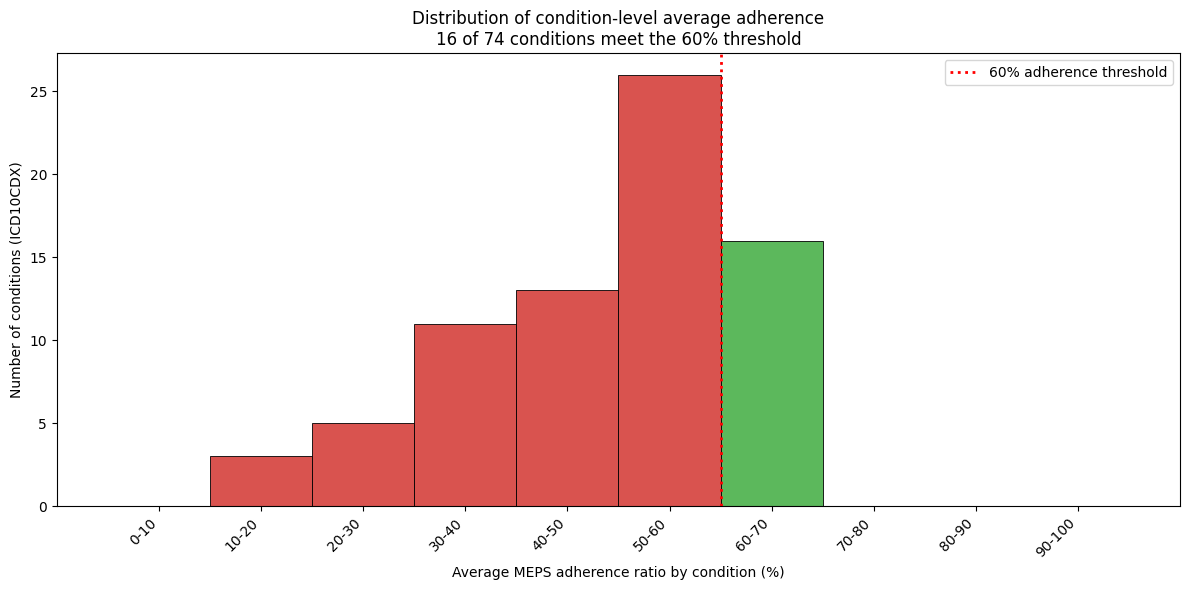

Adherent conditions (>=60%):


,ICD10CDX,ICD10CDX_LABEL,meps_adherence_ratio
9,E03,OTHER HYPOTHYROIDISM,67.398037
15,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,66.374691
34,I10,ESSENTIAL (PRIMARY) HYPERTENSION,65.419894
23,F84,PERVASIVE DEVELOPMENTAL DISORDERS,64.272540
21,F39,UNSPECIFIED MOOD [AFFECTIVE] DISORDER,63.972146
19,F31,BIPOLAR DISORDER,63.955711
68,N40,BENIGN PROSTATIC HYPERPLASIA,63.903689
36,I25,CHRONIC ISCHEMIC HEART DISEASE,63.577007
66,N18,CHRONIC KIDNEY DISEASE (CKD),63.042035
71,R54,AGE-RELATED PHYSICAL DEBILITY,62.916291


In [455]:
import matplotlib.pyplot as plt

by_condition = (
    grouped_merge_df.reset_index()
    .groupby(["ICD10CDX", "ICD10CDX_LABEL"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
)

adherence_threshold = 60
bins = np.arange(0, 110, 10)

fig, ax = plt.subplots(figsize=(12, 6))
counts, edges, patches = ax.hist(
    by_condition["meps_adherence_ratio"],
    bins=bins,
    edgecolor="black",
    linewidth=0.6,
)

for patch, left, right in zip(patches, edges[:-1], edges[1:]):
    if right <= adherence_threshold:
        patch.set_facecolor("#d9534f")
    elif left >= adherence_threshold:
        patch.set_facecolor("#5cb85c")
    else:
        patch.set_facecolor("#f0ad4e")

ax.axvline(
    adherence_threshold,
    color="red",
    linestyle=":",
    linewidth=2,
    label=f"{adherence_threshold}% adherence threshold",
)

bin_labels = [f"{int(left)}-{int(right)}" for left, right in zip(edges[:-1], edges[1:])]
ax.set_xticks(edges[:-1] + 5)
ax.set_xticklabels(bin_labels, rotation=45, ha="right")

n_adherent = (by_condition["meps_adherence_ratio"] >= adherence_threshold).sum()
n_total = len(by_condition)

ax.set_xlabel("Average MEPS adherence ratio by condition (%)")
ax.set_ylabel("Number of conditions (ICD10CDX)")
ax.set_title(
    f"Distribution of condition-level average adherence\n"
    f"{n_adherent} of {n_total} conditions meet the {adherence_threshold}% threshold"
)
ax.legend()
plt.tight_layout()
plt.show()

adherent_conditions = by_condition[
    by_condition["meps_adherence_ratio"] >= adherence_threshold
].sort_values("meps_adherence_ratio", ascending=False)

print(f"Adherent conditions (>={adherence_threshold}%):")
display(adherent_conditions)

Pearson correlation with meps_adherence_ratio
(ICD10CDX uses label encoding; interpret as a weak linear proxy only)



,pearson_r
ICD10CDX_code,-0.184808
TC1,0.146296
TC1S1,-0.018509



Eta-squared with meps_adherence_ratio
(better measure for categorical variables: share of variance explained)



,eta_squared
ICD10CDX,0.135774
TC1,0.123422
TC1S1,0.175575



Combined model: ICD10CDX + TC1 + TC1S1 together
  R-squared: 0.1905
  Adjusted R-squared: 0.1838


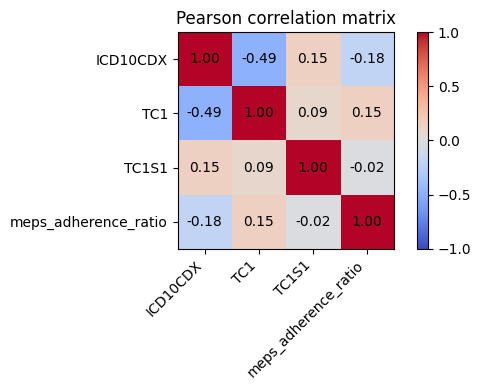

In [456]:
from sklearn.preprocessing import LabelEncoder

corr_df = grouped_merge_df.reset_index()[
    ["ICD10CDX", "TC1", "TC1S1", "meps_adherence_ratio"]
].dropna()

corr_df["ICD10CDX_code"] = LabelEncoder().fit_transform(corr_df["ICD10CDX"].astype(str))


def eta_squared(categorical, continuous):
    """Share of adherence variance explained by a categorical variable."""
    categories = categorical.astype(str)
    grand_mean = continuous.mean()
    ss_total = ((continuous - grand_mean) ** 2).sum()
    ss_between = sum(
        len(continuous[categories == cat]) * (continuous[categories == cat].mean() - grand_mean) ** 2
        for cat in categories.unique()
    )
    return ss_between / ss_total if ss_total > 0 else np.nan


pearson_corr = corr_df[
    ["ICD10CDX_code", "TC1", "TC1S1", "meps_adherence_ratio"]
].corr(method="pearson")

pearson_with_adherence = pearson_corr["meps_adherence_ratio"].drop("meps_adherence_ratio")

eta_results = pd.Series(
    {
        "ICD10CDX": eta_squared(corr_df["ICD10CDX"], corr_df["meps_adherence_ratio"]),
        "TC1": eta_squared(corr_df["TC1"], corr_df["meps_adherence_ratio"]),
        "TC1S1": eta_squared(corr_df["TC1S1"], corr_df["meps_adherence_ratio"]),
    },
    name="eta_squared",
)

X = pd.get_dummies(
    corr_df[["ICD10CDX", "TC1", "TC1S1"]].astype(str),
    drop_first=True,
).astype(float)
y = corr_df["meps_adherence_ratio"].values
X_with_intercept = np.column_stack([np.ones(len(X)), X.values])
coeffs, _, _, _ = np.linalg.lstsq(X_with_intercept, y, rcond=None)
y_pred = X_with_intercept @ coeffs
ss_res = ((y - y_pred) ** 2).sum()
ss_tot = ((y - y.mean()) ** 2).sum()
combined_r2 = 1 - ss_res / ss_tot
n, p = len(y), X.shape[1]
adj_r2 = 1 - (1 - combined_r2) * (n - 1) / (n - p - 1)

print("Pearson correlation with meps_adherence_ratio")
print("(ICD10CDX uses label encoding; interpret as a weak linear proxy only)\n")
display(pearson_with_adherence.to_frame("pearson_r"))

print("\nEta-squared with meps_adherence_ratio")
print("(better measure for categorical variables: share of variance explained)\n")
display(eta_results.to_frame())

print("\nCombined model: ICD10CDX + TC1 + TC1S1 together")
print(f"  R-squared: {combined_r2:.4f}")
print(f"  Adjusted R-squared: {adj_r2:.4f}")

heatmap_data = pearson_corr.loc[
    ["ICD10CDX_code", "TC1", "TC1S1", "meps_adherence_ratio"],
    ["ICD10CDX_code", "TC1", "TC1S1", "meps_adherence_ratio"],
].rename(index={"ICD10CDX_code": "ICD10CDX"}, columns={"ICD10CDX_code": "ICD10CDX"})

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(heatmap_data.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=45, ha="right")
ax.set_yticks(range(len(heatmap_data.index)), heatmap_data.index)
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        ax.text(j, i, f"{heatmap_data.iloc[i, j]:.2f}", ha="center", va="center", color="black")
fig.colorbar(im, ax=ax)
ax.set_title("Pearson correlation matrix")
plt.tight_layout()
plt.show()

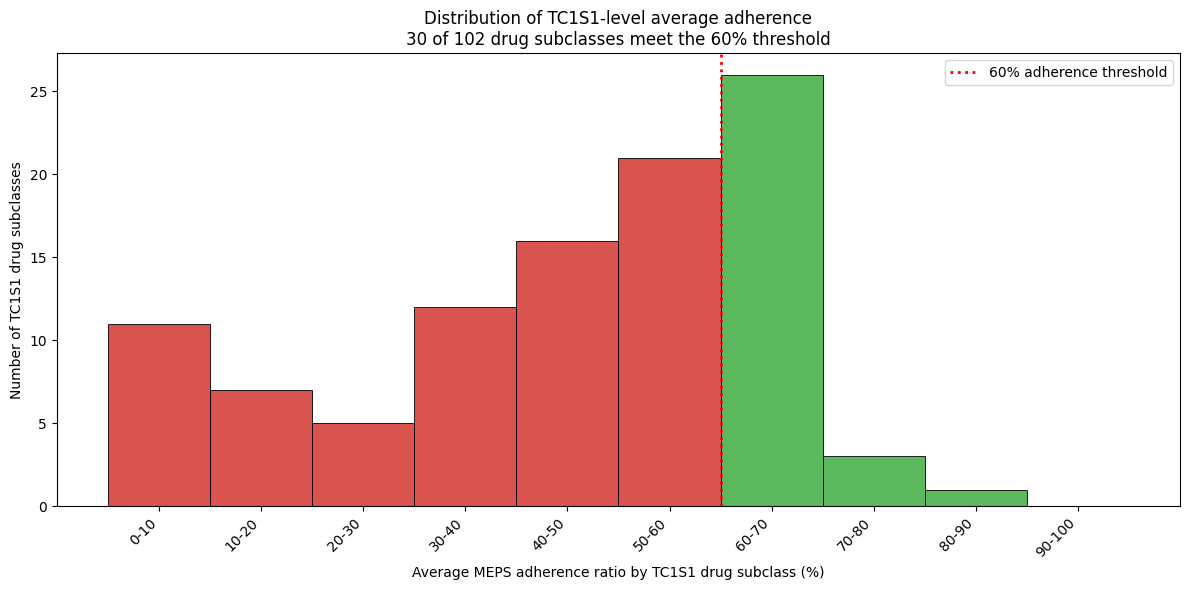

Adherent TC1S1 drug subclasses (>=60%):


,TC1,TC1S1,meps_adherence_ratio
27,40,51,82.191781
73,115,116,78.982004
77,122,-15,71.554826
44,57,313,70.430446
63,97,288,69.034357
13,20,-15,68.860278
30,40,55,68.412763
95,242,504,68.027356
62,97,103,67.145668
19,40,42,67.138257


In [457]:
by_tc1s1 = (
    grouped_merge_df.reset_index()
    .groupby(["TC1", "TC1S1"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
)

adherence_threshold = 60
bins = np.arange(0, 110, 10)

fig, ax = plt.subplots(figsize=(12, 6))
counts, edges, patches = ax.hist(
    by_tc1s1["meps_adherence_ratio"],
    bins=bins,
    edgecolor="black",
    linewidth=0.6,
)

for patch, left, right in zip(patches, edges[:-1], edges[1:]):
    if right <= adherence_threshold:
        patch.set_facecolor("#d9534f")
    elif left >= adherence_threshold:
        patch.set_facecolor("#5cb85c")
    else:
        patch.set_facecolor("#f0ad4e")

ax.axvline(
    adherence_threshold,
    color="red",
    linestyle=":",
    linewidth=2,
    label=f"{adherence_threshold}% adherence threshold",
)

bin_labels = [f"{int(left)}-{int(right)}" for left, right in zip(edges[:-1], edges[1:])]
ax.set_xticks(edges[:-1] + 5)
ax.set_xticklabels(bin_labels, rotation=45, ha="right")

n_adherent = (by_tc1s1["meps_adherence_ratio"] >= adherence_threshold).sum()
n_total = len(by_tc1s1)

ax.set_xlabel("Average MEPS adherence ratio by TC1S1 drug subclass (%)")
ax.set_ylabel("Number of TC1S1 drug subclasses")
ax.set_title(
    f"Distribution of TC1S1-level average adherence\n"
    f"{n_adherent} of {n_total} drug subclasses meet the {adherence_threshold}% threshold"
)
ax.legend()
plt.tight_layout()
plt.show()

adherent_tc1s1 = by_tc1s1[
    by_tc1s1["meps_adherence_ratio"] >= adherence_threshold
].sort_values("meps_adherence_ratio", ascending=False)

print(f"Adherent TC1S1 drug subclasses (>={adherence_threshold}%):")
display(adherent_tc1s1)

In [458]:
low_adherence_threshold = 10

by_tc1s1 = (
    grouped_merge_df.reset_index()
    .groupby(["TC1", "TC1S1"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
)

by_condition = (
    grouped_merge_df.reset_index()
    .groupby(["ICD10CDX", "ICD10CDX_LABEL"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
)

low_tc1s1 = (
    by_tc1s1[by_tc1s1["meps_adherence_ratio"] < low_adherence_threshold]
    .sort_values("meps_adherence_ratio", ascending=True)
)

low_conditions = (
    by_condition[by_condition["meps_adherence_ratio"] < low_adherence_threshold]
    .sort_values("meps_adherence_ratio", ascending=True)
)

print(f"TC1S1 drug subclasses with average adherence < {low_adherence_threshold}%:")
print(f"Count: {len(low_tc1s1)} of {len(by_tc1s1)}")
display(low_tc1s1)

print(f"\nICD10CDX conditions with average adherence < {low_adherence_threshold}%:")
print(f"Count: {len(low_conditions)} of {len(by_condition)}")
display(low_conditions)

TC1S1 drug subclasses with average adherence < 10%:
Count: 11 of 102


,TC1,TC1S1,meps_adherence_ratio
29,40,54,2.774776
12,1,240,2.994012
3,1,4,5.008921
71,113,266,5.356840
7,1,11,6.267810
6,1,9,6.969770
8,1,13,7.716690
2,1,2,7.985722
68,105,460,8.219178
81,122,127,9.207542



ICD10CDX conditions with average adherence < 10%:
Count: 0 of 74


,ICD10CDX,ICD10CDX_LABEL,meps_adherence_ratio


In [459]:
demo_df = pd.read_excel(MEPS_DIR / "h251.xlsx", engine="calamine")
demo_df.head()

,DUID,PID,DUPERSID,PANEL,DATAYEAR,FAMID31,FAMID42,FAMID53,FAMID23,FAMIDYR,CPSFAMID,FCSZ1231,FCRP1231,RULETR31,RULETR42,RULETR53,RULETR23,RUSIZE31,RUSIZE42,RUSIZE53,RUSIZE23,RUCLAS31,RUCLAS42,RUCLAS53,RUCLAS23,FAMSZE31,FAMSZE42,FAMSZE53,FAMSZE23,FMRS1231,FAMS1231,FAMSZEYR,FAMRFPYR,REGION31,REGION42,REGION53,REGION23,REFPRS31,REFPRS42,REFPRS53,REFPRS23,RESP31,RESP42,RESP53,RESP23,PROXY31,PROXY42,PROXY53,PROXY23,INTVLANG,INTVTYPE31,INTVTYPE42,INTVTYPE53,BEGRFM31,BEGRFY31,ENDRFM31,ENDRFY31,BEGRFM42,BEGRFY42,ENDRFM42,ENDRFY42,BEGRFM53,BEGRFY53,ENDRFM53,ENDRFY53,ENDRFM23,ENDRFY23,KEYNESS,INSCOP31,INSCOP42,INSCOP53,INSCOP23,INSC1231,INSCOPE,ELGRND31,ELGRND42,ELGRND53,ELGRND23,PSTATS31,PSTATS42,PSTATS53,RURSLT31,RURSLT42,RURSLT53,AGE31X,AGE42X,AGE53X,AGE23X,AGELAST,DOBMM,DOBYY,SEX,RACEV1X,RACEV2X,RACEAX,RACEBX,RACEWX,RACETHX,HISPANX,HISPNCAT,MARRY31X,MARRY42X,MARRY53X,MARRY23X,SPOUID31,SPOUID42,SPOUID53,SPOUID23,SPOUIN31,SPOUIN42,SPOUIN53,SPOUIN23,EDUCYR,HIDEG,FTSTU31X,FTSTU42X,FTSTU53X,FTSTU23X,ACTDTY31,ACTDTY42,ACTDTY53,EVERSERVED,REFRL31X,REFRL42X,REFRL53X,REFRL23X,OTHLGSPK,WHTLGSPK,HWELLSPK,BORNUSA,YRSINUS,MOPID31X,MOPID42X,MOPID53X,DAPID31X,DAPID42X,DAPID53X,HIBPDX,HIBPAGED,BPMLDX,CHDDX,CHDAGED,ANGIDX,ANGIAGED,MIDX,MIAGED,OHRTDX,OHRTAGED,OHRTTYPE,STRKDX,STRKAGED,EMPHDX,EMPHAGED,CHBRON31,CHOLDX,CHOLAGED,CANCERDX,CABLADDR,CABREAST,CACERVIX,CACOLON,CALUNG,CALYMPH,CAMELANO,CAOTHER,CAPROSTA,CASKINNM,CASKINDK,CAUTERUS,DIABDX_M18,DIABAGED,JTPAIN31_M18,ARTHDX,ARTHTYPE,ARTHAGED,ASTHDX,ASTHAGED,ASSTIL31,ASATAK31,ASTHEP31,ASACUT31,ASMRCN31,ASPREV31,ASDALY31,ASPKFL31,ASEVFL31,ASWNFL31,ADHDADDX,ADHDAGED,COVIDEVER31,COVIDEVER53,LCEVER31,LCEVER53,COVSYMNOW31,COVSYMNOW53,COVREDABIL31,COVREDABIL53,COVID12MO31,COVID12MO53,COVMNTHX31,COVMNTHX53,COVYRDX31,COVYRDX53,RTHLTH31,RTHLTH42,RTHLTH53,MNHLTH31,MNHLTH42,MNHLTH53,IADLHP31,ADLHLP31,AIDHLP31,WLKLIM31,LFTDIF31,STPDIF31,WLKDIF31,MILDIF31,STNDIF31,BENDIF31,RCHDIF31,FNGRDF31,ACTLIM31,WRKLIM31,HSELIM31,SCHLIM31,UNABLE31,SOCLIM31,COGLIM31,DFHEAR42,DFSEE42,DFCOG42,DFWLKC42,DFDRSB42,DFERND42,ANYLMI23,CHPMED42,CHPMHB42,CHPMCN42,CHSERV42,CHSRHB42,CHSRCN42,CHLIMI42,CHLIHB42,CHLICO42,CHTHER42,CHTHHB42,CHTHCO42,CHCOUN42,CHEMPB42,CSHCN42,GETTRB42,MOMPRO42,DADPRO42,UNHAP42,SCHLBH42,HAVFUN42,ADUPRO42,NERVAF42,SIBPRO42,KIDPRO42,SPRPRO42,SCHPRO42,HOMEBH42,CHILCR42,CHILWW42,CHRTCR42,CHRTWW42,CHAPPT42,CHLIST42,CHEXPL42,CHRESP42,CHPRTM42,CHHECR42,CHSPEC42_M18,CHEYRE42_M18,LSTETH53,PHYEXE53,OFTSMK53,COVAXEVR31,COVAXEVR42,COVAXEVR53,COVAXNEW31,COVAXNEW42,COVAXNEW53,SAQELIG,ADPROX42,ADGENH42,ADDAYA42,ADCLIM42,ADACLS42,ADWKLM42,ADEMLS42,ADMWCF42,ADPAIN42,ADPCFL42,ADENGY42,ADPRST42,ADSOCA42,ADNERV42,ADHOPE42,ADREST42,ADSAD42,ADEFRT42,ADWRTH42,K6SUM42,ADINTR42,ADDPRS42,PHQ242,ADINSA42,ADINSB42,ADRISK42,ADOVER42,ADILCR42,ADILWW42,ADRTCR42,ADRTWW42,ADAPPT42,ADHECR42,ADINST42,ADEZUN42,ADTLHW42,ADFFRM42,ADFHLP42,ADEXPL42,ADLIST42,ADRESP42,ADPRTM42,ADSMOK42,ADNSMK42,ADSPCL42,ADSNSP42,VPCS42,VMCS42,VRFLAG42,ADCMPM42,ADCMPY42,ADLANG42,DDNWRK23,OTHDYS23,OTHNDD23,ACCELI42,HAVEUS42,PRACTP42,YNOUSC42_M18,PROVTY42_M18,PLCTYP42,TMTKUS42,TYPEPE42,LOCATN42,HSPLAP42,WHITPR42,BLCKPR42,ASIANP42,NATAMP42,PACISP42,OTHRCP42,PROVSEX42,PHNREG42,OFFHOU42,AFTHOU42,TREATM42,DECIDE42,EXPLOP42,PRVSPK42,DLAYCA42,AFRDCA42,DLAYDN42,AFRDDN42,DLAYPM42,AFRDPM42,EMPST31,EMPST42,EMPST53,RNDFLG31,MORJOB31,MORJOB42,MORJOB53,EVRWRK,HRWG31X,HRWG42X,HRWG53X,HRWGIM31,HRWGIM42,HRWGIM53,HRHOW31,HRHOW42,HRHOW53,DIFFWG31,DIFFWG42,DIFFWG53,NHRWGRND31,NHRWGRND42,NHRWGRND53,NHRWG31_M23,NHRWG42_M23,NHRWG53_M23,HOUR31,HOUR42,HOUR53,TEMPJB31,TEMPJB42,TEMPJB53,SSNLJB31,SSNLJB42,SSNLJB53,SELFCM31,SELFCM42,SELFCM53,DISVW31X,DISVW42X,DISVW53X,CHOIC31,CHOIC42,CHOIC53,INDCAT31,INDCAT31_17,INDCAT42_17,INDCAT53_17,NUMEMP31,NUMEMP42,NUMEMP53,MORE31,MORE42,MORE53,UNION31,UNION42,UNION53,NWK31,NWK42,NWK53,CHGJ3142,CHGJ4253,YCHJ3142,YCHJ4253,STJBMM31,STJBYY31,STJBMM42,STJBYY42,STJBMM53,STJBYY53,EVRETIRE,OCCCAT31,OCCCAT31_18,OCCCAT42_18,OCCCAT53_18,PAYVAC31,PAYVAC42,PAYVAC53,SICPAY31,SI

In [460]:
new_demo_df = demo_df[["DUPERSID","AGE23X","SEX","INSCOV23","POVCAT23","FAMINC23","PSTATS31","PSTATS53",
"PSTATS42","RACEV2X","BEGRFM31", "BEGRFY31", "BEGRFM42", "BEGRFY42", "BEGRFM53","BEGRFY53", "ENDRFM31", "ENDRFY31",
 "ENDRFM42", "ENDRFY42", "ENDRFM53",
"ENDRFY53","DLAYPM42","DLAYCA42"]]
new_demo_df.head()

,DUPERSID,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,PSTATS31,PSTATS53,PSTATS42,RACEV2X,BEGRFM31,BEGRFY31,BEGRFM42,BEGRFY42,BEGRFM53,BEGRFY53,ENDRFM31,ENDRFY31,ENDRFM42,ENDRFY42,ENDRFM53,ENDRFY53,DLAYPM42,DLAYCA42
0,2790002101,58,2,1,5,130700,11,11,11,2,8,2022,1,2023,7,2023,1,2023,7,2023,12,2023,2,2
1,2790002102,27,1,1,5,130700,11,11,11,2,8,2022,1,2023,7,2023,1,2023,7,2023,12,2023,2,2
2,2790004101,49,2,1,5,87000,11,11,11,1,10,2022,5,2023,9,2023,5,2023,9,2023,12,2023,2,2
3,2790006101,75,2,2,4,38000,11,11,11,1,8,2022,3,2023,8,2023,3,2023,8,2023,12,2023,2,2
4,2790006102,23,1,2,4,38000,11,11,11,1,8,2022,3,2023,8,2023,3,2023,8,2023,12,2023,2,2


In [461]:
##1 - Any private (Person had any private insurance coverage [including
#TRICARE/CHAMPVA] at any time during 2023)
#2 - Public only (Person had only public insurance coverage [excluding
#TRICARE/CHAMPVA] during 2023)
#3 - Uninsured (Person was uninsured during all of 2023)

In [462]:
#POVCAT23 - Poverty level

#1 is Poor
#5 is high income

#PSTATS31 - if val is 31 - deseaced 

In [463]:

new_grouped_merge_df = grouped_merge_df.merge(new_demo_df, on="DUPERSID", how="left")
new_grouped_merge_df.head()


,DUPERSID,DRUGIDX,RXDAYSUP,RXXP23X,RXSF23X,RXNAME,RXNDC,RXBEGYRX,first_month,TC1,TC1S1,primary_ICD10CDX,primary_ICD10CDX_LABEL,n_chronic_conditions,chronic_conditions,ICD10CDX,ICD10CDX_LABEL,total_valid_days,drug_start_days,total_days_supply,meps_adherence_ratio,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,PSTATS31,PSTATS53,PSTATS42,RACEV2X,BEGRFM31,BEGRFY31,BEGRFM42,BEGRFY42,BEGRFM53,BEGRFY53,ENDRFM31,ENDRFY31,ENDRFM42,ENDRFY42,ENDRFM53,ENDRFY53,DLAYPM42,DLAYCA42
0,2790002101,2790002101008,150,4.888,3.288,METFORMIN,70010006305,2020,NaN,358,99,E11,TYPE 2 DIABETES MELLITUS,1,E11,E11,TYPE 2 DIABETES MELLITUS,150,365,365,41.095890,58,2,1,5,130700,11,11,11,2,8,2022,1,2023,7,2023,1,2023,7,2023,12,2023,2,2
1,2790011101,2790011101001,270,10.000,10.000,PRAVASTATIN,93720298,2021,12.0,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,1,E78,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,270,365,365,73.972603,71,1,1,5,79240,11,11,11,1,10,2022,3,2023,8,2023,3,2023,8,2023,12,2023,2,2
2,2790011101,2790011101002,180,8.420,3.630,AMLODIPINE,68180072003,2022,10.0,40,48,I10,ESSENTIAL (PRIMARY) HYPERTENSION,1,I10,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,365,365,49.315068,71,1,1,5,79240,11,11,11,1,10,2022,3,2023,8,2023,3,2023,8,2023,12,2023,2,2
3,2790011102,2790011102002,180,16.900,3.000,LOSARTAN POT,65862020299,2021,12.0,40,56,I10,ESSENTIAL (PRIMARY) HYPERTENSION,1,I10,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,365,365,49.315068,71,2,1,5,79240,11,11,11,1,10,2022,3,2023,8,2023,3,2023,8,2023,12,2023,2,2
4,2790011102,2790011102007,30,5.620,2.330,ATORVASTATIN,43598083005,2023,7.0,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,1,E78,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,30,184,184,16.304348,71,2,1,5,79240,11,11,11,1,10,2022,3,2023,8,2023,3,2023,8,2023,12,2023,2,2


In [464]:
pstat_cols = ["PSTATS31", "PSTATS53", "PSTATS42"]
missing = [c for c in pstat_cols if c not in new_grouped_merge_df.columns]
if missing:
    raise KeyError(
        f"Missing {missing}. Re-run from the new_demo_df / merge cells "
        "(PSTATS columns are dropped later after reference-days are computed)."
    )

pstat_values = [31, 23, 24, 61]

pstat_df = new_grouped_merge_df.loc[
    new_grouped_merge_df["PSTATS31"].isin(pstat_values)
    | new_grouped_merge_df["PSTATS53"].isin(pstat_values)
    | new_grouped_merge_df["PSTATS42"].isin(pstat_values)
]

print(pstat_df.shape)
pstat_df.head()

(220, 44)


,DUPERSID,DRUGIDX,RXDAYSUP,RXXP23X,RXSF23X,RXNAME,RXNDC,RXBEGYRX,first_month,TC1,TC1S1,primary_ICD10CDX,primary_ICD10CDX_LABEL,n_chronic_conditions,chronic_conditions,ICD10CDX,ICD10CDX_LABEL,total_valid_days,drug_start_days,total_days_supply,meps_adherence_ratio,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,PSTATS31,PSTATS53,PSTATS42,RACEV2X,BEGRFM31,BEGRFY31,BEGRFM42,BEGRFY42,BEGRFM53,BEGRFY53,ENDRFM31,ENDRFY31,ENDRFM42,ENDRFY42,ENDRFM53,ENDRFY53,DLAYPM42,DLAYCA42
1010,2791067101,2791067101002,180,8.200000,8.200000,CARVEDILOL,68382009505,2022,5.0,40,47,I48,ATRIAL FIBRILLATION AND FLUTTER,1,I48,I48,ATRIAL FIBRILLATION AND FLUTTER,180,365,365,49.315068,-1,2,1,3,22800,11,-1,31,1,8,2022,2,2023,-1,-1,2,2023,3,2023,-1,-1,-1,-1
1334,2791395101,2791395101001,180,0.000000,0.000000,AMLODIPINE,68180072003,2018,NaN,40,48,I10,ESSENTIAL (PRIMARY) HYPERTENSION,1,I10,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,365,365,49.315068,-1,2,2,1,11380,11,-1,31,1,8,2022,5,2023,-1,-1,5,2023,7,2023,-1,-1,-1,-1
1335,2791395101,2791395101002,180,12.000000,12.000000,METOPROL SUC,55111046605,2018,NaN,40,47,I10,ESSENTIAL (PRIMARY) HYPERTENSION,1,I10,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,365,365,49.315068,-1,2,2,1,11380,11,-1,31,1,8,2022,5,2023,-1,-1,5,2023,7,2023,-1,-1,-1,-1
1336,2791395101,2791395101003,284,9160.866667,2577.953333,ANTINEOPLASTICS,-15,2017,NaN,20,-15,C50,MALIGNANT NEOPLASM OF BREAST,1,C50,C50,MALIGNANT NEOPLASM OF BREAST,284,365,365,77.808219,-1,2,2,1,11380,11,-1,31,1,8,2022,5,2023,-1,-1,5,2023,7,2023,-1,-1,-1,-1
1651,2791637101,2791637101006,90,38.320000,5.000000,NIFEDIPINE,50742062001,2002,NaN,40,48,I10,ESSENTIAL (PRIMARY) HYPERTENSION,1,I10,I10,ESSENTIAL (PRIMARY) HYPERTENSION,90,365,365,24.657534,-1,2,2,3,25770,31,-1,-1,1,8,2022,-1,-1,-1,-1,2,2023,-1,-1,-1,-1,-1,-1


In [465]:
pstat_values = [31,11, 12, 13, 14, 21, 22, 31, 32, 33, 34, 35, 41, 42, 43, 44, 51, 74, -1  ]
pstat_cols = ["PSTATS31", "PSTATS53", "PSTATS42"]
missing = [c for c in pstat_cols if c not in new_grouped_merge_df.columns]
if missing:
    raise KeyError(
        f"Missing {missing}. Re-run from the new_demo_df / merge cells "
        "(PSTATS columns are dropped later after reference-days are computed)."
    )

for val in pstat_values:
    mask = new_grouped_merge_df[pstat_cols].eq(val).any(axis=1)
    subset = new_grouped_merge_df.loc[mask, "total_valid_days"]
    print(f"PSTATS value {val} (rows where any PSTATS column == {val}): {len(subset)}")
    if len(subset) == 0:
        print("  No rows found.\n")
    else:
        display(subset.describe().to_frame(f"total_valid_days (PSTATS={val})"))
        print()

PSTATS value 31 (rows where any PSTATS column == 31): 220


,total_valid_days (PSTATS=31)
count,220.000000
mean,138.013636
std,99.411119
min,1.000000
25%,60.000000
50%,97.500000
75%,180.000000
max,365.000000



PSTATS value 11 (rows where any PSTATS column == 11): 21628


,total_valid_days (PSTATS=11)
count,21628.000000
mean,182.923155
std,122.043061
min,1.000000
25%,90.000000
50%,180.000000
75%,270.000000
max,365.000000



PSTATS value 12 (rows where any PSTATS column == 12): 14


...

,total_valid_days (PSTATS=44)
count,23.000000
mean,117.826087
std,74.256712
min,4.000000
25%,74.500000
50%,90.000000
75%,180.000000
max,270.000000



PSTATS value 51 (rows where any PSTATS column == 51): 6


,total_valid_days (PSTATS=51)
count,6.000000
mean,68.833333
std,91.193019
min,10.000000
25%,14.500000
50%,29.000000
75%,75.000000
max,245.000000



PSTATS value 74 (rows where any PSTATS column == 74): 0
  No rows found.

PSTATS value -1 (rows where any PSTATS column == -1): 177


,total_valid_days (PSTATS=-1)
count,177.000000
mean,110.254237
std,82.620352
min,1.000000
25%,30.000000
50%,90.000000
75%,180.000000
max,365.000000


In [466]:
from datetime import date
import calendar

# Year this notebook targets. Change if you clone this notebook to a new year.
YEAR = 2023

# PSTATS codes per h251doc.pdf Tables 7 and 8 (pp. C-14 to C-20).
# The MEPS PSTATS taxonomy is stable across years; the same codes apply
# to 2020-2023 (COVID year 2020 just has more -1 nonresponse).
PSTATS_LABELS = {
    11: "In RU, responded in person (full round)",
    12: "Active military duty (no survey)",
    13: "Moved from RU, known whereabouts",
    14: "Moved from RU, unknown whereabouts",
    21: "Hospitalized (rounds 4-5)",
    22: "Left institution, rejoined community (rounds 4-5)",
    23: "Left institution then died (rounds 4-5)",
    24: "Died in health-care institution (rounds 4-5)",
    31: "Deceased",
    32: "Institutionalized (health care)",
    33: "Institutionalized (non-health care)",
    34: "Moved outside US",
    35: "Moved to military facility on active duty",
    36: "Went to institution (type unknown)",
    41: "Joined RU after reference period began",
    42: "Joined RU, not full-time military",
    43: "Unknown disposition / moved to unknown location",
    44: "Moved to another RU in same PSU",
    51: "Newborn in reference period",
    62: "Institutionalized prior to reference period (R3/1 only)",
    71: "Non-Key student living away, grades 1-12",
    72: "Dropped as ineligible non-Key",
    73: "Non-Key moved without Key member",
    74: "Moved as FT military, no Key member (ineligible round)",
    81: "FT student living away, non-response",
    -1: "Not in this round",
}

# Full-round participants: use the whole reference-period window as-is.
FULL_ROUND_STATUSES = {11, 13, 14, 22, 41, 42, 44, 51, 71}
# Ended-early participants (excluding death, handled separately below):
# reference period cuts off partway through the round.
STOP_STATUSES = {32, 33, 34, 35, 36}
# No coverage in this round (Inapplicable reference period, ineligible,
# or out-of-scope for the whole round).
NO_COVERAGE_STATUSES = {0, 12, 21, 24, 43, 62, 63, 64, 72, 73, 74, 81}


def _month_start(year, month):
    if pd.isna(month) or pd.isna(year) or month <= 0 or year <= 0:
        return None
    return date(int(year), int(month), 1)


def _month_end(year, month):
    if pd.isna(month) or pd.isna(year) or month <= 0 or year <= 0:
        return None
    return date(int(year), int(month), calendar.monthrange(int(year), int(month))[1])


def _round_detail(row, round_suffix):
    ps = int(row[f"PSTATS{round_suffix}"])
    return {
        "round": round_suffix,
        "pstats": ps,
        "pstats_label": PSTATS_LABELS.get(ps, f"Code {ps}"),
        "ref_start": _month_start(row[f"BEGRFY{round_suffix}"], row[f"BEGRFM{round_suffix}"]),
        "ref_end": _month_end(row[f"ENDRFY{round_suffix}"], row[f"ENDRFM{round_suffix}"]),
    }


def compute_reference_coverage(row, year=YEAR):
    """Return eligible days, coverage start/end, and notes from PSTATS + BEGRF/ENDRF.

    PSTATS == -1 means the person was not in that round (skip; no days added or removed).
    """
    year_start = date(year, 1, 1)
    year_end = date(year, 12, 31)

    active_rounds = [
        sfx for sfx in [31, 42, 53] if int(row[f"PSTATS{sfx}"]) != -1
    ]
    if not active_rounds:
        return 0, None, None, "not_in_any_round"

    if all(int(row[f"PSTATS{sfx}"]) == 11 for sfx in [31, 42, 53]):
        return 365, year_start, year_end, "full_year_all_rounds_11"

    coverage_start = None
    coverage_end = None
    notes = []

    for round_suffix in [31, 42, 53]:
        ps = int(row[f"PSTATS{round_suffix}"])
        beg = _month_start(row[f"BEGRFY{round_suffix}"], row[f"BEGRFM{round_suffix}"])
        end = _month_end(row[f"ENDRFY{round_suffix}"], row[f"ENDRFM{round_suffix}"])

        if ps == -1:
            notes.append(f"R{round_suffix}:not_in_round")
            continue
        if ps in NO_COVERAGE_STATUSES:
            notes.append(f"R{round_suffix}:no_coverage({ps})")
            continue

        if coverage_start is None:
            coverage_start = max(beg, year_start) if beg else year_start

        if ps in FULL_ROUND_STATUSES:
            if end:
                coverage_end = min(end, year_end)
            notes.append(f"R{round_suffix}:active({ps})")
        elif ps == 31:
            if end:
                coverage_end = min(end, year_end)
            notes.append(f"R{round_suffix}:death")
            break
        elif ps in STOP_STATUSES:
            if end:
                coverage_end = min(end, year_end)
            notes.append(f"R{round_suffix}:stop({ps})")
            break
        else:
            # Unknown PSTATS code — leave a marker instead of silently including.
            notes.append(f"R{round_suffix}:UNCLASSIFIED({ps})")

    if coverage_start is None or coverage_end is None or coverage_end < coverage_start:
        return 0, None, None, "no_coverage"

    days = (coverage_end - coverage_start).days + 1
    return days, coverage_start, coverage_end, ";".join(notes)


person_demo = new_demo_df.drop_duplicates("DUPERSID").copy()
coverage_parts = person_demo.apply(compute_reference_coverage, axis=1, result_type="expand")
person_demo["total_days_supply"] = coverage_parts[0]
person_demo["ref_start_2023"] = coverage_parts[1]
person_demo["ref_end_2023"] = coverage_parts[2]
person_demo["coverage_notes"] = coverage_parts[3]

person_demo["in_round_31"] = person_demo["PSTATS31"] != -1
person_demo["in_round_42"] = person_demo["PSTATS42"] != -1
person_demo["in_round_53"] = person_demo["PSTATS53"] != -1

# Flag: person missed the last round (R5/3). Their denominator is truncated
# at the R4/2 interview date, but any fill captured at R4/2 with a long
# RXDAYSUP will keep adding days past that endpoint. Result: MPR can be
# biased upward (often pinned to 100% by the np.minimum cap below).
person_demo["r53_nonresponse"] = person_demo["PSTATS53"] == -1

person_demo["participation_type"] = np.select(
    [
        person_demo["coverage_notes"].eq("full_year_all_rounds_11"),
        person_demo["coverage_notes"].eq("not_in_any_round"),
        person_demo["coverage_notes"].str.contains("death", na=False),
        person_demo["coverage_notes"].str.contains("stop", na=False),
        person_demo["coverage_notes"].str.contains("no_coverage", na=False),
        person_demo["total_days_supply"].eq(0),
    ],
    [
        "full_year",
        "not_in_any_round",
        "ended_early_death",
        "ended_early_left_ru",
        "partial_no_survey",
        "no_coverage",
    ],
    default="partial_year",
)

reference_days_df = person_demo[
    [
        "DUPERSID",
        "in_round_31",
        "in_round_42",
        "in_round_53",
        "ref_start_2023",
        "ref_end_2023",
        "total_days_supply",
        "participation_type",
        "coverage_notes",
        "r53_nonresponse",
    ]
]

ROUND_DETAIL_COLS = [
    "PSTATS31", "PSTATS42", "PSTATS53",
    "BEGRFM31", "BEGRFY31", "ENDRFM31", "ENDRFY31",
    "BEGRFM42", "BEGRFY42", "ENDRFM42", "ENDRFY42",
    "BEGRFM53", "BEGRFY53", "ENDRFM53", "ENDRFY53",
]
new_demo_df = new_demo_df.drop(columns=ROUND_DETAIL_COLS, errors="ignore")

print("Participation type counts:")
display(reference_days_df["participation_type"].value_counts().to_frame("persons"))

# Diagnostic: how many persons might have MPR biased upward by R5/3 nonresponse?
n_r53 = int(reference_days_df["r53_nonresponse"].sum())
print(f"\nR5/3 nonresponders flagged (PSTATS53 == -1): {n_r53} persons")
print("  Their denominator cuts off at the R4/2 interview date, but their")
print("  numerator (sum RXDAYSUP) can include fill days that extend past it.")
print("  Downstream: their MPR is at risk of being biased HIGH (often 100%).")

# Diagnostic: were any PSTATS codes in the data left UNCLASSIFIED after
# the extended classification above?
unclassified = person_demo[person_demo["coverage_notes"].str.contains("UNCLASSIFIED", na=False)]
if len(unclassified):
    print(f"\nWARNING: {len(unclassified)} persons still have unclassified PSTATS values.")
    print("  Inspect person_demo[person_demo['coverage_notes'].str.contains('UNCLASSIFIED')].")
else:
    print("\nAll PSTATS codes in this year's data were classified. ✓")

print("\nSample: full-year vs partial vs deceased")
display(
    reference_days_df[
        reference_days_df["participation_type"].isin(
            ["full_year", "ended_early_death", "partial_year", "partial_no_survey"]
        )
    ].head(10)
)


Participation type counts:


,persons
participation_type,
full_year,17680
partial_year,979
ended_early_death,165
ended_early_left_ru,63
partial_no_survey,32



R5/3 nonresponders flagged (PSTATS53 == -1): 137 persons
  Their denominator cuts off at the R4/2 interview date, but their
  numerator (sum RXDAYSUP) can include fill days that extend past it.
  Downstream: their MPR is at risk of being biased HIGH (often 100%).

All PSTATS codes in this year's data were classified. ✓

Sample: full-year vs partial vs deceased


,DUPERSID,in_round_31,in_round_42,in_round_53,ref_start_2023,ref_end_2023,total_days_supply,participation_type,coverage_notes,r53_nonresponse
0,2790002101,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False
1,2790002102,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False
2,2790004101,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False
3,2790006101,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False
4,2790006102,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False
5,2790007101,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False
6,2790011101,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False
7,2790011102,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False
8,2790012101,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False
9,2790012102,True,True,True,2023-01-01,2023-12-31,365,full_year,full_year_all_rounds_11,False


In [467]:
new_grouped_merge_df = new_grouped_merge_df.drop(
    columns=[
        "total_days_supply",
        "ref_start_2023",
        "ref_end_2023",
        "participation_type",
        "coverage_notes",
        "r53_nonresponse",
    ],
    errors="ignore",
)

new_grouped_merge_df = new_grouped_merge_df.merge(
    reference_days_df[
        [
            "DUPERSID",
            "total_days_supply",
            "ref_start_2023",
            "ref_end_2023",
            "participation_type",
            "coverage_notes",
            "r53_nonresponse",
        ]
    ],
    on="DUPERSID",
    how="left",
)

new_grouped_merge_df["total_valid_days"] = np.minimum(
    new_grouped_merge_df["total_valid_days"],
    new_grouped_merge_df["total_days_supply"],
)

new_grouped_merge_df["meps_adherence_ratio"] = np.where(
    new_grouped_merge_df["total_days_supply"].eq(0),
    np.nan,
    new_grouped_merge_df["total_valid_days"] / new_grouped_merge_df["total_days_supply"] * 100,
)

ROUND_DETAIL_COLS = [
    "PSTATS31", "PSTATS42", "PSTATS53",
    "BEGRFM31", "BEGRFY31", "ENDRFM31", "ENDRFY31",
    "BEGRFM42", "BEGRFY42", "ENDRFM42", "ENDRFY42",
    "BEGRFM53", "BEGRFY53", "ENDRFM53", "ENDRFY53",
]
new_grouped_merge_df = new_grouped_merge_df.drop(columns=ROUND_DETAIL_COLS, errors="ignore")

print("total_days_supply (PSTATS-based) summary:")
display(new_grouped_merge_df["total_days_supply"].describe().to_frame())

print("\nmeps_adherence_ratio after update:")
display(new_grouped_merge_df["meps_adherence_ratio"].describe().to_frame())

# Diagnostic: how much does R5/3-nonresponse bias inflate mean MPR?
overall = new_grouped_merge_df["meps_adherence_ratio"]
excl_r53 = new_grouped_merge_df.loc[
    ~new_grouped_merge_df["r53_nonresponse"].fillna(False), "meps_adherence_ratio"
]
n_r53_pairs = int(new_grouped_merge_df["r53_nonresponse"].fillna(False).sum())
print(f"\nR5/3-nonresponse impact on person-drug pairs: {n_r53_pairs} pairs affected")
print(f"  mean MPR overall:                    {overall.mean():.2f}%")
print(f"  mean MPR excluding R5/3 nonresponders: {excl_r53.mean():.2f}%")
print("  (If the excluded mean is materially lower, the flagged rows are")
print("   inflating the ratio via numerator-bleed past the truncated denominator.)")

print("\nCompare old flat 365 vs new PSTATS-based denominator:")
compare = reference_days_df.groupby("participation_type").agg(
    persons=("DUPERSID", "count"),
    mean_days=("total_days_supply", "mean"),
    min_days=("total_days_supply", "min"),
    max_days=("total_days_supply", "max"),
)
display(compare)


total_days_supply (PSTATS-based) summary:


,total_days_supply
count,21685.000000
mean,363.118884
std,18.862955
min,0.000000
25%,365.000000
50%,365.000000
75%,365.000000
max,365.000000



meps_adherence_ratio after update:


,meps_adherence_ratio
count,21681.000000
mean,50.320799
std,33.464920
min,0.273973
25%,24.657534
50%,49.315068
75%,75.342466
max,100.000000



R5/3-nonresponse impact on person-drug pairs: 124 pairs affected
  mean MPR overall:                    50.32%
  mean MPR excluding R5/3 nonresponders: 50.26%
  (If the excluded mean is materially lower, the flagged rows are
   inflating the ratio via numerator-bleed past the truncated denominator.)

Compare old flat 365 vs new PSTATS-based denominator:


,persons,mean_days,min_days,max_days
participation_type,,,,
ended_early_death,165,210.387879,31,365
ended_early_left_ru,63,184.984127,31,365
full_year,17680,365.000000,365,365
partial_no_survey,32,89.375000,0,334
partial_year,979,306.204290,31,365


In [468]:
new_grouped_merge_df.head()

,DUPERSID,DRUGIDX,RXDAYSUP,RXXP23X,RXSF23X,RXNAME,RXNDC,RXBEGYRX,first_month,TC1,TC1S1,primary_ICD10CDX,primary_ICD10CDX_LABEL,n_chronic_conditions,chronic_conditions,ICD10CDX,ICD10CDX_LABEL,total_valid_days,drug_start_days,meps_adherence_ratio,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,RACEV2X,DLAYPM42,DLAYCA42,total_days_supply,ref_start_2023,ref_end_2023,participation_type,coverage_notes,r53_nonresponse
0,2790002101,2790002101008,150,4.888,3.288,METFORMIN,70010006305,2020,NaN,358,99,E11,TYPE 2 DIABETES MELLITUS,1,E11,E11,TYPE 2 DIABETES MELLITUS,150,365,41.095890,58,2,1,5,130700,2,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False
1,2790011101,2790011101001,270,10.000,10.000,PRAVASTATIN,93720298,2021,12.0,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,1,E78,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,270,365,73.972603,71,1,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False
2,2790011101,2790011101002,180,8.420,3.630,AMLODIPINE,68180072003,2022,10.0,40,48,I10,ESSENTIAL (PRIMARY) HYPERTENSION,1,I10,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,365,49.315068,71,1,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False
3,2790011102,2790011102002,180,16.900,3.000,LOSARTAN POT,65862020299,2021,12.0,40,56,I10,ESSENTIAL (PRIMARY) HYPERTENSION,1,I10,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,365,49.315068,71,2,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False
4,2790011102,2790011102007,30,5.620,2.330,ATORVASTATIN,43598083005,2023,7.0,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,1,E78,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,30,184,8.219178,71,2,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False


In [469]:
rxname_df = pd.read_csv(MEPS_DIR / "unique_rxname_chronic_labeled_revised.csv")
rxname_df.head()

,RXNAME,drug_condition_type,is_chronic
0,-15,non_chronic,0
1,12HOUR NASAL,flare_up,0
2,5-AMINOSALICYLATES,chronic,1
3,600+D3,non_chronic,0
4,ABILIFY MAIN,chronic,1


In [470]:
new_grouped_merge_df = pd.merge(new_grouped_merge_df, rxname_df, on="RXNAME", how="left")
new_grouped_merge_df.head()

,DUPERSID,DRUGIDX,RXDAYSUP,RXXP23X,RXSF23X,RXNAME,RXNDC,RXBEGYRX,first_month,TC1,TC1S1,primary_ICD10CDX,primary_ICD10CDX_LABEL,n_chronic_conditions,chronic_conditions,ICD10CDX,ICD10CDX_LABEL,total_valid_days,drug_start_days,meps_adherence_ratio,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,RACEV2X,DLAYPM42,DLAYCA42,total_days_supply,ref_start_2023,ref_end_2023,participation_type,coverage_notes,r53_nonresponse,drug_condition_type,is_chronic
0,2790002101,2790002101008,150,4.888,3.288,METFORMIN,70010006305,2020,NaN,358,99,E11,TYPE 2 DIABETES MELLITUS,1,E11,E11,TYPE 2 DIABETES MELLITUS,150,365,41.095890,58,2,1,5,130700,2,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
1,2790011101,2790011101001,270,10.000,10.000,PRAVASTATIN,93720298,2021,12.0,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,1,E78,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,270,365,73.972603,71,1,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
2,2790011101,2790011101002,180,8.420,3.630,AMLODIPINE,68180072003,2022,10.0,40,48,I10,ESSENTIAL (PRIMARY) HYPERTENSION,1,I10,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,365,49.315068,71,1,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
3,2790011102,2790011102002,180,16.900,3.000,LOSARTAN POT,65862020299,2021,12.0,40,56,I10,ESSENTIAL (PRIMARY) HYPERTENSION,1,I10,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,365,49.315068,71,2,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
4,2790011102,2790011102007,30,5.620,2.330,ATORVASTATIN,43598083005,2023,7.0,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,1,E78,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,30,184,8.219178,71,2,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1


In [471]:
#new_grouped_merge_df.drop(columns = ["drug_condition_type_y","is_chronic_y"],inplace = True)

In [472]:
new_grouped_merge_df["is_chronic"].value_counts()

is_chronic
1    16441
0     5244
Name: count, dtype: int64

In [473]:
new_grouped_merge_df = new_grouped_merge_df[new_grouped_merge_df["is_chronic"]==1]
new_grouped_merge_df.head()

,DUPERSID,DRUGIDX,RXDAYSUP,RXXP23X,RXSF23X,RXNAME,RXNDC,RXBEGYRX,first_month,TC1,TC1S1,primary_ICD10CDX,primary_ICD10CDX_LABEL,n_chronic_conditions,chronic_conditions,ICD10CDX,ICD10CDX_LABEL,total_valid_days,drug_start_days,meps_adherence_ratio,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,RACEV2X,DLAYPM42,DLAYCA42,total_days_supply,ref_start_2023,ref_end_2023,participation_type,coverage_notes,r53_nonresponse,drug_condition_type,is_chronic
0,2790002101,2790002101008,150,4.888,3.288,METFORMIN,70010006305,2020,NaN,358,99,E11,TYPE 2 DIABETES MELLITUS,1,E11,E11,TYPE 2 DIABETES MELLITUS,150,365,41.095890,58,2,1,5,130700,2,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
1,2790011101,2790011101001,270,10.000,10.000,PRAVASTATIN,93720298,2021,12.0,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,1,E78,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,270,365,73.972603,71,1,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
2,2790011101,2790011101002,180,8.420,3.630,AMLODIPINE,68180072003,2022,10.0,40,48,I10,ESSENTIAL (PRIMARY) HYPERTENSION,1,I10,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,365,49.315068,71,1,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
3,2790011102,2790011102002,180,16.900,3.000,LOSARTAN POT,65862020299,2021,12.0,40,56,I10,ESSENTIAL (PRIMARY) HYPERTENSION,1,I10,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,365,49.315068,71,2,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
4,2790011102,2790011102007,30,5.620,2.330,ATORVASTATIN,43598083005,2023,7.0,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,1,E78,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,30,184,8.219178,71,2,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1


In [474]:
by_drug_class = (
    new_grouped_merge_df.groupby(["TC1", "TC1S1"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
    .sort_values("meps_adherence_ratio", ascending=False)
)

top_10_highest = by_drug_class.head(10)
top_10_lowest = by_drug_class.tail(10).sort_values("meps_adherence_ratio", ascending=True)

print("Top 10 highest mean adherence:")
display(top_10_highest)

print("Top 10 lowest mean adherence:")
display(top_10_lowest)

Top 10 highest mean adherence:


,TC1,TC1S1,meps_adherence_ratio
35,87,88,100.000000
17,40,51,82.191781
60,242,504,66.802646
64,358,194,66.478649
4,20,23,65.912232
2,1,7,65.753425
43,97,288,65.520140
1,1,5,65.064981
19,40,55,64.822690
9,40,42,64.139083


Top 10 lowest mean adherence:


,TC1,TC1S1,meps_adherence_ratio
47,105,460,8.219178
37,87,95,8.219178
40,97,98,24.762908
53,122,130,26.902002
56,133,247,29.370657
36,87,91,29.589041
31,57,516,29.981735
39,87,355,33.187215
29,57,312,35.433790
28,57,80,36.543262


In [475]:
low_adherence_threshold = 10

by_tc1s1 = (
    new_grouped_merge_df.reset_index()
    .groupby(["TC1", "TC1S1"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
)

by_condition = (
    new_grouped_merge_df.reset_index()
    .groupby(["ICD10CDX", "ICD10CDX_LABEL"], as_index=False)
    .agg(meps_adherence_ratio=("meps_adherence_ratio", "mean"))
)

low_tc1s1 = (
    by_tc1s1[by_tc1s1["meps_adherence_ratio"] < low_adherence_threshold]
    .sort_values("meps_adherence_ratio", ascending=True)
)

low_conditions = (
    by_condition[by_condition["meps_adherence_ratio"] < low_adherence_threshold]
    .sort_values("meps_adherence_ratio", ascending=True)
)

print(f"TC1S1 drug subclasses with average adherence < {low_adherence_threshold}%:")
print(f"Count: {len(low_tc1s1)} of {len(by_tc1s1)}")
display(low_tc1s1)

print(f"\nICD10CDX conditions with average adherence < {low_adherence_threshold}%:")
print(f"Count: {len(low_conditions)} of {len(by_condition)}")
display(low_conditions)

TC1S1 drug subclasses with average adherence < 10%:
Count: 2 of 66


,TC1,TC1S1,meps_adherence_ratio
37,87,95,8.219178
47,105,460,8.219178



ICD10CDX conditions with average adherence < 10%:
Count: 1 of 71


,ICD10CDX,ICD10CDX_LABEL,meps_adherence_ratio
2,C44,OTHER AND UNSPECIFIED MALIGNANT NEOPLASM OF SKIN,8.219178


In [476]:
top_20_least_adherent = (
    new_grouped_merge_df
    .dropna(subset=["meps_adherence_ratio"])
    .groupby(["ICD10CDX", "ICD10CDX_LABEL", "RXNAME"], as_index=False)
    .agg(
        meps_adherence_ratio=("meps_adherence_ratio", "mean"),
        patient_drug_pairs=("DUPERSID", "count"),
    )
    .nsmallest(20, "meps_adherence_ratio")
    .sort_values("meps_adherence_ratio", ascending=True)
    .reset_index(drop=True)
)

print("Top 20 least adherent conditions with drug name:")
display(top_20_least_adherent)

Top 20 least adherent conditions with drug name:


,ICD10CDX,ICD10CDX_LABEL,RXNAME,meps_adherence_ratio,patient_drug_pairs
0,F99,"MENTAL DISORDER, NOT OTHERWISE SPECIFIED",CARDIOVASCULAR AGENTS,0.547945,1
1,K57,DIVERTICULAR DISEASE OF INTESTINE,DICYCLOMINE,0.547945,1
2,E11,TYPE 2 DIABETES MELLITUS,POT CHLORIDE,1.095890,1
3,H35,OTHER RETINAL DISORDERS,IMMUNOLOGIC AGENTS,1.095890,1
4,E11,TYPE 2 DIABETES MELLITUS,POTASSIUM CL ER,1.232877,2
5,M51,"THORACIC, THORACOLUM, AND LUMBOSACRAL INTVRT D...",XTAMPZA ER,1.917808,1
6,N40,BENIGN PROSTATIC HYPERPLASIA,XTAMPZA ER,1.917808,1
7,I49,OTHER CARDIAC ARRHYTHMIAS,NITROGLYCERN,2.054795,2
8,I50,HEART FAILURE,NITROGLYCERN,2.191781,1
9,I48,ATRIAL FIBRILLATION AND FLUTTER,NITROGLYCERN,2.191781,1


In [477]:
new_grouped_merge_df.head()

,DUPERSID,DRUGIDX,RXDAYSUP,RXXP23X,RXSF23X,RXNAME,RXNDC,RXBEGYRX,first_month,TC1,TC1S1,primary_ICD10CDX,primary_ICD10CDX_LABEL,n_chronic_conditions,chronic_conditions,ICD10CDX,ICD10CDX_LABEL,total_valid_days,drug_start_days,meps_adherence_ratio,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,RACEV2X,DLAYPM42,DLAYCA42,total_days_supply,ref_start_2023,ref_end_2023,participation_type,coverage_notes,r53_nonresponse,drug_condition_type,is_chronic
0,2790002101,2790002101008,150,4.888,3.288,METFORMIN,70010006305,2020,NaN,358,99,E11,TYPE 2 DIABETES MELLITUS,1,E11,E11,TYPE 2 DIABETES MELLITUS,150,365,41.095890,58,2,1,5,130700,2,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
1,2790011101,2790011101001,270,10.000,10.000,PRAVASTATIN,93720298,2021,12.0,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,1,E78,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,270,365,73.972603,71,1,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
2,2790011101,2790011101002,180,8.420,3.630,AMLODIPINE,68180072003,2022,10.0,40,48,I10,ESSENTIAL (PRIMARY) HYPERTENSION,1,I10,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,365,49.315068,71,1,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
3,2790011102,2790011102002,180,16.900,3.000,LOSARTAN POT,65862020299,2021,12.0,40,56,I10,ESSENTIAL (PRIMARY) HYPERTENSION,1,I10,I10,ESSENTIAL (PRIMARY) HYPERTENSION,180,365,49.315068,71,2,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1
4,2790011102,2790011102007,30,5.620,2.330,ATORVASTATIN,43598083005,2023,7.0,358,19,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,1,E78,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,30,184,8.219178,71,2,1,5,79240,1,2,2,365,2023-01-01,2023-12-31,full_year,full_year_all_rounds_11,False,chronic,1


In [478]:
new_grouped_merge_df.columns.tolist()

['DUPERSID',
 'DRUGIDX',
 'RXDAYSUP',
 'RXXP23X',
 'RXSF23X',
 'RXNAME',
 'RXNDC',
 'RXBEGYRX',
 'first_month',
 'TC1',
 'TC1S1',
 'primary_ICD10CDX',
 'primary_ICD10CDX_LABEL',
 'n_chronic_conditions',
 'chronic_conditions',
 'ICD10CDX',
 'ICD10CDX_LABEL',
 'total_valid_days',
 'drug_start_days',
 'meps_adherence_ratio',
 'AGE23X',
 'SEX',
 'INSCOV23',
 'POVCAT23',
 'FAMINC23',
 'RACEV2X',
 'DLAYPM42',
 'DLAYCA42',
 'total_days_supply',
 'ref_start_2023',
 'ref_end_2023',
 'participation_type',
 'coverage_notes',
 'r53_nonresponse',
 'drug_condition_type',
 'is_chronic']

In [479]:
delay_df = demo_df[["DUPERSID", "DLAYPM42", "DLAYCA42"]].drop_duplicates("DUPERSID")
new_grouped_merge_df = new_grouped_merge_df.drop(
    columns=["DLAYPM42", "DLAYCA42"], errors="ignore"
).merge(delay_df, on="DUPERSID", how="left")

_model_cols = [
    'DUPERSID','RXNAME','ICD10CDX','ICD10CDX_LABEL',
    'AGE23X','SEX','INSCOV23','POVCAT23','FAMINC23','RACEV2X',
    'RXSF23X','RXXP23X',
    'DLAYPM42','DLAYCA42','meps_adherence_ratio',
    # optional: run the medication_freq / medication_dose cell first to attach these
    'medication_freq', 'medication_dose', 'medication_dose_unit', 'medication_qty_unit',
]
model_df = new_grouped_merge_df[
    [c for c in _model_cols if c in new_grouped_merge_df.columns]
].copy()

# Cost cols: NaN -> 0, clip negatives (MEPS RXSF/RXXP should be >= 0)
model_df['RXSF23X'] = pd.to_numeric(model_df['RXSF23X'], errors='coerce').fillna(0).clip(lower=0)
model_df['RXXP23X'] = pd.to_numeric(model_df['RXXP23X'], errors='coerce').fillna(0).clip(lower=0)

model_df = model_df.rename(columns={'RXSF23X':'RXSF_PATIENT','RXXP23X':'RXXP_TOTAL'})
model_df.head()

,DUPERSID,RXNAME,ICD10CDX,ICD10CDX_LABEL,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,RACEV2X,RXSF_PATIENT,RXXP_TOTAL,DLAYPM42,DLAYCA42,meps_adherence_ratio
0,2790002101,METFORMIN,E11,TYPE 2 DIABETES MELLITUS,58,2,1,5,130700,2,3.288,4.888,2,2,41.095890
1,2790011101,PRAVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,1,1,5,79240,1,10.000,10.000,2,2,73.972603
2,2790011101,AMLODIPINE,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,1,1,5,79240,1,3.630,8.420,2,2,49.315068
3,2790011102,LOSARTAN POT,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,2,1,5,79240,1,3.000,16.900,2,2,49.315068
4,2790011102,ATORVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,2,1,5,79240,1,2.330,5.620,2,2,8.219178


In [480]:
model_df.head()

,DUPERSID,RXNAME,ICD10CDX,ICD10CDX_LABEL,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,RACEV2X,RXSF_PATIENT,RXXP_TOTAL,DLAYPM42,DLAYCA42,meps_adherence_ratio
0,2790002101,METFORMIN,E11,TYPE 2 DIABETES MELLITUS,58,2,1,5,130700,2,3.288,4.888,2,2,41.095890
1,2790011101,PRAVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,1,1,5,79240,1,10.000,10.000,2,2,73.972603
2,2790011101,AMLODIPINE,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,1,1,5,79240,1,3.630,8.420,2,2,49.315068
3,2790011102,LOSARTAN POT,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,2,1,5,79240,1,3.000,16.900,2,2,49.315068
4,2790011102,ATORVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,2,1,5,79240,1,2.330,5.620,2,2,8.219178


In [481]:
model_df['is_adherent'] = np.where(model_df['meps_adherence_ratio'] >= 60, 1, 0)

neg_mask = model_df.select_dtypes(include="number").lt(0).any(axis=1)
n_dropped = int(neg_mask.sum())
model_df = model_df.loc[~neg_mask].copy()
print(f"Dropped RXNDC earlier; dropped {n_dropped} rows with negatives; remaining {len(model_df)}")

model_df.head()

Dropped RXNDC earlier; dropped 148 rows with negatives; remaining 16293


,DUPERSID,RXNAME,ICD10CDX,ICD10CDX_LABEL,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,RACEV2X,RXSF_PATIENT,RXXP_TOTAL,DLAYPM42,DLAYCA42,meps_adherence_ratio,is_adherent
0,2790002101,METFORMIN,E11,TYPE 2 DIABETES MELLITUS,58,2,1,5,130700,2,3.288,4.888,2,2,41.095890,0
1,2790011101,PRAVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,1,1,5,79240,1,10.000,10.000,2,2,73.972603,1
2,2790011101,AMLODIPINE,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,1,1,5,79240,1,3.630,8.420,2,2,49.315068,0
3,2790011102,LOSARTAN POT,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,2,1,5,79240,1,3.000,16.900,2,2,49.315068,0
4,2790011102,ATORVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,2,1,5,79240,1,2.330,5.620,2,2,8.219178,0


In [482]:
# Drop RXNDC (if still present) and remove any row with a negative numeric value
model_df = model_df.drop(columns=["RXNDC"], errors="ignore")

feature_cols = [
    c for c in model_df.columns
    if c not in {"DUPERSID", "RXNAME", "ICD10CDX", "ICD10CDX_LABEL"}
]
for c in feature_cols:
    model_df[c] = pd.to_numeric(model_df[c], errors="coerce")

print("Negative counts BEFORE drop:")
print(model_df[feature_cols].lt(0).sum().sort_values(ascending=False))

neg_mask = model_df[feature_cols].lt(0).any(axis=1)
n_before = len(model_df)
model_df = model_df.loc[~neg_mask].copy()

print(f"\nDropped {int(neg_mask.sum())} rows with negatives ({n_before} -> {len(model_df)})")
print("Negative counts AFTER drop:")
print(model_df[feature_cols].lt(0).sum().sort_values(ascending=False))
model_df.head()


Negative counts BEFORE drop:
AGE23X                  0
SEX                     0
INSCOV23                0
POVCAT23                0
FAMINC23                0
RACEV2X                 0
RXSF_PATIENT            0
RXXP_TOTAL              0
DLAYPM42                0
DLAYCA42                0
meps_adherence_ratio    0
is_adherent             0
dtype: int64

Dropped 0 rows with negatives (16293 -> 16293)
Negative counts AFTER drop:
AGE23X                  0
SEX                     0
INSCOV23                0
POVCAT23                0
FAMINC23                0
RACEV2X                 0
RXSF_PATIENT            0
RXXP_TOTAL              0
DLAYPM42                0
DLAYCA42                0
meps_adherence_ratio    0
is_adherent             0
dtype: int64


,DUPERSID,RXNAME,ICD10CDX,ICD10CDX_LABEL,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,RACEV2X,RXSF_PATIENT,RXXP_TOTAL,DLAYPM42,DLAYCA42,meps_adherence_ratio,is_adherent
0,2790002101,METFORMIN,E11,TYPE 2 DIABETES MELLITUS,58,2,1,5,130700,2,3.288,4.888,2,2,41.095890,0
1,2790011101,PRAVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,1,1,5,79240,1,10.000,10.000,2,2,73.972603,1
2,2790011101,AMLODIPINE,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,1,1,5,79240,1,3.630,8.420,2,2,49.315068,0
3,2790011102,LOSARTAN POT,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,2,1,5,79240,1,3.000,16.900,2,2,49.315068,0
4,2790011102,ATORVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,2,1,5,79240,1,2.330,5.620,2,2,8.219178,0


In [483]:
model_df.describe()

,DUPERSID,AGE23X,SEX,INSCOV23,POVCAT23,FAMINC23,RACEV2X,RXSF_PATIENT,RXXP_TOTAL,DLAYPM42,DLAYCA42,meps_adherence_ratio,is_adherent
count,1.629300e+04,16293.000000,16293.000000,16293.000000,16293.000000,16293.000000,16293.000000,16293.000000,16293.000000,16293.00000,16293.000000,16291.000000,16293.000000
mean,2.805908e+09,61.450132,1.549561,1.493279,3.679801,84262.989627,1.599583,16.043786,196.906145,1.93623,1.930829,56.202451,0.444547
std,1.032857e+07,16.765414,0.497553,0.532201,1.424560,81030.330242,1.989502,73.163007,875.948859,0.24435,0.253752,31.836933,0.496931
min,2.790002e+09,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.00000,1.000000,0.273973,0.000000
25%,2.795543e+09,53.000000,1.000000,1.000000,3.000000,26256.000000,1.000000,0.000000,9.205000,2.00000,2.000000,24.657534,0.000000
50%,2.810836e+09,65.000000,2.000000,1.000000,4.000000,60000.000000,1.000000,4.000000,16.600000,2.00000,2.000000,49.315068,0.000000
75%,2.815294e+09,74.000000,2.000000,2.000000,5.000000,116300.000000,1.000000,13.170000,49.440000,2.00000,2.000000,90.410959,1.000000
max,2.819788e+09,85.000000,2.000000,3.000000,5.000000,740270.000000,12.000000,3760.996667,29523.750000,2.00000,2.000000,100.000000,1.000000


In [484]:
model_df['INSCOV23'].unique()

array([1, 2, 3])

In [485]:
# Insurance: 3 dummies matching MEPS INSCOV23 codes (1=private, 2=public-only, 3=uninsured)
model_df['INSCOV_PRIVATE'] = (model_df['INSCOV23'] == 1).astype(int)
model_df['INSCOV_PUBLIC'] = (model_df['INSCOV23'] == 2).astype(int)
model_df['INSCOV_UNINSURED'] = (model_df['INSCOV23'] == 3).astype(int)
model_df = model_df.drop(columns=['INSCOV23'])
model_df.head()

,DUPERSID,RXNAME,ICD10CDX,ICD10CDX_LABEL,AGE23X,SEX,POVCAT23,FAMINC23,RACEV2X,RXSF_PATIENT,RXXP_TOTAL,DLAYPM42,DLAYCA42,meps_adherence_ratio,is_adherent,INSCOV_PRIVATE,INSCOV_PUBLIC,INSCOV_UNINSURED
0,2790002101,METFORMIN,E11,TYPE 2 DIABETES MELLITUS,58,2,5,130700,2,3.288,4.888,2,2,41.095890,0,1,0,0
1,2790011101,PRAVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,1,5,79240,1,10.000,10.000,2,2,73.972603,1,1,0,0
2,2790011101,AMLODIPINE,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,1,5,79240,1,3.630,8.420,2,2,49.315068,0,1,0,0
3,2790011102,LOSARTAN POT,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,2,5,79240,1,3.000,16.900,2,2,49.315068,0,1,0,0
4,2790011102,ATORVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,2,5,79240,1,2.330,5.620,2,2,8.219178,0,1,0,0


In [486]:
model_df['MALE'] = np.where(model_df['SEX']==1, 1, 0)
model_df['FEMALE'] = np.where(model_df['SEX']==2, 1, 0)
model_df.drop(columns = ['SEX'],inplace = True)
model_df.head()


,DUPERSID,RXNAME,ICD10CDX,ICD10CDX_LABEL,AGE23X,POVCAT23,FAMINC23,RACEV2X,RXSF_PATIENT,RXXP_TOTAL,DLAYPM42,DLAYCA42,meps_adherence_ratio,is_adherent,INSCOV_PRIVATE,INSCOV_PUBLIC,INSCOV_UNINSURED,MALE,FEMALE
0,2790002101,METFORMIN,E11,TYPE 2 DIABETES MELLITUS,58,5,130700,2,3.288,4.888,2,2,41.095890,0,1,0,0,0,1
1,2790011101,PRAVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,5,79240,1,10.000,10.000,2,2,73.972603,1,1,0,0,1,0
2,2790011101,AMLODIPINE,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,5,79240,1,3.630,8.420,2,2,49.315068,0,1,0,0,1,0
3,2790011102,LOSARTAN POT,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,5,79240,1,3.000,16.900,2,2,49.315068,0,1,0,0,0,1
4,2790011102,ATORVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,5,79240,1,2.330,5.620,2,2,8.219178,0,1,0,0,0,1


In [487]:
model_df['RACEV2X'].unique()


model_df['WHITE'] = np.where(model_df['RACEV2X']==1, 1, 0)
model_df['BLACK'] = np.where(model_df['RACEV2X']==2, 1, 0)
model_df['AMER_INDIAN'] = np.where(model_df['RACEV2X']==3, 1, 0)
model_df['ASIAN_INDIAN'] = np.where(model_df['RACEV2X']==4, 1, 0)
model_df['CHINESE'] = np.where(model_df['RACEV2X']==5, 1, 0)
model_df['FILIPINO'] = np.where(model_df['RACEV2X']==6, 1, 0)


# 1 WHITE - NO OTHER RACE REPORTED 14,118 250,268,262
# 2 BLACK - NO OTHER RACE REPORTED 2,666 44,558,431
# 3 AMER INDIAN/ALASKA NATIVE-NO OTHER RACE 163 2,838,974
# 4 ASIAN INDIAN - NO OTHER RACE REPORTED 380 7,055,957
# 5 CHINESE - NO OTHER RACE REPORTED 272 5,400,356
# 6 FILIPINO - NO OTHER RACE REPORTED 174 3,110,110
# 10 OTH ASIAN/NATV HAWAIIAN/PACFC ISL-NO OTH 422 7,436,055
# 12 MULTIPLE RACES REPORTED 
model_df.drop(columns = ['RACEV2X'],inplace = True)
model_df.head()


,DUPERSID,RXNAME,ICD10CDX,ICD10CDX_LABEL,AGE23X,POVCAT23,FAMINC23,RXSF_PATIENT,RXXP_TOTAL,DLAYPM42,DLAYCA42,meps_adherence_ratio,is_adherent,INSCOV_PRIVATE,INSCOV_PUBLIC,INSCOV_UNINSURED,MALE,FEMALE,WHITE,BLACK,AMER_INDIAN,ASIAN_INDIAN,CHINESE,FILIPINO
0,2790002101,METFORMIN,E11,TYPE 2 DIABETES MELLITUS,58,5,130700,3.288,4.888,2,2,41.095890,0,1,0,0,0,1,0,1,0,0,0,0
1,2790011101,PRAVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,5,79240,10.000,10.000,2,2,73.972603,1,1,0,0,1,0,1,0,0,0,0,0
2,2790011101,AMLODIPINE,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,5,79240,3.630,8.420,2,2,49.315068,0,1,0,0,1,0,1,0,0,0,0,0
3,2790011102,LOSARTAN POT,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,5,79240,3.000,16.900,2,2,49.315068,0,1,0,0,0,1,1,0,0,0,0,0
4,2790011102,ATORVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,5,79240,2.330,5.620,2,2,8.219178,0,1,0,0,0,1,1,0,0,0,0,0


In [488]:
# DLAYPM42 / DLAYCA42 may already be dropped — pull them back from demo_df if needed
if "DLAYPM42" not in model_df.columns or "DLAYCA42" not in model_df.columns:
    delay_df = demo_df[["DUPERSID", "DLAYPM42", "DLAYCA42"]].drop_duplicates("DUPERSID")
    model_df = model_df.drop(columns=["DLAYPM42", "DLAYCA42"], errors="ignore").merge(
        delay_df, on="DUPERSID", how="left"
    )

# 1=YES delayed for cost, 2=NO
model_df["PMED_DELAY_COST"] = np.where(model_df["DLAYPM42"] == 1, 1, 0)
model_df["NO_PMED_DELAY_COST"] = np.where(model_df["DLAYPM42"] == 2, 1, 0)

model_df["CARE_DELAY_COST"] = np.where(model_df["DLAYCA42"] == 1, 1, 0)
model_df["NO_CARE_DELAY_COST"] = np.where(model_df["DLAYCA42"] == 2, 1, 0)

model_df.drop(columns=["DLAYPM42", "DLAYCA42"], inplace=True)
model_df.head()


,DUPERSID,RXNAME,ICD10CDX,ICD10CDX_LABEL,AGE23X,POVCAT23,FAMINC23,RXSF_PATIENT,RXXP_TOTAL,meps_adherence_ratio,is_adherent,INSCOV_PRIVATE,INSCOV_PUBLIC,INSCOV_UNINSURED,MALE,FEMALE,WHITE,BLACK,AMER_INDIAN,ASIAN_INDIAN,CHINESE,FILIPINO,PMED_DELAY_COST,NO_PMED_DELAY_COST,CARE_DELAY_COST,NO_CARE_DELAY_COST
0,2790002101,METFORMIN,E11,TYPE 2 DIABETES MELLITUS,58,5,130700,3.288,4.888,41.095890,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,1
1,2790011101,PRAVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,5,79240,10.000,10.000,73.972603,1,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1
2,2790011101,AMLODIPINE,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,5,79240,3.630,8.420,49.315068,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1
3,2790011102,LOSARTAN POT,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,5,79240,3.000,16.900,49.315068,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0,1
4,2790011102,ATORVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,5,79240,2.330,5.620,8.219178,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0,1


In [489]:
# POVCAT23 may already be dropped — pull it back from demo_df if needed
if "POVCAT23" not in model_df.columns:
    pov_df = demo_df[["DUPERSID", "POVCAT23"]].drop_duplicates("DUPERSID")
    model_df = model_df.merge(pov_df, on="DUPERSID", how="left")

# 1=Poor ... 5=High income
model_df["POV_POOR"] = np.where(model_df["POVCAT23"] == 1, 1, 0)
model_df["POV_NEAR_POOR"] = np.where(model_df["POVCAT23"] == 2, 1, 0)
model_df["POV_LOW"] = np.where(model_df["POVCAT23"] == 3, 1, 0)
model_df["POV_MIDDLE"] = np.where(model_df["POVCAT23"] == 4, 1, 0)
model_df["POV_HIGH"] = np.where(model_df["POVCAT23"] == 5, 1, 0)

model_df.drop(columns=["POVCAT23"], inplace=True)
model_df.head()


,DUPERSID,RXNAME,ICD10CDX,ICD10CDX_LABEL,AGE23X,FAMINC23,RXSF_PATIENT,RXXP_TOTAL,meps_adherence_ratio,is_adherent,INSCOV_PRIVATE,INSCOV_PUBLIC,INSCOV_UNINSURED,MALE,FEMALE,WHITE,BLACK,AMER_INDIAN,ASIAN_INDIAN,CHINESE,FILIPINO,PMED_DELAY_COST,NO_PMED_DELAY_COST,CARE_DELAY_COST,NO_CARE_DELAY_COST,POV_POOR,POV_NEAR_POOR,POV_LOW,POV_MIDDLE,POV_HIGH
0,2790002101,METFORMIN,E11,TYPE 2 DIABETES MELLITUS,58,130700,3.288,4.888,41.095890,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,1
1,2790011101,PRAVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,79240,10.000,10.000,73.972603,1,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1
2,2790011101,AMLODIPINE,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,79240,3.630,8.420,49.315068,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1
3,2790011102,LOSARTAN POT,I10,ESSENTIAL (PRIMARY) HYPERTENSION,71,79240,3.000,16.900,49.315068,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1
4,2790011102,ATORVASTATIN,E78,DISORDERS OF LIPOPROTEIN METABOLISM AND OTHER ...,71,79240,2.330,5.620,8.219178,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1


In [490]:
model_df["ICD10CDX_LABEL"].nunique()

71

In [491]:
model_df["RXNAME"].value_counts().tolist()

[1195,
 767,
 766,
 691,
 571,
 534,
 446,
 352,
 339,
 330,
 308,
 305,
 246,
 234,
 218,
 202,
 197,
 180,
 178,
 178,
 172,
 169,
 167,
 164,
 158,
 151,
 128,
 127,
 120,
 118,
 117,
 117,
 117,
 114,
 104,
 101,
 92,
 91,
 90,
 89,
 86,
 86,
 86,
 85,
 80,
 79,
 79,
 78,
 75,
 73,
 71,
 70,
 69,
 67,
 65,
 65,
 63,
 63,
 63,
 63,
 63,
 60,
 60,
 60,
 59,
 57,
 57,
 55,
 54,
 54,
 53,
 52,
 50,
 49,
 49,
 48,
 48,
 47,
 47,
 42,
 42,
 41,
 41,
 41,
 39,
 39,
 39,
 38,
 37,
 36,
 36,
 36,
 36,
 35,
 35,
 34,
 33,
 32,
 32,
 31,
 30,
 29,
 29,
 29,
 29,
 28,
 28,
 27,
 27,
 27,
 27,
 26,
 26,
 25,
 25,
 25,
 25,
 25,
 25,
 25,
 25,
 24,
 24,
 23,
 23,
 23,
 22,
 22,
 22,
 22,
 22,
 22,
 21,
 21,
 21,
 21,
 21,
 20,
 20,
 20,
 19,
 19,
 19,
 19,
 19,
 18,
 18,
 18,
 18,
 18,
 18,
 17,
 17,
 17,
 17,
 17,
 17,
 16,
 16,
 16,
 16,
 16,
 15,
 15,
 15,
 15,
 15,
 15,
 15,
 14,
 14,
 14,
 13,
 13,
 13,
 13,
 13,
 13,
 12,
 12,
 12,
 12,
 12,
 11,
 11,
 11,
 11,
 11,
 11,
 10,
 10,
 10,
 9,

In [492]:
rx_counts = model_df["RXNAME"].value_counts(dropna=False)
n_once = int((rx_counts >9).sum())

print(f"unique RXNAME: {rx_counts.shape[0]}")
print(f"RXNAME appearing exactly once: {n_once}")
print(f"share of unique names: {100 * n_once / rx_counts.shape[0]:.1f}%")
print(f"share of rows: {100 * n_once / len(model_df):.1f}%")
rx_counts[rx_counts >9 ]


unique RXNAME: 406
RXNAME appearing exactly once: 192
share of unique names: 47.3%
share of rows: 1.2%


RXNAME
ATORVASTATIN                            1195
METFORMIN                                767
LISINOPRIL                               766
AMLODIPINE                               691
LOSARTAN POT                             571
                                        ... 
OXCARBAZEPIN                              11
OLANZAPINE                                11
DOPAMINERGIC ANTIPARKINSONISM AGENTS      10
CONCERTA                                  10
ASPIRIN TAB DELAYED RELEASE 81 MG         10
Name: count, Length: 192, dtype: int64

In [493]:
# Diagnostic: how many rows/RXNAMEs we WOULD have kept at a >=10 threshold
# (kept for reference — we actually keep ALL drugs; the >=10 filter was too aggressive)
rx_counts = model_df['RXNAME'].value_counts()
keep_names = rx_counts[rx_counts >= 10].index
print(f"total pair-level rows: {len(model_df):,}")
print(f"unique RXNAME: {model_df['RXNAME'].nunique():,}")
print(f"RXNAMEs with >=10 fills: {len(keep_names):,}")
print(f"rows if we HAD applied >=10 filter: {int(model_df['RXNAME'].isin(keep_names).sum()):,} "
      f"({int(model_df['RXNAME'].isin(keep_names).mean()*100)}% retained)")
print("Not filtering — cell 90 will one-hot all RXNAMEs.")

total pair-level rows: 16,293
unique RXNAME: 406
RXNAMEs with >=10 fills: 192
rows if we HAD applied >=10 filter: 15,748 (96% retained)
Not filtering — cell 90 will one-hot all RXNAMEs.


In [494]:
model_df["ICD10CDX"].nunique()

71

In [495]:
model_df["ICD10CDX"].value_counts()

ICD10CDX
I10    4014
E11    2754
E78    2187
F32    1009
F41     879
       ... 
H54       1
F19       1
M17       1
R26       1
C44       1
Name: count, Length: 71, dtype: int64

In [496]:
icd_counts = model_df["ICD10CDX"].value_counts(dropna=False)
n_once = int((icd_counts >9).sum())

print(f"unique ICD10CDX: {icd_counts.shape[0]}")
print(f"ICD10CDX appearing exactly once: {n_once}")
print(f"share of unique codes: {100 * n_once / icd_counts.shape[0]:.1f}%")
print(f"share of rows: {100 * n_once / len(model_df):.1f}%")
icd_counts[icd_counts >9]


unique ICD10CDX: 71
ICD10CDX appearing exactly once: 56
share of unique codes: 78.9%
share of rows: 0.3%


ICD10CDX
I10    4014
E11    2754
E78    2187
F32    1009
F41     879
J45     627
E03     549
F90     476
I25     338
G47     323
I48     253
J30     215
H40     192
N40     174
Z79     153
F31     134
M06     127
M19     117
G62     108
M10     107
M54      98
I49      93
I50      78
R32      75
F99      75
G25      74
G40      68
J44      67
E05      67
C50      57
M81      52
C61      51
E34      50
M85      41
I51      40
F03      38
J32      37
K58      35
C73      35
F20      35
E29      34
K59      29
M51      28
F39      28
K21      26
G20      23
E28      23
C95      23
J43      19
K50      18
F84      17
N19      15
I20      14
M53      12
H35      12
M48      10
Name: count, dtype: int64

In [497]:
# model_df is now fully assembled by cells 68-78 with:
#   RX cost split (RXSF_PATIENT, RXXP_TOTAL), 3-dummy insurance, SEX/RACE/POV/DLAY dummies,
#   raw RXNAME + ICD10CDX (cell 90 will one-hot them at person level).
# Just drop the label column and print a summary.

model_df = model_df.drop(columns=['ICD10CDX_LABEL'], errors='ignore')

print(f"pair-level rows: {len(model_df):,}")
print(f"unique patients: {model_df['DUPERSID'].nunique():,}")
print(f"unique RXNAME: {model_df['RXNAME'].nunique():,}")
print(f"unique ICD10CDX: {model_df['ICD10CDX'].nunique():,}")
print(
    f"insurance rows: private={int(model_df['INSCOV_PRIVATE'].sum()):,} "
    f"public={int(model_df['INSCOV_PUBLIC'].sum()):,} "
    f"uninsured={int(model_df['INSCOV_UNINSURED'].sum()):,}"
)
model_df.head()

pair-level rows: 16,293
unique patients: 5,889
unique RXNAME: 406
unique ICD10CDX: 71
insurance rows: private=8,527 public=7,495 uninsured=271


,DUPERSID,RXNAME,ICD10CDX,AGE23X,FAMINC23,RXSF_PATIENT,RXXP_TOTAL,meps_adherence_ratio,is_adherent,INSCOV_PRIVATE,INSCOV_PUBLIC,INSCOV_UNINSURED,MALE,FEMALE,WHITE,BLACK,AMER_INDIAN,ASIAN_INDIAN,CHINESE,FILIPINO,PMED_DELAY_COST,NO_PMED_DELAY_COST,CARE_DELAY_COST,NO_CARE_DELAY_COST,POV_POOR,POV_NEAR_POOR,POV_LOW,POV_MIDDLE,POV_HIGH
0,2790002101,METFORMIN,E11,58,130700,3.288,4.888,41.095890,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,1
1,2790011101,PRAVASTATIN,E78,71,79240,10.000,10.000,73.972603,1,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1
2,2790011101,AMLODIPINE,I10,71,79240,3.630,8.420,49.315068,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1
3,2790011102,LOSARTAN POT,I10,71,79240,3.000,16.900,49.315068,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1
4,2790011102,ATORVASTATIN,E78,71,79240,2.330,5.620,8.219178,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1


In [498]:
# --- One-hot drugs + conditions (0/1), then 1 row per patient ---
rx_dummies = pd.get_dummies(model_df["RXNAME"], prefix="RX").astype(int)
# Multi-hot ICD dummies from chronic_conditions (comma-joined list of every
# linked chronic ICD, not just the primary one). Falls back to the old
# primary-ICD one-hot when chronic_conditions is missing.
if "chronic_conditions" in model_df.columns:
    icd_dummies = (
        model_df["chronic_conditions"]
        .fillna("")
        .str.get_dummies(sep=",")
        .add_prefix("ICD_")
        .astype(int)
    )
    # drop empty-string column that appears when chronic_conditions is blank
    icd_dummies = icd_dummies.drop(columns=[c for c in ["ICD_"] if c in icd_dummies.columns])
else:
    icd_dummies = pd.get_dummies(model_df["ICD10CDX"], prefix="ICD").astype(int)

pair_df = pd.concat(
    [model_df.drop(columns=["RXNAME", "ICD10CDX"]), rx_dummies, icd_dummies],
    axis=1,
)

rx_cols = [c for c in pair_df.columns if c.startswith("RX_")]
icd_cols = [c for c in pair_df.columns if c.startswith("ICD_")]
COST_COLS = {"RXSF_PATIENT", "RXXP_TOTAL"}
person_cols = [
    c for c in pair_df.columns
    if c not in {"DUPERSID", "meps_adherence_ratio"} | COST_COLS
    and c not in rx_cols and c not in icd_cols
]

agg = {c: "max" for c in person_cols + rx_cols + icd_cols}
agg["meps_adherence_ratio"] = "mean"
agg["RXSF_PATIENT"] = "sum"  # total patient-paid dollars across a patient's fills
agg["RXXP_TOTAL"]   = "sum"  # total drug expenditure across a patient's fills
# Pills/day and strength: average across a patient's drug–condition pairs
for _c in ("medication_freq", "medication_dose"):
    if _c in pair_df.columns:
        agg[_c] = "mean"
for _c in ("medication_dose_unit", "medication_qty_unit"):
    if _c in pair_df.columns:
        agg[_c] = "first"

model_df = pair_df.groupby("DUPERSID", as_index=False).agg(agg)

# fraction of drug bill patient paid out-of-pocket (0..1). NaN-safe.
model_df["PATIENT_COST_SHARE"] = np.where(
    model_df["RXXP_TOTAL"] > 0,
    model_df["RXSF_PATIENT"] / model_df["RXXP_TOTAL"],
    0.0,
)
model_df = model_df.drop(columns=["RXSF_PATIENT", "RXXP_TOTAL"])

model_df["is_adherent"] = np.where(model_df["meps_adherence_ratio"] >= 60, 1, 0)

print(f"patient-level rows: {len(model_df):,} (should equal unique DUPERSID)")
print(f"RX dummy cols: {len(rx_cols)} | ICD dummy cols: {len(icd_cols)}")
print(f"is_adherent value counts:\n{model_df['is_adherent'].value_counts()}")
print("PATIENT_COST_SHARE describe:")
print(model_df['PATIENT_COST_SHARE'].describe().round(3))
model_df.head()

patient-level rows: 5,889 (should equal unique DUPERSID)
RX dummy cols: 406 | ICD dummy cols: 71
is_adherent value counts:
is_adherent
0    3520
1    2369
Name: count, dtype: int64
PATIENT_COST_SHARE describe:
count    5889.000
mean        0.363
std         0.399
min         0.000
25%         0.001
50%         0.157
75%         0.782
max         1.000
Name: PATIENT_COST_SHARE, dtype: float64


/var/folders/f5/dy840xrs0dq70k185zls6qmc0000gn/T/ipykernel_2357/1744689078.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  model_df = pair_df.groupby("DUPERSID", as_index=False).agg(agg)
/var/folders/f5/dy840xrs0dq70k185zls6qmc0000gn/T/ipykernel_2357/1744689078.py:48: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  model_df["PATIENT_COST_SHARE"] = np.where(


,DUPERSID,AGE23X,FAMINC23,is_adherent,INSCOV_PRIVATE,INSCOV_PUBLIC,INSCOV_UNINSURED,MALE,FEMALE,WHITE,BLACK,AMER_INDIAN,ASIAN_INDIAN,CHINESE,FILIPINO,PMED_DELAY_COST,NO_PMED_DELAY_COST,CARE_DELAY_COST,NO_CARE_DELAY_COST,POV_POOR,POV_NEAR_POOR,POV_LOW,POV_MIDDLE,POV_HIGH,RX_5-AMINOSALICYLATES,RX_ABILIFY MAIN,RX_ACE INHIBITORS WITH THIAZIDES,RX_ADDERALL XR,RX_ADMELOG,RX_ADVAIR DISKU,RX_ADVAIR HFA,RX_AIRDUO DGHLR,RX_ALENDRONATE,RX_ALLOPURINOL,RX_ALPHA-ADRENORECEPTOR ANTAGONISTS,RX_ALPHAGAN P,RX_AMIODARONE,RX_AMITRIPTYLIN,RX_AMLOD/BENAZP,RX_AMLODIPINE,RX_AMLODIPINE BESYLATE,RX_AMLODIPINE BESYLATE TAB,RX_AMPHET/DEXTR,RX_AMPHETAMINE ER TAB,RX_ANASTROZOLE,RX_ANGIOTENSIN CONVERTING ENZYME (ACE) INHIBITORS,RX_ANGIOTENSIN II INHIBITORS,RX_ANGIOTENSIN II INHIBITORS WITH THIAZIDES,RX_ANTIANGINAL AGENTS,RX_ANTICHOLINERGICS/ANTISPASMODICS,RX_ANTICONVULSANTS,RX_ANTIDIABETIC AGENTS,RX_ANTIHYPERLIPIDEMIC AGENTS,RX_ANTIHYPERTENSIVE COMBINATIONS,RX_ANTINEOPLASTIC HORMONES,RX_ANTINEOPLASTICS,RX_APIXABAN,RX_ARIPIPRAZOLE,RX_ARMOUR THYRO,RX_ARNUITY ELPT,RX_ASPIRIN 81,RX_ASPIRIN CHEW TAB 81 MG,RX_ASPIRIN LOW,RX_ASPIRIN TAB DELAYED RELEASE 81 MG,RX_ATENOLOL,RX_ATOMOXETINE,RX_ATORVASTATIN,RX_ATORVASTATIN CA,RX_ATORVASTATIN CALCIUM TAB,RX_ATORVASTATIN TAB,RX_ATYPICAL ANTIPSYCHOTICS,RX_BACLOFEN,RX_BARBITURATE ANTICONVULSANTS,RX_BASAGLAR,RX_BASAGLAR INJ 100UNIT,RX_BENAZEPRIL,RX_BENAZEPRIL TAB,RX_BENZODIAZEPINE ANTICONVULSANTS,"RX_BETA BLOCKERS, NON-CARDIOSELECTIVE",RX_BETAHISTINE,RX_BISOPROL FUM,RX_BISOPROLOL FUMARATE,RX_BISPHOSPHONATES,RX_BREO ELLIPTA,RX_BRILINTA,RX_BRIMONIDINE,RX_BRIMONIDINE TARTRATE,RX_BUDES/FORMOT,RX_BUDESONIDE,RX_BUMETANIDE,RX_BUPROPION,RX_BUPROPION HCL SR,RX_BUPROPION HCL XL,RX_BUPROPION XL,RX_BUPROPN HCL,RX_BUPROPN HCL TAB,RX_BUSPIRONE,RX_BUSPIRONE TAB,RX_BYSTOLIC,RX_C-T3 18MCG E4M,RX_CALC ACETATE,RX_CALCITRIOL,RX_CARB/LEVO,RX_CARBAMAZEPIN,RX_CARBONIC ANHYDRASE INHIBITORS,RX_CARDIOVASCULAR AGENTS,RX_CARTIA XT,RX_CARVEDILOL,RX_CEQUA,RX_CGRP INHIBITORS,RX_CHLORTHALID,RX_CHOLINERGIC AGONISTS,RX_CHOLINESTERASE INHIBITORS,RX_CITALOPRAM,RX_CLONIDINE,RX_CLOPIDOGREL,RX_CMP-PROGESTERONE SR,RX_CNS STIMULANTS,RX_COAGULATION MODIFIERS,RX_CONCERTA,RX_CONTOUR,RX_CREON,RX_CRESTOR,RX_CROMOLYN SOD,RX_CYCLOSPORINE,RX_DEPO-TESTOST,RX_DESVENLAFAX,RX_DEXMETHYLPH,RX_DEXMETHYLPHE,RX_DEXTROAMP-AMPHETAMIN,RX_DEXTROAMP-AMPHETAMINE,RX_DEXTROAMP-AMPHETAMINE ER,RX_DEXTROAMPHET-AMPHET ER,RX_DICYCLOMINE,RX_DICYCLOMINE CAP,RX_DICYCLOMINE TAB,RX_DILT-XR,RX_DILTIAZEM,RX_DILTIAZEM ER,RX_DILTIAZEM EXTENDED RELEASE,RX_DIOVAN,RX_DIURETICS,RX_DIVALPROEX,RX_DONEPEZIL,RX_DONEPEZIL HYDROCHLORIDE,RX_DOPAMINERGIC ANTIPARKINSONISM AGENTS,RX_DORZOL/TIMOL,RX_DORZOLAMIDE,RX_DOXAZOSIN,RX_DOXAZOSIN TAB,RX_DOXEPIN,RX_DOXEPIN HCL,RX_DULAGLUTIDE,RX_DULOXETINE,RX_DULOXETINE HCL,RX_DUTASTERIDE,RX_EASY COMFORT,RX_EFFEXOR XR,RX_ELIQUIS,RX_ELIQUIS TAB,RX_EMTR/TENOFOV,RX_ENALAPRIL,RX_ENTRESTO,RX_ESCITALOPRAM,RX_ESCITALOPRAM OXALATE TAB,RX_ESTRAD VAL,RX_ESTRADIOL,RX_ESTROGEL,RX_ESTROGENS,RX_EUTHYROX,RX_EZETIMIBE,RX_FARXIGA,RX_FASTCLIX,RX_FENOFIBRATE,RX_FIASP FLEX,RX_FIBRIC ACID DERIVATIVES,RX_FINASTERIDE,RX_FLECAINIDE,RX_FLOVENT DISK,RX_FLOVENT HFA,RX_FLUOXETINE,RX_FLUOXETINE HCL,RX_FLUTIC/SALME,RX_FLUTIC/VILAN,RX_FLUTICAS HFA,RX_FLUTICASONE,RX_FOCALIN XR,RX_FREESTY LIBR,RX_FREESTYLE,RX_FUNCTIONAL BOWEL DISORDER AGENTS,RX_FUROSEMIDE,RX_GABAPENTIIN,RX_GABAPENTIN,RX_GABAPENTIN CAP,RX_GABAPENTIN/KETOPROFEN/LIDOCAINE PERME 6%-10%-2% -,RX_GLARGIN YFGN,RX_GLIMEPIRIDE,RX_GLIPIZID ER,RX_GLIPIZIDE,RX_GLIPIZIDE ER,RX_GLIPIZIDE XL,RX_GLP-1 RECEPTOR AGONISTS,RX_GROUP I ANTIARRHYTHMICS,RX_GROUP II ANTIARRHYTHMICS,RX_GROUP III ANTIARRHYTHMICS,RX_GROUP V ANTIARRHYTHMICS,RX_GUANFACINE,RX_HMG-COA REDUCTASE INHIBITORS (STATINS),RX_HORIZANT,RX_HUMALOG,RX_HUMALOG JR,RX_HUMALOG KWIK,RX_HUMIRA,RX_HUMIRA PEN,RX_HUMULIN,RX_HYDRALAZINE,RX_HYDROCHLOROT,RX_HYDROCHLOROTHIAZIDE,RX_HYDROXYCHLOR,RX_HYDROXYCHLOROQUINE SULFATE,RX_ICOSAPENT,RX_IMMUNOLOGIC AGENTS,RX_IMVEXXY STRT,RX_INHALED CORTICOSTEROIDS,RX_INS DEGL FLX,RX_

In [499]:
# Counts + examples: patients with >1 drug and/or >1 condition
rx_cols = [c for c in model_df.columns if c.startswith("RX_")]
icd_cols = [c for c in model_df.columns if c.startswith("ICD_")]

model_df["n_drugs"] = model_df[rx_cols].sum(axis=1)
model_df["n_conditions"] = model_df[icd_cols].sum(axis=1)

n_multi_drug = int((model_df["n_drugs"] > 1).sum())
n_multi_cond = int((model_df["n_conditions"] > 1).sum())
n_both = int(((model_df["n_drugs"] > 1) & (model_df["n_conditions"] > 1)).sum())

print(f"patients total: {len(model_df):,}")
print(f"patients with >1 drug: {n_multi_drug:,}")
print(f"patients with >1 condition: {n_multi_cond:,}")
print(f"patients with >1 drug AND >1 condition: {n_both:,}")

print("\nn_drugs distribution:")
display(model_df["n_drugs"].value_counts().sort_index().head(15))
print("\nn_conditions distribution:")
display(model_df["n_conditions"].value_counts().sort_index().head(15))

# Example patients
example_cols = ["DUPERSID", "n_drugs", "n_conditions", "meps_adherence_ratio", "is_adherent"]

print("\n--- examples: >1 drug ---")
multi_drug_ex = model_df.loc[model_df["n_drugs"] > 1, example_cols].head(5)
display(multi_drug_ex)
for _, row in multi_drug_ex.iterrows():
    pid = row["DUPERSID"]
    drugs = [c.replace("RX_", "") for c in rx_cols if model_df.loc[model_df["DUPERSID"] == pid, c].iloc[0] == 1]
    print(f"DUPERSID {pid}: drugs={drugs}")

print("\n--- examples: >1 condition ---")
multi_cond_ex = model_df.loc[model_df["n_conditions"] > 1, example_cols].head(5)
display(multi_cond_ex)
for _, row in multi_cond_ex.iterrows():
    pid = row["DUPERSID"]
    conds = [c.replace("ICD_", "") for c in icd_cols if model_df.loc[model_df["DUPERSID"] == pid, c].iloc[0] == 1]
    print(f"DUPERSID {pid}: conditions={conds}")


patients total: 5,889
patients with >1 drug: 3,600
patients with >1 condition: 2,956
patients with >1 drug AND >1 condition: 2,939

n_drugs distribution:


/var/folders/f5/dy840xrs0dq70k185zls6qmc0000gn/T/ipykernel_2357/831173647.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  model_df["n_drugs"] = model_df[rx_cols].sum(axis=1)
/var/folders/f5/dy840xrs0dq70k185zls6qmc0000gn/T/ipykernel_2357/831173647.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  model_df["n_conditions"] = model_df[icd_cols].sum(axis=1)


n_drugs
1     2289
2     1318
3      836
4      562
5      332
6      219
7      127
8       85
9       58
10      30
11      21
12       7
13       3
14       2
Name: count, dtype: int64


n_conditions distribution:


n_conditions
1    2933
2    1492
3     836
4     383
5     164
6      49
7      25
8       4
9       3
Name: count, dtype: int64


--- examples: >1 drug ---


,DUPERSID,n_drugs,n_conditions,meps_adherence_ratio,is_adherent
1,2790011101,2,2,61.643836,1
2,2790011102,2,2,28.767123,0
3,2790012101,2,1,60.273973,1
5,2790012103,8,3,73.972603,1
12,2790043103,3,1,21.917808,0


DUPERSID 2790011101.0: drugs=['AMLODIPINE', 'PRAVASTATIN']
DUPERSID 2790011102.0: drugs=['ATORVASTATIN', 'LOSARTAN POT']
DUPERSID 2790012101.0: drugs=['ADVAIR DISKU', 'MONTELUKAST']
DUPERSID 2790012103.0: drugs=['AMLODIPINE', 'ATENOLOL', 'ATORVASTATIN', 'GLIPIZIDE', 'HYDROCHLOROT', 'LOSARTAN POT', 'METFORMIN', 'PRIMIDONE']
DUPERSID 2790043103.0: drugs=['FARXIGA', 'GLIPIZIDE', 'METFORMIN']

--- examples: >1 condition ---


,DUPERSID,n_drugs,n_conditions,meps_adherence_ratio,is_adherent
1,2790011101,2,2,61.643836,1
2,2790011102,2,2,28.767123,0
5,2790012103,8,3,73.972603,1
14,2790049101,3,2,75.342466,1
15,2790050102,2,2,32.876712,0


DUPERSID 2790011101.0: conditions=['E78', 'I10']
DUPERSID 2790011102.0: conditions=['E78', 'I10']
DUPERSID 2790012103.0: conditions=['E11', 'E78', 'I10']
DUPERSID 2790049101.0: conditions=['E78', 'H40']
DUPERSID 2790050102.0: conditions=['E78', 'G20']


In [500]:
# ---- Modeling section: consolidated imports ----
# Everything below (RF baseline, RF + n_conditions, XGBoost, XGBoost + TC1S1,
# 3-model comparison, SHAP, plots) uses this same set of imports. Kept in
# one place instead of repeating per cell — Jupyter carries them across cells.

import xgboost as xgb

from sklearn.ensemble import RandomForestClassifier
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import (
    HalvingGridSearchCV, StratifiedKFold, train_test_split,
)
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score, RocCurveDisplay,
    precision_score, recall_score,
)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import shap
import time

def plot_cm_with_recall(cm, ax, title, labels=("not adherent", "adherent"), cmap="Blues"):
    """Render a 2x2 confusion matrix with row-normalized recall + accuracy in title.

    Each cell shows ``count\n(row%)`` where row% = 100 * cm[i,j] / cm[i,:].sum()
    (i.e., recall for class i). Title has ``(accuracy: XX.X%)`` appended, where
    accuracy = trace(cm) / sum(cm). Rows sum to 100%.
    """
    cm = np.asarray(cm)
    row_totals = cm.sum(axis=1, keepdims=True)
    pct = np.divide(cm * 100.0, row_totals,
                    out=np.zeros_like(cm, dtype=float),
                    where=row_totals > 0)
    acc = cm.trace() / cm.sum() * 100 if cm.sum() > 0 else 0.0

    im = ax.imshow(cm, cmap=cmap)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{title} (accuracy: {acc:.1f}%)")

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > thresh else "black"
            ax.text(j, i, f"{int(cm[i, j])}\n({pct[i, j]:.1f}%)",
                    ha="center", va="center", color=color, fontsize=11)
    return ax


In [501]:
# Random Forest: predict is_adherent (hyperparameter tuning)
# Edit PARAM_GRID / CV settings below if you want to change the search.

# Restored full grid (was trimmed for the manual loop). HalvingGridSearchCV
# prunes losers early, so a big search space costs the same as a small one.
# Reference: Koster & Sigrist 2024, "Selecting Hyperparameters for Tree-Boosting"
# (arXiv:2602.05786) — small grids "often yield very inaccurate models".
PARAM_GRID = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"],
}

CV_FOLDS = 5
SCORING = "f1"
TEST_SIZE = 0.2
RANDOM_STATE = 42

drop_cols = [
    "DUPERSID",
    "is_adherent",
    "meps_adherence_ratio",  # leakage
    "n_drugs",
    "n_conditions",
]

X = model_df.drop(columns=[c for c in drop_cols if c in model_df.columns])
y = model_df["is_adherent"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"X shape: {X.shape} | train: {X_train.shape[0]} | test: {X_test.shape[0]}")
print(f"class balance (full):\n{y.value_counts(normalize=True).round(3)}")
print(f"GridSearch combos: {np.prod([len(v) for v in PARAM_GRID.values()])} x {CV_FOLDS} folds")


X shape: (5889, 500) | train: 4711 | test: 1178
class balance (full):
is_adherent
0    0.598
1    0.402
Name: proportion, dtype: float64
GridSearch combos: 432 x 5 folds


n_iterations: 5
n_required_iterations: 6
n_possible_iterations: 5
min_resources_: 20
max_resources_: 4711
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 432
n_resources: 20
Fitting 5 folds for each of 432 candidates, totalling 2160 fits
----------
iter: 1
n_candidates: 144
n_resources: 60
Fitting 5 folds for each of 144 candidates, totalling 720 fits
----------
iter: 2
n_candidates: 48
n_resources: 180
Fitting 5 folds for each of 48 candidates, totalling 240 fits
----------
iter: 3
n_candidates: 16
n_resources: 540
Fitting 5 folds for each of 16 candidates, totalling 80 fits
----------
iter: 4
n_candidates: 6
n_resources: 1620
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Done in 9.9 minutes
Best params: {'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best CV f1: 0.5346
Iterations run: 5 | n_candidates per iter: [432, 144, 48, 16, 6] | n_resources per iter:

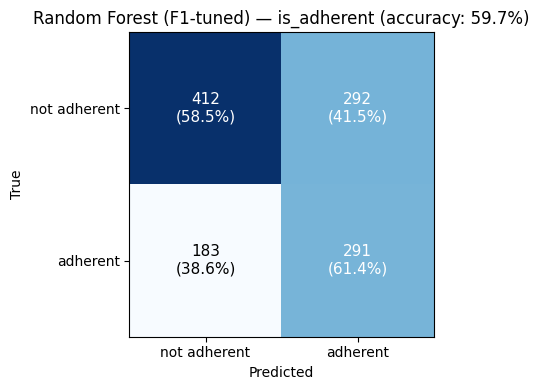

In [502]:
# HalvingGridSearchCV — starts with all candidates on a small n_samples subset,
# prunes losers each round, and escalates survivors to more data. Explores the
# full PARAM_GRID at roughly the same wall-clock as a small manual grid loop.

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
search = HalvingGridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    param_grid=PARAM_GRID,
    scoring="f1",
    cv=cv,
    factor=3,
    resource="n_samples",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

t0 = time.perf_counter()
search.fit(X_train, y_train)
print(f"\nDone in {(time.perf_counter() - t0) / 60:.1f} minutes")
print("Best params:", search.best_params_)
print(f"Best CV f1: {search.best_score_:.4f}")
print(f"Iterations run: {search.n_iterations_} | "
      f"n_candidates per iter: {search.n_candidates_} | "
      f"n_resources per iter: {search.n_resources_}")

best_rf = search.best_estimator_
y_pred = best_rf.predict(X_test)
print("\nClassification report (test set):")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix (test set):")
print(cm)

fig, ax = plt.subplots(figsize=(5, 4))
plot_cm_with_recall(cm, ax, "Random Forest (F1-tuned) — is_adherent")
plt.tight_layout()
plt.show()

# Legacy aliases so downstream cells that grew around the old manual-loop
# variable names keep working without an edit.
best_params = _tuned_local = {k: best_rf.get_params()[k] for k in PARAM_GRID if k in best_rf.get_params()}
best_score = float(search.best_score_)


n_iterations: 5
n_required_iterations: 6
n_possible_iterations: 5
min_resources_: 20
max_resources_: 4711
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 432
n_resources: 20
Fitting 5 folds for each of 432 candidates, totalling 2160 fits
----------
iter: 1
n_candidates: 144
n_resources: 60
Fitting 5 folds for each of 144 candidates, totalling 720 fits
----------
iter: 2
n_candidates: 48
n_resources: 180
Fitting 5 folds for each of 48 candidates, totalling 240 fits
----------
iter: 3
n_candidates: 16
n_resources: 540
Fitting 5 folds for each of 16 candidates, totalling 80 fits
----------
iter: 4
n_candidates: 6
n_resources: 1620
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Done in 23.1 minutes
Best params: {'class_weight': None, 'max_depth': 30, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 100}
Best CV roc_auc: 0.6318
Iterations run: 5 | n_candidates per iter: [432, 144, 48, 16, 6] | n_resources per iter:

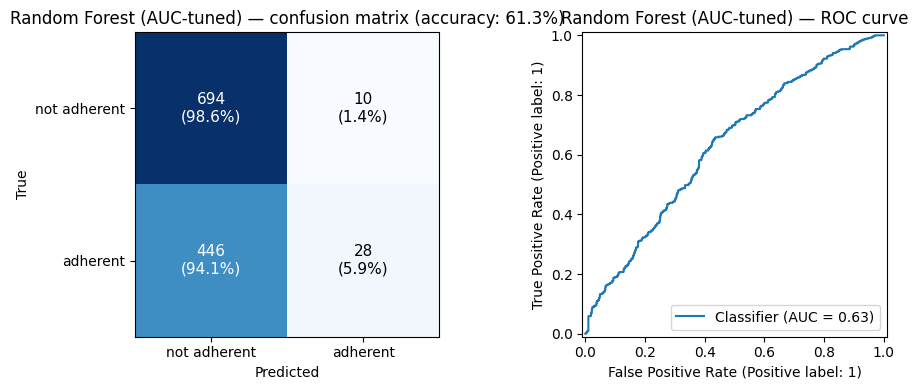

In [503]:
# HalvingGridSearchCV — starts with all candidates on a small n_samples subset,
# prunes losers each round, and escalates survivors to more data. Explores the
# full PARAM_GRID at roughly the same wall-clock as a small manual grid loop.

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
search = HalvingGridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    param_grid=PARAM_GRID,
    scoring="roc_auc",
    cv=cv,
    factor=3,
    resource="n_samples",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

t0 = time.perf_counter()
search.fit(X_train, y_train)
print(f"\nDone in {(time.perf_counter() - t0) / 60:.1f} minutes")
print("Best params:", search.best_params_)
print(f"Best CV roc_auc: {search.best_score_:.4f}")
print(f"Iterations run: {search.n_iterations_} | "
      f"n_candidates per iter: {search.n_candidates_} | "
      f"n_resources per iter: {search.n_resources_}")

best_rf_auc = search.best_estimator_
y_pred = best_rf_auc.predict(X_test)
y_proba = best_rf_auc.predict_proba(X_test)[:, 1]

print(f"\nTest ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification report (test set):")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix (test set):")
print(cm)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_cm_with_recall(cm, axes[0], "Random Forest (AUC-tuned) — confusion matrix")
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title("Random Forest (AUC-tuned) — ROC curve")
plt.tight_layout()
plt.show()

best_params_auc = {k: best_rf_auc.get_params()[k] for k in PARAM_GRID if k in best_rf_auc.get_params()}
best_score_auc = float(search.best_score_)


Gini importance — top 20 (AUC-tuned RF)


,gini_importance
AGE23X,0.082723
ICD_E78,0.071272
RX_ATORVASTATIN,0.050755
ICD_I10,0.049544
RX_LISINOPRIL,0.033151
PATIENT_COST_SHARE,0.031939
FAMINC23,0.028708
RX_FLUTICASONE,0.021641
ICD_J45,0.020746
RX_METOPROL SUC,0.018045


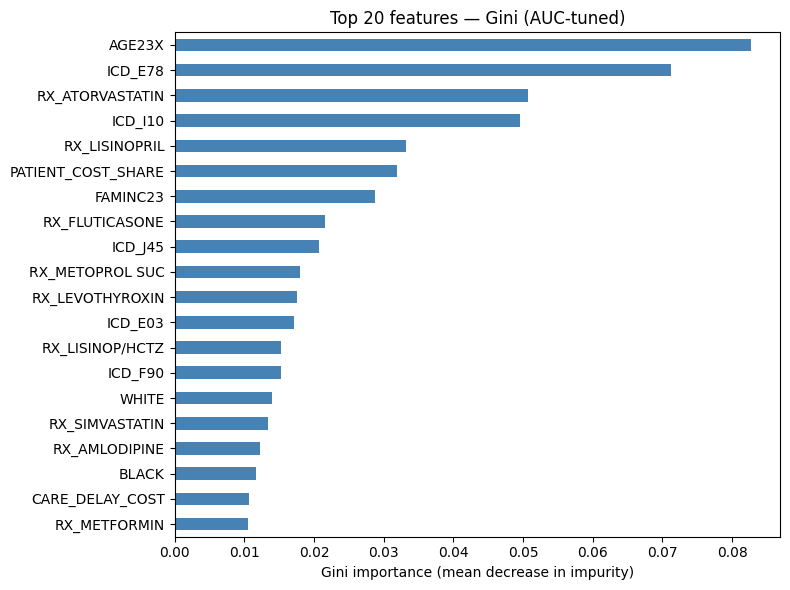

In [504]:
# Feature importance: Gini (RF impurity decrease) + SHAP
# Uses AUC-tuned model if available, else F1-tuned model.

model_for_imp = best_rf_auc if "best_rf_auc" in dir() else best_rf
model_label = "AUC-tuned" if "best_rf_auc" in dir() and model_for_imp is best_rf_auc else "F1-tuned"

TOP_N = 20  # edit: how many features to show

gini_imp = (
    pd.Series(model_for_imp.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
)

print(f"Gini importance — top {TOP_N} ({model_label} RF)")
display(gini_imp.head(TOP_N).to_frame("gini_importance"))

fig, ax = plt.subplots(figsize=(8, 6))
gini_imp.head(TOP_N).iloc[::-1].plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Gini importance (mean decrease in impurity)")
ax.set_title(f"Top {TOP_N} features — Gini ({model_label})")
plt.tight_layout()
plt.show()


SHAP mean |value| — top 20 (AUC-tuned RF, n=500)


,mean_abs_shap
ICD_E78,0.013768
ICD_I10,0.010302
AGE23X,0.009518
RX_ATORVASTATIN,0.008336
RX_LISINOPRIL,0.006548
ICD_J45,0.004801
WHITE,0.003920
RX_LEVOTHYROXIN,0.003736
ICD_E03,0.003228
RX_METOPROL SUC,0.003150


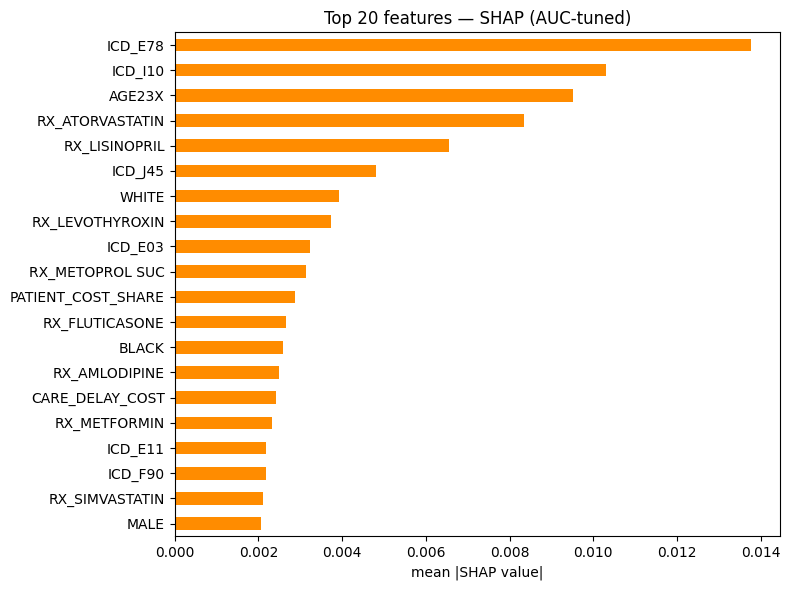

SHAP beeswarm (class = adherent):


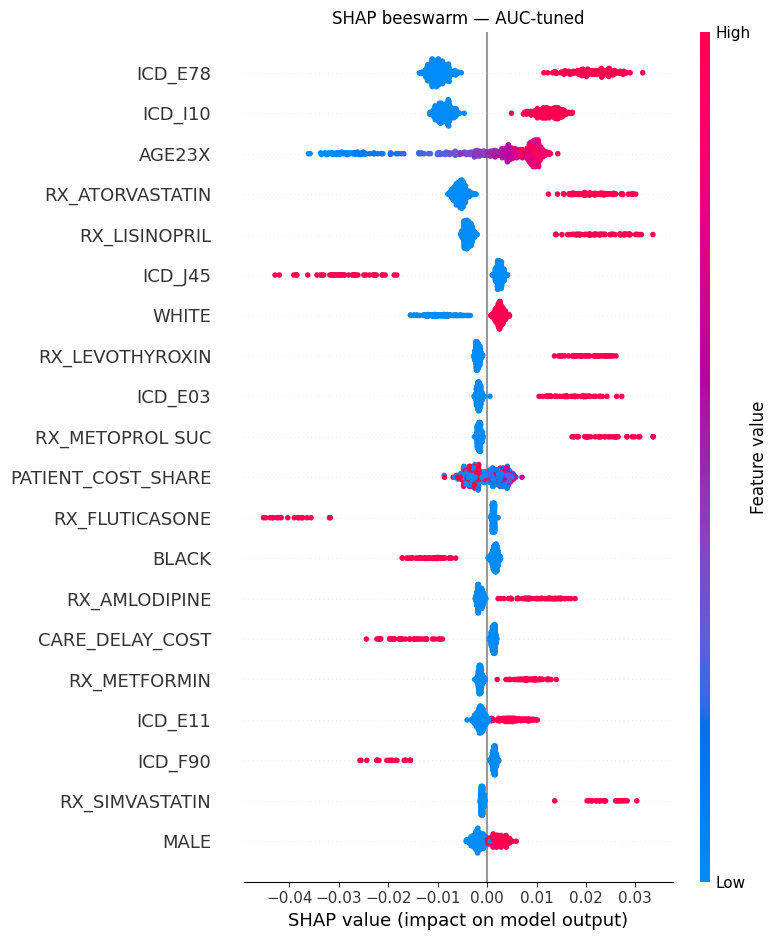

In [505]:
# SHAP values (TreeExplainer) — mean |SHAP| ranking + beeswarm
# Uses a sample of the training set for speed; raise SHAP_SAMPLE if you want more precision.

SHAP_SAMPLE = 500  # edit: number of rows for SHAP

X_shap = X_train.sample(n=min(SHAP_SAMPLE, len(X_train)), random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(model_for_imp)
shap_values = explainer.shap_values(X_shap)

# Binary RF: shap_values is often [class0, class1] or a 3D array depending on shap version
if isinstance(shap_values, list):
    shap_pos = shap_values[1]  # class 1 = adherent
elif getattr(shap_values, "ndim", 0) == 3:
    shap_pos = shap_values[:, :, 1]
else:
    shap_pos = shap_values

mean_abs_shap = (
    pd.Series(np.abs(shap_pos).mean(axis=0), index=X_shap.columns)
    .sort_values(ascending=False)
)

print(f"SHAP mean |value| — top {TOP_N} ({model_label} RF, n={len(X_shap)})")
display(mean_abs_shap.head(TOP_N).to_frame("mean_abs_shap"))

fig, ax = plt.subplots(figsize=(8, 6))
mean_abs_shap.head(TOP_N).iloc[::-1].plot(kind="barh", ax=ax, color="darkorange")
ax.set_xlabel("mean |SHAP value|")
ax.set_title(f"Top {TOP_N} features — SHAP ({model_label})")
plt.tight_layout()
plt.show()

print("SHAP beeswarm (class = adherent):")
shap.summary_plot(shap_pos, X_shap, max_display=TOP_N, show=False)
plt.title(f"SHAP beeswarm — {model_label}")
plt.tight_layout()
plt.show()


Gini importance — top 20 (F1-tuned RF)
Best F1 params: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'class_weight': 'balanced'}


,gini_importance
AGE23X,0.082393
ICD_E78,0.059394
ICD_I10,0.052297
RX_LISINOPRIL,0.045556
RX_ATORVASTATIN,0.032912
ICD_J45,0.029803
PATIENT_COST_SHARE,0.025809
FAMINC23,0.023621
CARE_DELAY_COST,0.022748
ICD_E03,0.020777


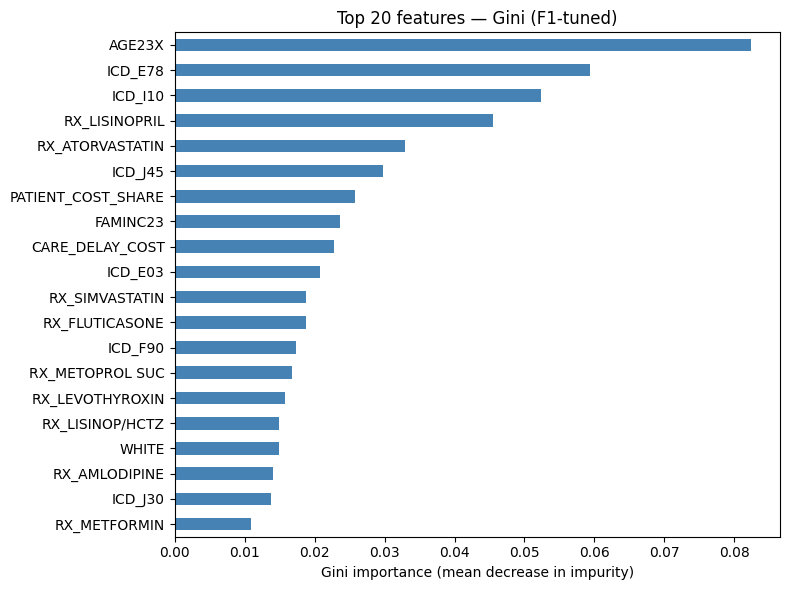

In [506]:
# F1-tuned RF — Gini feature importance
TOP_N_F1 = 20  # edit

gini_imp_f1 = (
    pd.Series(best_rf.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
)

# Read best params off the fitted estimator (rather than relying on a
# `best_params` variable from a manual grid loop — HalvingGridSearchCV
# fits the winner directly to best_rf).
_p = best_rf.get_params()
_tuned = {k: _p[k] for k in PARAM_GRID if k in _p}

print(f"Gini importance — top {TOP_N_F1} (F1-tuned RF)")
print("Best F1 params:", _tuned)
display(gini_imp_f1.head(TOP_N_F1).to_frame("gini_importance"))

fig, ax = plt.subplots(figsize=(8, 6))
gini_imp_f1.head(TOP_N_F1).iloc[::-1].plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Gini importance (mean decrease in impurity)")
ax.set_title(f"Top {TOP_N_F1} features — Gini (F1-tuned)")
plt.tight_layout()
plt.show()


SHAP mean |value| — top 20 (F1-tuned RF, n=500)


,mean_abs_shap
ICD_E78,0.008029
ICD_I10,0.007368
AGE23X,0.006945
RX_LISINOPRIL,0.005354
RX_ATORVASTATIN,0.003760
ICD_J45,0.003723
ICD_E03,0.002450
CARE_DELAY_COST,0.002445
WHITE,0.002147
BLACK,0.001955


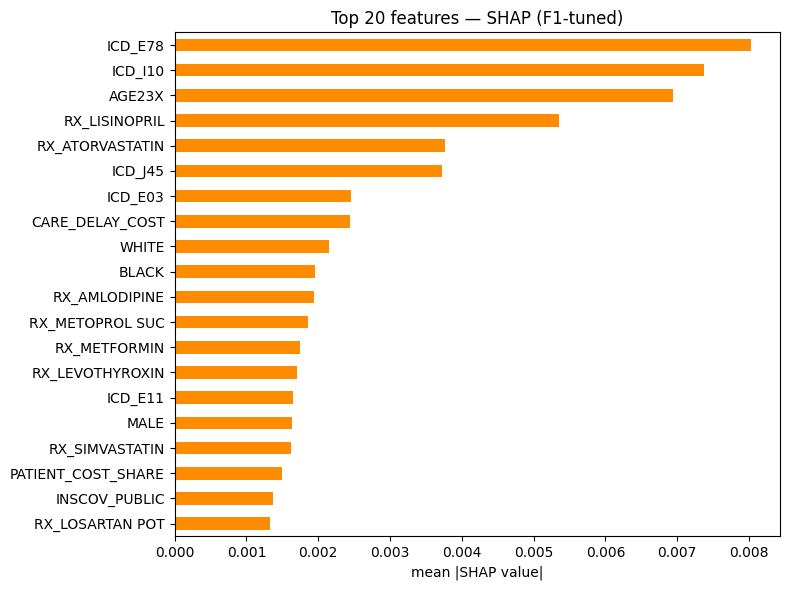

SHAP beeswarm (class = adherent, F1-tuned):


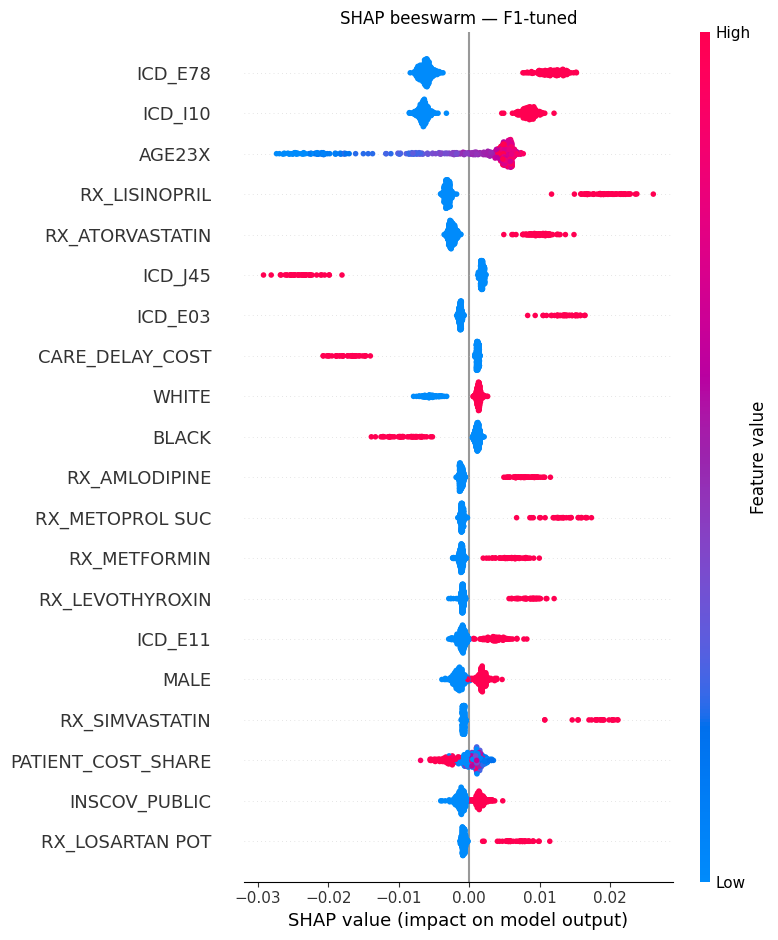

In [507]:
# F1-tuned RF — SHAP feature importance

SHAP_SAMPLE_F1 = 500  # edit

X_shap_f1 = X_train.sample(n=min(SHAP_SAMPLE_F1, len(X_train)), random_state=RANDOM_STATE)

explainer_f1 = shap.TreeExplainer(best_rf)
shap_values_f1 = explainer_f1.shap_values(X_shap_f1)

if isinstance(shap_values_f1, list):
    shap_pos_f1 = shap_values_f1[1]
elif getattr(shap_values_f1, "ndim", 0) == 3:
    shap_pos_f1 = shap_values_f1[:, :, 1]
else:
    shap_pos_f1 = shap_values_f1

mean_abs_shap_f1 = (
    pd.Series(np.abs(shap_pos_f1).mean(axis=0), index=X_shap_f1.columns)
    .sort_values(ascending=False)
)

print(f"SHAP mean |value| — top {TOP_N_F1} (F1-tuned RF, n={len(X_shap_f1)})")
display(mean_abs_shap_f1.head(TOP_N_F1).to_frame("mean_abs_shap"))

fig, ax = plt.subplots(figsize=(8, 6))
mean_abs_shap_f1.head(TOP_N_F1).iloc[::-1].plot(kind="barh", ax=ax, color="darkorange")
ax.set_xlabel("mean |SHAP value|")
ax.set_title(f"Top {TOP_N_F1} features — SHAP (F1-tuned)")
plt.tight_layout()
plt.show()

print("SHAP beeswarm (class = adherent, F1-tuned):")
shap.summary_plot(shap_pos_f1, X_shap_f1, max_display=TOP_N_F1, show=False)
plt.title("SHAP beeswarm — F1-tuned")
plt.tight_layout()
plt.show()


In [508]:
# RF with n_drugs + n_conditions included as features
# (still drops meps_adherence_ratio to avoid leakage)

# Ensure count columns exist on patient-level model_df
rx_cols = [c for c in model_df.columns if c.startswith("RX_")]
icd_cols = [c for c in model_df.columns if c.startswith("ICD_")]
model_df["n_drugs"] = model_df[rx_cols].sum(axis=1)
model_df["n_conditions"] = model_df[icd_cols].sum(axis=1)

# Restored full grid (halving handles it — see PARAM_GRID above).
PARAM_GRID_NC = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"],
}

CV_FOLDS = 5
TEST_SIZE = 0.2
RANDOM_STATE = 42

drop_cols_nc = [
    "DUPERSID",
    "is_adherent",
    "meps_adherence_ratio",  # leakage — still dropped
    # n_drugs / n_conditions KEPT as features
]

X_nc = model_df.drop(columns=[c for c in drop_cols_nc if c in model_df.columns])
y_nc = model_df["is_adherent"]

X_train_nc, X_test_nc, y_train_nc, y_test_nc = train_test_split(
    X_nc, y_nc, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_nc
)

print("Features include n_drugs / n_conditions:", 
      "n_drugs" in X_nc.columns and "n_conditions" in X_nc.columns)
print(f"X_nc shape: {X_nc.shape} | train: {X_train_nc.shape[0]} | test: {X_test_nc.shape[0]}")
print(f"GridSearch combos: {np.prod([len(v) for v in PARAM_GRID_NC.values()])} x {CV_FOLDS} folds")


Features include n_drugs / n_conditions: True
X_nc shape: (5889, 502) | train: 4711 | test: 1178
GridSearch combos: 432 x 5 folds


n_iterations: 5
n_required_iterations: 6
n_possible_iterations: 5
min_resources_: 20
max_resources_: 4711
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 432
n_resources: 20
Fitting 5 folds for each of 432 candidates, totalling 2160 fits
----------
iter: 1
n_candidates: 144
n_resources: 60
Fitting 5 folds for each of 144 candidates, totalling 720 fits
----------
iter: 2
n_candidates: 48
n_resources: 180
Fitting 5 folds for each of 48 candidates, totalling 240 fits
----------
iter: 3
n_candidates: 16
n_resources: 540
Fitting 5 folds for each of 16 candidates, totalling 80 fits
----------
iter: 4
n_candidates: 6
n_resources: 1620
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Done in 35.9 minutes
Best params: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best CV f1: 0.5211
Iterations run: 5 | n_candidates per iter: [432, 144, 48, 16, 6] | n_resources per it

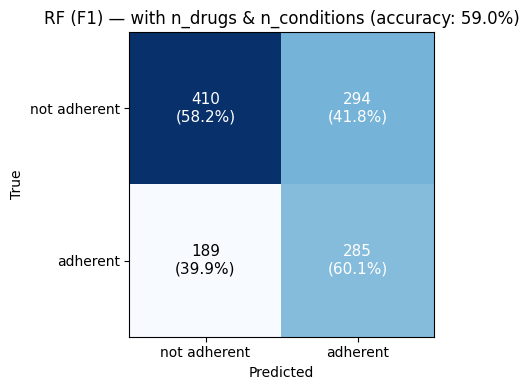

In [509]:
# HalvingGridSearchCV — starts with all candidates on a small n_samples subset,
# prunes losers each round, and escalates survivors to more data. Explores the
# full PARAM_GRID_NC at roughly the same wall-clock as a small manual grid loop.

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
search = HalvingGridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    param_grid=PARAM_GRID_NC,
    scoring="f1",
    cv=cv,
    factor=3,
    resource="n_samples",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

t0 = time.perf_counter()
search.fit(X_train_nc, y_train_nc)
print(f"\nDone in {(time.perf_counter() - t0) / 60:.1f} minutes")
print("Best params:", search.best_params_)
print(f"Best CV f1: {search.best_score_:.4f}")
print(f"Iterations run: {search.n_iterations_} | "
      f"n_candidates per iter: {search.n_candidates_} | "
      f"n_resources per iter: {search.n_resources_}")

best_rf_nc = search.best_estimator_
y_pred = best_rf_nc.predict(X_test_nc)
print("\nClassification report (test set):")
print(classification_report(y_test_nc, y_pred, digits=3))

cm = confusion_matrix(y_test_nc, y_pred)
print("Confusion matrix (test set):")
print(cm)

fig, ax = plt.subplots(figsize=(5, 4))
plot_cm_with_recall(cm, ax, "RF (F1) — with n_drugs & n_conditions")
plt.tight_layout()
plt.show()

best_params_nc = {k: best_rf_nc.get_params()[k] for k in PARAM_GRID_NC if k in best_rf_nc.get_params()}
best_score_nc = float(search.best_score_)


n_iterations: 5
n_required_iterations: 6
n_possible_iterations: 5
min_resources_: 20
max_resources_: 4711
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 432
n_resources: 20
Fitting 5 folds for each of 432 candidates, totalling 2160 fits
----------
iter: 1
n_candidates: 144
n_resources: 60
Fitting 5 folds for each of 144 candidates, totalling 720 fits
----------
iter: 2
n_candidates: 48
n_resources: 180
Fitting 5 folds for each of 48 candidates, totalling 240 fits
----------
iter: 3
n_candidates: 16
n_resources: 540
Fitting 5 folds for each of 16 candidates, totalling 80 fits
----------
iter: 4
n_candidates: 6
n_resources: 1620
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Done in 18.3 minutes
Best params: {'class_weight': None, 'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 200}
Best CV roc_auc: 0.6410
Iterations run: 5 | n_candidates per iter: [432, 144, 48, 16, 6] | n_resources per iter:

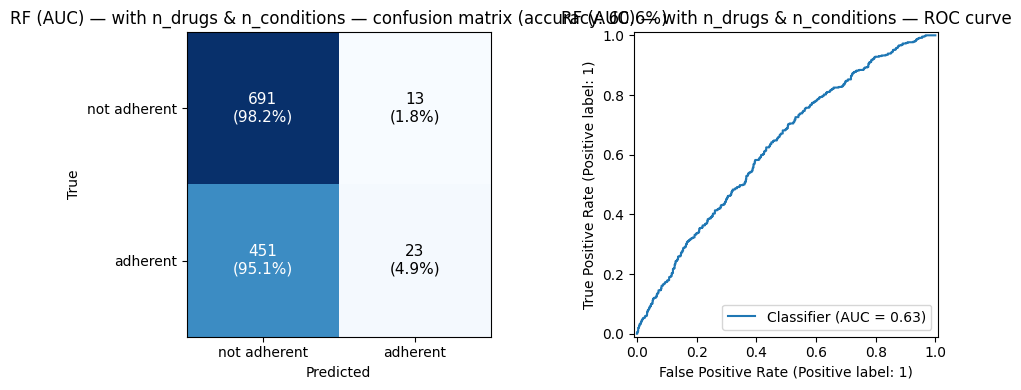

In [510]:
# HalvingGridSearchCV — starts with all candidates on a small n_samples subset,
# prunes losers each round, and escalates survivors to more data. Explores the
# full PARAM_GRID_NC at roughly the same wall-clock as a small manual grid loop.

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
search = HalvingGridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    param_grid=PARAM_GRID_NC,
    scoring="roc_auc",
    cv=cv,
    factor=3,
    resource="n_samples",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

t0 = time.perf_counter()
search.fit(X_train_nc, y_train_nc)
print(f"\nDone in {(time.perf_counter() - t0) / 60:.1f} minutes")
print("Best params:", search.best_params_)
print(f"Best CV roc_auc: {search.best_score_:.4f}")
print(f"Iterations run: {search.n_iterations_} | "
      f"n_candidates per iter: {search.n_candidates_} | "
      f"n_resources per iter: {search.n_resources_}")

best_rf_nc_auc = search.best_estimator_
y_pred = best_rf_nc_auc.predict(X_test_nc)
y_proba = best_rf_nc_auc.predict_proba(X_test_nc)[:, 1]

print(f"\nTest ROC-AUC: {roc_auc_score(y_test_nc, y_proba):.4f}")
print("\nClassification report (test set):")
print(classification_report(y_test_nc, y_pred, digits=3))

cm = confusion_matrix(y_test_nc, y_pred)
print("Confusion matrix (test set):")
print(cm)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_cm_with_recall(cm, axes[0], "RF (AUC) — with n_drugs & n_conditions — confusion matrix")
RocCurveDisplay.from_predictions(y_test_nc, y_proba, ax=axes[1])
axes[1].set_title("RF (AUC) — with n_drugs & n_conditions — ROC curve")
plt.tight_layout()
plt.show()

best_params_nc_auc = {k: best_rf_nc_auc.get_params()[k] for k in PARAM_GRID_NC if k in best_rf_nc_auc.get_params()}
best_score_nc_auc = float(search.best_score_)


In [511]:
# New modeling frame WITHOUT RXNAME / RX_ one-hot columns
# Keeps demographics, ICD dummies, n_drugs/n_conditions (if present), adherence target, etc.

rx_cols = [c for c in model_df.columns if c.startswith("RX_")]
#icd_cols = [c for c in model_df.columns if c.startswith("ICD_")]

# Ensure count columns exist before dropping drug dummies
if "n_drugs" not in model_df.columns and rx_cols:
    model_df["n_drugs"] = model_df[rx_cols].sum(axis=1)
#if "n_conditions" not in model_df.columns and icd_cols:
#    model_df["n_conditions"] = model_df[icd_cols].sum(axis=1)

drop_rx = rx_cols + [c for c in ["RXNAME"] if c in model_df.columns]
model_df_no_rx = model_df.drop(columns=drop_rx).copy()

print(f"original model_df shape: {model_df.shape}")
print(f"model_df_no_rx shape:    {model_df_no_rx.shape}")
print(f"dropped {len(drop_rx)} RXNAME/RX_ columns")
print(f"remaining columns ({len(model_df_no_rx.columns)}):")
print(model_df_no_rx.columns.tolist())
model_df_no_rx.head()


original model_df shape: (5889, 505)
model_df_no_rx shape:    (5889, 99)
dropped 406 RXNAME/RX_ columns
remaining columns (99):
['DUPERSID', 'AGE23X', 'FAMINC23', 'is_adherent', 'INSCOV_PRIVATE', 'INSCOV_PUBLIC', 'INSCOV_UNINSURED', 'MALE', 'FEMALE', 'WHITE', 'BLACK', 'AMER_INDIAN', 'ASIAN_INDIAN', 'CHINESE', 'FILIPINO', 'PMED_DELAY_COST', 'NO_PMED_DELAY_COST', 'CARE_DELAY_COST', 'NO_CARE_DELAY_COST', 'POV_POOR', 'POV_NEAR_POOR', 'POV_LOW', 'POV_MIDDLE', 'POV_HIGH', 'ICD_C18', 'ICD_C34', 'ICD_C44', 'ICD_C50', 'ICD_C61', 'ICD_C67', 'ICD_C73', 'ICD_C95', 'ICD_E03', 'ICD_E05', 'ICD_E11', 'ICD_E28', 'ICD_E29', 'ICD_E34', 'ICD_E78', 'ICD_F03', 'ICD_F19', 'ICD_F20', 'ICD_F31', 'ICD_F32', 'ICD_F39', 'ICD_F41', 'ICD_F84', 'ICD_F90', 'ICD_F99', 'ICD_G20', 'ICD_G25', 'ICD_G40', 'ICD_G47', 'ICD_G62', 'ICD_H35', 'ICD_H40', 'ICD_H54', 'ICD_I10', 'ICD_I20', 'ICD_I25', 'ICD_I48', 'ICD_I49', 'ICD_I50', 'ICD_I51', 'ICD_J30', 'ICD_J32', 'ICD_J42', 'ICD_J43', 'ICD_J44', 'ICD_J45', 'ICD_K21', 'ICD_K50', '

,DUPERSID,AGE23X,FAMINC23,is_adherent,INSCOV_PRIVATE,INSCOV_PUBLIC,INSCOV_UNINSURED,MALE,FEMALE,WHITE,BLACK,AMER_INDIAN,ASIAN_INDIAN,CHINESE,FILIPINO,PMED_DELAY_COST,NO_PMED_DELAY_COST,CARE_DELAY_COST,NO_CARE_DELAY_COST,POV_POOR,POV_NEAR_POOR,POV_LOW,POV_MIDDLE,POV_HIGH,ICD_C18,ICD_C34,ICD_C44,ICD_C50,ICD_C61,ICD_C67,ICD_C73,ICD_C95,ICD_E03,ICD_E05,ICD_E11,ICD_E28,ICD_E29,ICD_E34,ICD_E78,ICD_F03,ICD_F19,ICD_F20,ICD_F31,ICD_F32,ICD_F39,ICD_F41,ICD_F84,ICD_F90,ICD_F99,ICD_G20,ICD_G25,ICD_G40,ICD_G47,ICD_G62,ICD_H35,ICD_H40,ICD_H54,ICD_I10,ICD_I20,ICD_I25,ICD_I48,ICD_I49,ICD_I50,ICD_I51,ICD_J30,ICD_J32,ICD_J42,ICD_J43,ICD_J44,ICD_J45,ICD_K21,ICD_K50,ICD_K57,ICD_K58,ICD_K59,ICD_K76,ICD_M06,ICD_M10,ICD_M17,ICD_M19,ICD_M35,ICD_M48,ICD_M50,ICD_M51,ICD_M53,ICD_M54,ICD_M81,ICD_M85,ICD_N18,ICD_N19,ICD_N40,ICD_R26,ICD_R32,ICD_U09,ICD_Z79,meps_adherence_ratio,PATIENT_COST_SHARE,n_drugs,n_conditions
0,2790002101,58,130700,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,41.095890,0.672668,1,1
1,2790011101,71,79240,1,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,61.643836,0.739957,2,2
2,2790011102,71,79240,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,28.767123,0.236679,2,2
3,2790012101,55,192950,1,1,0,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,60.273973,0.033005,2,1
4,2790012102,54,192950,1,1,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,65.753425,0.000000,1,1


In [512]:
# XGBoost: predict is_adherent using model_df_no_rx (no RXNAME / RX_ dummies)
# Edit XGB_PARAM_GRID below to change the search.
# If import fails on macOS with libomp.dylib missing, run: brew install libomp

# Restored full grid. HalvingGridSearchCV prunes losers early so a wide
# search costs about the same as a small one. Kept all axes because
# Koster & Sigrist (2024) show every XGBoost hyperparameter can affect
# accuracy on tabular data.
XGB_PARAM_GRID = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 5],
    "reg_lambda": [1.0, 5.0],
}

CV_FOLDS = 5
TEST_SIZE = 0.2
RANDOM_STATE = 42

# Ensure model_df_no_rx exists
if "model_df_no_rx" not in dir():
    rx_cols = [c for c in model_df.columns if c.startswith("RX_")]
    icd_cols = [c for c in model_df.columns if c.startswith("ICD_")]
    if "n_drugs" not in model_df.columns and rx_cols:
        model_df["n_drugs"] = model_df[rx_cols].sum(axis=1)
    if "n_conditions" not in model_df.columns and icd_cols:
        model_df["n_conditions"] = model_df[icd_cols].sum(axis=1)
    drop_rx = rx_cols + [c for c in ["RXNAME"] if c in model_df.columns]
    model_df_no_rx = model_df.drop(columns=drop_rx).copy()

drop_cols_xgb = [
    "DUPERSID",
    "is_adherent",
    "meps_adherence_ratio",  # leakage
]

X_xgb = model_df_no_rx.drop(columns=[c for c in drop_cols_xgb if c in model_df_no_rx.columns])
y_xgb = model_df_no_rx["is_adherent"]

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb, y_xgb, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_xgb
)

# class imbalance helper for XGBoost
neg, pos = np.bincount(y_train_xgb.astype(int))
scale_pos_weight = neg / pos if pos > 0 else 1.0

print(f"X_xgb shape: {X_xgb.shape} | train: {X_train_xgb.shape[0]} | test: {X_test_xgb.shape[0]}")
print(f"class balance (train):\n{y_train_xgb.value_counts(normalize=True).round(3)}")
print(f"scale_pos_weight: {scale_pos_weight:.3f}")
print(f"Grid combos: {np.prod([len(v) for v in XGB_PARAM_GRID.values()])} x {CV_FOLDS} folds")
print(f"features ({X_xgb.shape[1]}): {X_xgb.columns.tolist()[:20]}...")


X_xgb shape: (5889, 96) | train: 4711 | test: 1178
class balance (train):
is_adherent
0    0.598
1    0.402
Name: proportion, dtype: float64
scale_pos_weight: 1.486
Grid combos: 576 x 5 folds
features (96): ['AGE23X', 'FAMINC23', 'INSCOV_PRIVATE', 'INSCOV_PUBLIC', 'INSCOV_UNINSURED', 'MALE', 'FEMALE', 'WHITE', 'BLACK', 'AMER_INDIAN', 'ASIAN_INDIAN', 'CHINESE', 'FILIPINO', 'PMED_DELAY_COST', 'NO_PMED_DELAY_COST', 'CARE_DELAY_COST', 'NO_CARE_DELAY_COST', 'POV_POOR', 'POV_NEAR_POOR', 'POV_LOW']...


n_iterations: 5
n_required_iterations: 6
n_possible_iterations: 5
min_resources_: 20
max_resources_: 4711
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 576
n_resources: 20
Fitting 5 folds for each of 576 candidates, totalling 2880 fits
----------
iter: 1
n_candidates: 192
n_resources: 60
Fitting 5 folds for each of 192 candidates, totalling 960 fits
----------
iter: 2
n_candidates: 64
n_resources: 180
Fitting 5 folds for each of 64 candidates, totalling 320 fits
----------
iter: 3
n_candidates: 22
n_resources: 540
Fitting 5 folds for each of 22 candidates, totalling 110 fits
----------
iter: 4
n_candidates: 8
n_resources: 1620
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Done in 0.7 minutes
Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'reg_lambda': 1.0, 'subsample': 1.0}
Best CV f1: 0.5378
Iterations run: 5 | n_candidates per iter: [576, 192, 64, 22, 8] | n_resources 

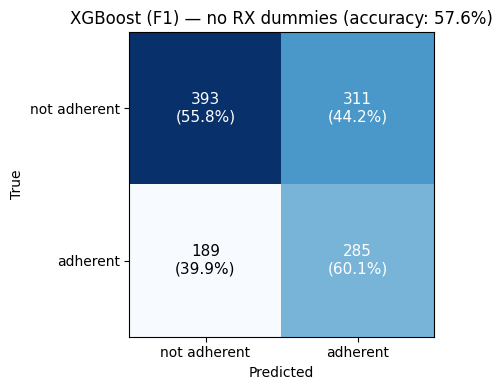

In [513]:
# HalvingGridSearchCV — starts with all candidates on a small n_samples subset,
# prunes losers each round, and escalates survivors to more data. Explores the
# full XGB_PARAM_GRID at roughly the same wall-clock as a small manual grid loop.

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
search = HalvingGridSearchCV(
    estimator=XGBClassifier(objective="binary:logistic", eval_metric="auc" if "roc" in "f1" else "logloss", random_state=RANDOM_STATE, n_jobs=1, tree_method="hist", scale_pos_weight=scale_pos_weight, verbosity=0),
    param_grid=XGB_PARAM_GRID,
    scoring="f1",
    cv=cv,
    factor=3,
    resource="n_samples",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

t0 = time.perf_counter()
search.fit(X_train_xgb, y_train_xgb)
print(f"\nDone in {(time.perf_counter() - t0) / 60:.1f} minutes")
print("Best params:", search.best_params_)
print(f"Best CV f1: {search.best_score_:.4f}")
print(f"Iterations run: {search.n_iterations_} | "
      f"n_candidates per iter: {search.n_candidates_} | "
      f"n_resources per iter: {search.n_resources_}")

best_xgb = search.best_estimator_
y_pred = best_xgb.predict(X_test_xgb)
print("\nClassification report (test set):")
print(classification_report(y_test_xgb, y_pred, digits=3))

cm = confusion_matrix(y_test_xgb, y_pred)
print("Confusion matrix (test set):")
print(cm)

fig, ax = plt.subplots(figsize=(5, 4))
plot_cm_with_recall(cm, ax, "XGBoost (F1) — no RX dummies")
plt.tight_layout()
plt.show()

best_params_xgb = {k: best_xgb.get_params()[k] for k in XGB_PARAM_GRID if k in best_xgb.get_params()}
best_score_xgb = float(search.best_score_)


n_iterations: 5
n_required_iterations: 6
n_possible_iterations: 5
min_resources_: 20
max_resources_: 4711
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 576
n_resources: 20
Fitting 5 folds for each of 576 candidates, totalling 2880 fits
----------
iter: 1
n_candidates: 192
n_resources: 60
Fitting 5 folds for each of 192 candidates, totalling 960 fits
----------
iter: 2
n_candidates: 64
n_resources: 180
Fitting 5 folds for each of 64 candidates, totalling 320 fits
----------
iter: 3
n_candidates: 22
n_resources: 540
Fitting 5 folds for each of 22 candidates, totalling 110 fits
----------
iter: 4
n_candidates: 8
n_resources: 1620
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Done in 0.8 minutes
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 200, 'reg_lambda': 5.0, 'subsample': 0.8}
Best CV roc_auc: 0.6328
Iterations run: 5 | n_candidates per iter: [576, 192, 64, 22, 8] | n_resou

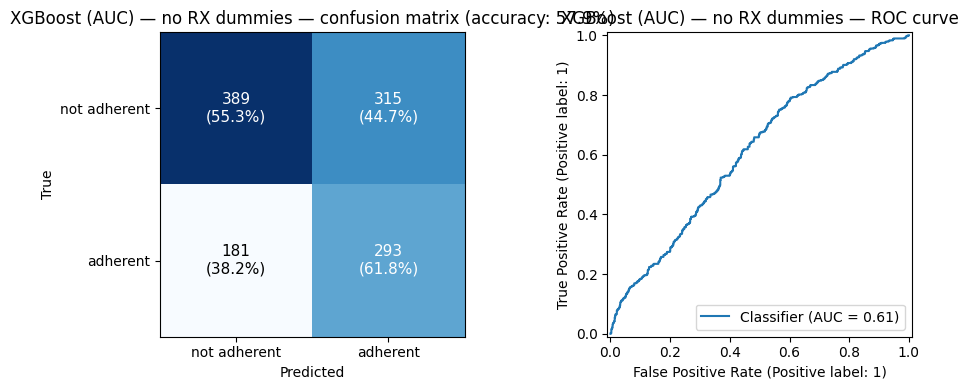

In [514]:
# HalvingGridSearchCV — starts with all candidates on a small n_samples subset,
# prunes losers each round, and escalates survivors to more data. Explores the
# full XGB_PARAM_GRID at roughly the same wall-clock as a small manual grid loop.

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
search = HalvingGridSearchCV(
    estimator=XGBClassifier(objective="binary:logistic", eval_metric="auc" if "roc" in "roc_auc" else "logloss", random_state=RANDOM_STATE, n_jobs=1, tree_method="hist", scale_pos_weight=scale_pos_weight, verbosity=0),
    param_grid=XGB_PARAM_GRID,
    scoring="roc_auc",
    cv=cv,
    factor=3,
    resource="n_samples",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

t0 = time.perf_counter()
search.fit(X_train_xgb, y_train_xgb)
print(f"\nDone in {(time.perf_counter() - t0) / 60:.1f} minutes")
print("Best params:", search.best_params_)
print(f"Best CV roc_auc: {search.best_score_:.4f}")
print(f"Iterations run: {search.n_iterations_} | "
      f"n_candidates per iter: {search.n_candidates_} | "
      f"n_resources per iter: {search.n_resources_}")

best_xgb_auc = search.best_estimator_
y_pred = best_xgb_auc.predict(X_test_xgb)
y_proba = best_xgb_auc.predict_proba(X_test_xgb)[:, 1]

print(f"\nTest ROC-AUC: {roc_auc_score(y_test_xgb, y_proba):.4f}")
print("\nClassification report (test set):")
print(classification_report(y_test_xgb, y_pred, digits=3))

cm = confusion_matrix(y_test_xgb, y_pred)
print("Confusion matrix (test set):")
print(cm)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_cm_with_recall(cm, axes[0], "XGBoost (AUC) — no RX dummies — confusion matrix")
RocCurveDisplay.from_predictions(y_test_xgb, y_proba, ax=axes[1])
axes[1].set_title("XGBoost (AUC) — no RX dummies — ROC curve")
plt.tight_layout()
plt.show()

best_params_xgb_auc = {k: best_xgb_auc.get_params()[k] for k in XGB_PARAM_GRID if k in best_xgb_auc.get_params()}
best_score_xgb_auc = float(search.best_score_)


Gain importance — top 20 (AUC-tuned XGBoost)
Best params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5, 'reg_lambda': 5.0}


,gain_importance
ICD_E78,0.151748
ICD_I10,0.066020
AGE23X,0.051830
n_drugs,0.037660
ICD_E03,0.036224
n_conditions,0.035226
INSCOV_UNINSURED,0.033788
ICD_J30,0.031187
BLACK,0.030851
ICD_E11,0.030638


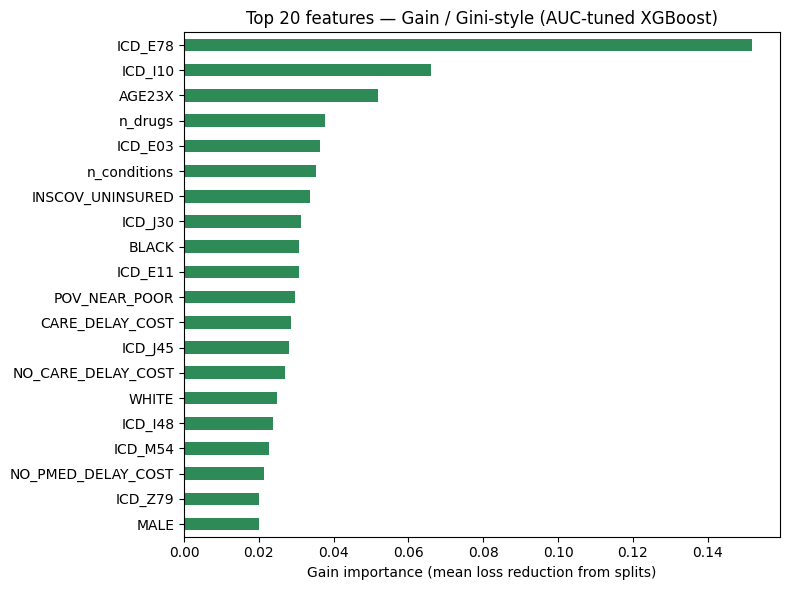

In [515]:
# XGBoost feature importance — Gain (Gini-style) + SHAP
# XGBoost — Gain feature importance (Gini-style impurity decrease analogue)
# Requires best_xgb / best_xgb_auc and X_train_xgb from the XGBoost cells above.

model_xgb_imp = best_xgb_auc if "best_xgb_auc" in dir() else best_xgb
model_xgb_label = (
    "AUC-tuned"
    if "best_xgb_auc" in dir() and model_xgb_imp is best_xgb_auc
    else "F1-tuned"
)

TOP_N_XGB = 20  # edit: how many features to show

# sklearn XGBClassifier.feature_importances_ == gain by default
gain_imp_xgb = (
    pd.Series(model_xgb_imp.feature_importances_, index=X_train_xgb.columns)
    .sort_values(ascending=False)
)

# Best params come off the fitted estimator (HalvingGridSearchCV refits the
# winner directly, so best_xgb / best_xgb_auc carry the tuned values).
_p_xgb = model_xgb_imp.get_params()
_tuned_xgb = {k: _p_xgb[k] for k in XGB_PARAM_GRID if k in _p_xgb}

print(f"Gain importance — top {TOP_N_XGB} ({model_xgb_label} XGBoost)")
print("Best params:", _tuned_xgb)
display(gain_imp_xgb.head(TOP_N_XGB).to_frame("gain_importance"))

fig, ax = plt.subplots(figsize=(8, 6))
gain_imp_xgb.head(TOP_N_XGB).iloc[::-1].plot(kind="barh", ax=ax, color="seagreen")
ax.set_xlabel("Gain importance (mean loss reduction from splits)")
ax.set_title(f"Top {TOP_N_XGB} features — Gain / Gini-style ({model_xgb_label} XGBoost)")
plt.tight_layout()
plt.show()


SHAP mean |value| — top 20 (AUC-tuned XGBoost, n=500)


,mean_abs_shap
ICD_E78,0.174483
AGE23X,0.100713
ICD_I10,0.098182
n_drugs,0.052517
ICD_E03,0.027489
BLACK,0.022981
ICD_J45,0.011667
MALE,0.011660
CARE_DELAY_COST,0.011323
FAMINC23,0.011099


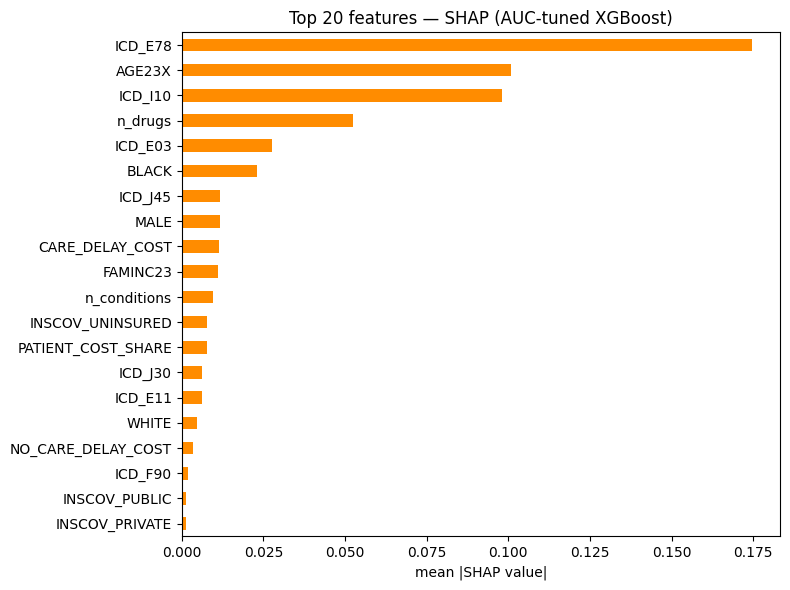

SHAP beeswarm (class = adherent):


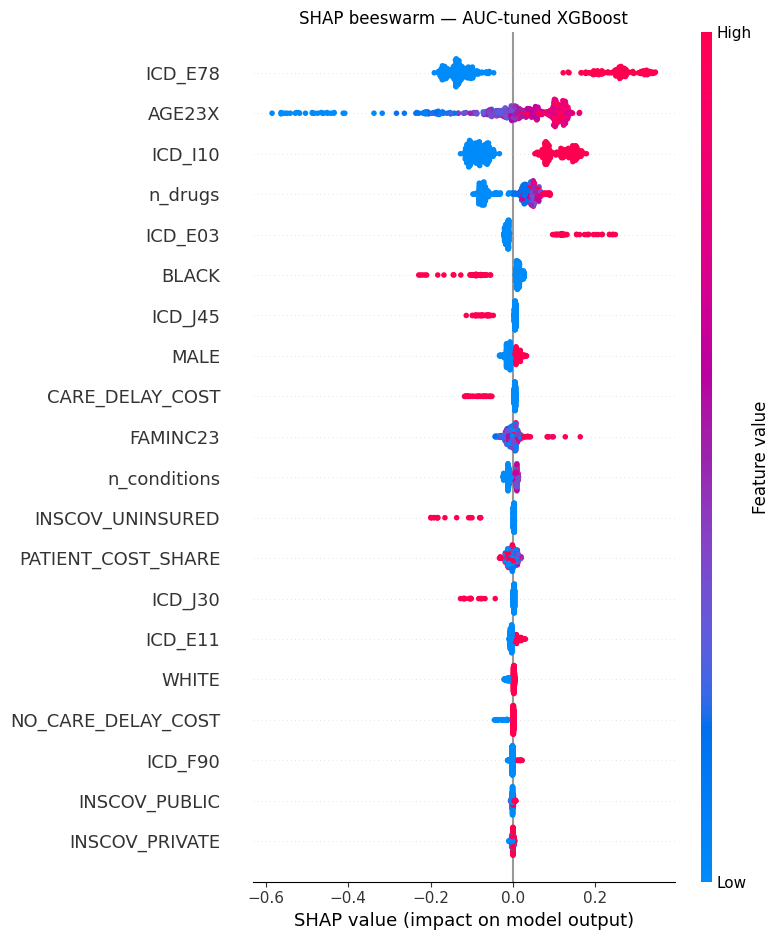

In [516]:
# XGBoost — SHAP (TreeExplainer): mean |SHAP| ranking + beeswarm
# Uses a sample of the training set for speed; raise SHAP_SAMPLE_XGB for more precision.

SHAP_SAMPLE_XGB = 500  # edit

X_shap_xgb = X_train_xgb.sample(
    n=min(SHAP_SAMPLE_XGB, len(X_train_xgb)), random_state=RANDOM_STATE
)

explainer_xgb = shap.TreeExplainer(model_xgb_imp)
shap_values_xgb = explainer_xgb.shap_values(X_shap_xgb)

# Binary XGB: usually a 2D array for the positive class (adherent)
if isinstance(shap_values_xgb, list):
    shap_pos_xgb = shap_values_xgb[1]
elif getattr(shap_values_xgb, "ndim", 0) == 3:
    shap_pos_xgb = shap_values_xgb[:, :, 1]
else:
    shap_pos_xgb = shap_values_xgb

mean_abs_shap_xgb = (
    pd.Series(np.abs(shap_pos_xgb).mean(axis=0), index=X_shap_xgb.columns)
    .sort_values(ascending=False)
)

print(
    f"SHAP mean |value| — top {TOP_N_XGB} "
    f"({model_xgb_label} XGBoost, n={len(X_shap_xgb)})"
)
display(mean_abs_shap_xgb.head(TOP_N_XGB).to_frame("mean_abs_shap"))

fig, ax = plt.subplots(figsize=(8, 6))
mean_abs_shap_xgb.head(TOP_N_XGB).iloc[::-1].plot(kind="barh", ax=ax, color="darkorange")
ax.set_xlabel("mean |SHAP value|")
ax.set_title(f"Top {TOP_N_XGB} features — SHAP ({model_xgb_label} XGBoost)")
plt.tight_layout()
plt.show()

print("SHAP beeswarm (class = adherent):")
shap.summary_plot(shap_pos_xgb, X_shap_xgb, max_display=TOP_N_XGB, show=False)
plt.title(f"SHAP beeswarm — {model_xgb_label} XGBoost")
plt.tight_layout()
plt.show()


In [517]:
# XGBoost with TC1S1 one-hots (`model_df_no_rx_tc`)
# Build model_df_no_rx_tc: model_df_no_rx + one-hot TC1S1 (patient level)
# TC1S1 comes from pair-level new_grouped_merge_df; a patient gets 1 if any of their drugs has that subclass.

if "model_df_no_rx" not in dir():
    raise NameError("Run the model_df_no_rx cell first.")
if "new_grouped_merge_df" not in dir() or "TC1S1" not in new_grouped_merge_df.columns:
    raise NameError("Need new_grouped_merge_df with TC1S1 (from earlier merge cells).")

tc = new_grouped_merge_df[["DUPERSID", "TC1S1"]].copy()
tc["TC1S1"] = pd.to_numeric(tc["TC1S1"], errors="coerce")
# Drop MEPS missing/inapplicable sentinels (negatives) and NaNs
tc = tc[tc["TC1S1"].notna() & (tc["TC1S1"] > 0)].copy()
tc["TC1S1"] = tc["TC1S1"].astype(int)

tc_dummies = pd.get_dummies(tc["TC1S1"].astype(str), prefix="TC1S1").astype(int)
tc_patient = (
    pd.concat([tc[["DUPERSID"]], tc_dummies], axis=1)
    .groupby("DUPERSID", as_index=False)
    .max()
)

model_df_no_rx_tc = model_df_no_rx.merge(tc_patient, on="DUPERSID", how="left")
tc_cols = [c for c in model_df_no_rx_tc.columns if c.startswith("TC1S1_")]
model_df_no_rx_tc[tc_cols] = model_df_no_rx_tc[tc_cols].fillna(0).astype(int)

print(f"model_df_no_rx shape:    {model_df_no_rx.shape}")
print(f"model_df_no_rx_tc shape: {model_df_no_rx_tc.shape}")
print(f"TC1S1 one-hot columns:   {len(tc_cols)}")
print(f"patients with ≥1 TC1S1:  {(model_df_no_rx_tc[tc_cols].sum(axis=1) > 0).sum():,}")
print("TC1S1_* prevalence (top 15):")
display(
    model_df_no_rx_tc[tc_cols]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .to_frame("n_patients")
)
model_df_no_rx_tc.head()


model_df_no_rx shape:    (5889, 99)
model_df_no_rx_tc shape: (5889, 159)
TC1S1 one-hot columns:   60
patients with ≥1 TC1S1:  5,857
TC1S1_* prevalence (top 15):


,n_patients
TC1S1_19,2078
TC1S1_249,1388
TC1S1_99,1272
TC1S1_47,823
TC1S1_42,814
TC1S1_56,739
TC1S1_48,719
TC1S1_103,579
TC1S1_49,559
TC1S1_64,482


,DUPERSID,AGE23X,FAMINC23,is_adherent,INSCOV_PRIVATE,INSCOV_PUBLIC,INSCOV_UNINSURED,MALE,FEMALE,WHITE,BLACK,AMER_INDIAN,ASIAN_INDIAN,CHINESE,FILIPINO,PMED_DELAY_COST,NO_PMED_DELAY_COST,CARE_DELAY_COST,NO_CARE_DELAY_COST,POV_POOR,POV_NEAR_POOR,POV_LOW,POV_MIDDLE,POV_HIGH,ICD_C18,ICD_C34,ICD_C44,ICD_C50,ICD_C61,ICD_C67,ICD_C73,ICD_C95,ICD_E03,ICD_E05,ICD_E11,ICD_E28,ICD_E29,ICD_E34,ICD_E78,ICD_F03,ICD_F19,ICD_F20,ICD_F31,ICD_F32,ICD_F39,ICD_F41,ICD_F84,ICD_F90,ICD_F99,ICD_G20,ICD_G25,ICD_G40,ICD_G47,ICD_G62,ICD_H35,ICD_H40,ICD_H54,ICD_I10,ICD_I20,ICD_I25,ICD_I48,ICD_I49,ICD_I50,ICD_I51,ICD_J30,ICD_J32,ICD_J42,ICD_J43,ICD_J44,ICD_J45,ICD_K21,ICD_K50,ICD_K57,ICD_K58,ICD_K59,ICD_K76,ICD_M06,ICD_M10,ICD_M17,ICD_M19,ICD_M35,ICD_M48,ICD_M50,ICD_M51,ICD_M53,ICD_M54,ICD_M81,ICD_M85,ICD_N18,ICD_N19,ICD_N40,ICD_R26,ICD_R32,ICD_U09,ICD_Z79,meps_adherence_ratio,PATIENT_COST_SHARE,n_drugs,n_conditions,TC1S1_101,TC1S1_103,TC1S1_117,TC1S1_119,TC1S1_125,TC1S1_130,TC1S1_147,TC1S1_19,TC1S1_192,TC1S1_194,TC1S1_23,TC1S1_24,TC1S1_243,TC1S1_247,TC1S1_249,TC1S1_25,TC1S1_251,TC1S1_264,TC1S1_277,TC1S1_288,TC1S1_312,TC1S1_313,TC1S1_320,TC1S1_355,TC1S1_403,TC1S1_409,TC1S1_42,TC1S1_422,TC1S1_43,TC1S1_44,TC1S1_45,TC1S1_46,TC1S1_460,TC1S1_47,TC1S1_48,TC1S1_482,TC1S1_49,TC1S1_5,TC1S1_504,TC1S1_51,TC1S1_516,TC1S1_519,TC1S1_53,TC1S1_55,TC1S1_56,TC1S1_58,TC1S1_64,TC1S1_66,TC1S1_67,TC1S1_7,TC1S1_71,TC1S1_73,TC1S1_80,TC1S1_82,TC1S1_83,TC1S1_88,TC1S1_91,TC1S1_95,TC1S1_98,TC1S1_99
0,2790002101,58,130700,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,41.095890,0.672668,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,2790011101,71,79240,1,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,61.643836,0.739957,2,2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2790011102,71,79240,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,28.767123,0.236679,2,2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2790012101,55,192950,1,1,0,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,60.273973,0.033005,2,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2790012102,54,192950,1,1,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,65.753425,0.000000,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [518]:
# XGBoost setup on model_df_no_rx_tc (no RX dummies + TC1S1 one-hots)

# Reuse grid from earlier XGB cells if present; otherwise define here
if "XGB_PARAM_GRID" not in dir():
# Restored full grid (halving handles it).
    XGB_PARAM_GRID = {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 5, 7, 10],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0],
        "min_child_weight": [1, 5],
        "reg_lambda": [1.0, 5.0],
    }
if "CV_FOLDS" not in dir():
    CV_FOLDS = 5
if "TEST_SIZE" not in dir():
    TEST_SIZE = 0.2
if "RANDOM_STATE" not in dir():
    RANDOM_STATE = 42

drop_cols_xgb_tc = [
    "DUPERSID",
    "is_adherent",
    "meps_adherence_ratio",  # leakage
]

X_xgb_tc = model_df_no_rx_tc.drop(
    columns=[c for c in drop_cols_xgb_tc if c in model_df_no_rx_tc.columns]
)
y_xgb_tc = model_df_no_rx_tc["is_adherent"]

X_train_xgb_tc, X_test_xgb_tc, y_train_xgb_tc, y_test_xgb_tc = train_test_split(
    X_xgb_tc, y_xgb_tc, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_xgb_tc
)

neg_tc, pos_tc = np.bincount(y_train_xgb_tc.astype(int))
scale_pos_weight_tc = neg_tc / pos_tc if pos_tc > 0 else 1.0

print(
    f"X_xgb_tc shape: {X_xgb_tc.shape} | "
    f"train: {X_train_xgb_tc.shape[0]} | test: {X_test_xgb_tc.shape[0]}"
)
print(f"class balance (train):\n{y_train_xgb_tc.value_counts(normalize=True).round(3)}")
print(f"scale_pos_weight: {scale_pos_weight_tc:.3f}")
print(
    f"Grid combos: {np.prod([len(v) for v in XGB_PARAM_GRID.values()])} x {CV_FOLDS} folds"
)
tc_feat = [c for c in X_xgb_tc.columns if c.startswith("TC1S1_")]
print(f"features: {X_xgb_tc.shape[1]} total | {len(tc_feat)} TC1S1_*")
print(f"feature sample: {X_xgb_tc.columns.tolist()[:15]}...")


X_xgb_tc shape: (5889, 156) | train: 4711 | test: 1178
class balance (train):
is_adherent
0    0.598
1    0.402
Name: proportion, dtype: float64
scale_pos_weight: 1.486
Grid combos: 576 x 5 folds
features: 156 total | 60 TC1S1_*
feature sample: ['AGE23X', 'FAMINC23', 'INSCOV_PRIVATE', 'INSCOV_PUBLIC', 'INSCOV_UNINSURED', 'MALE', 'FEMALE', 'WHITE', 'BLACK', 'AMER_INDIAN', 'ASIAN_INDIAN', 'CHINESE', 'FILIPINO', 'PMED_DELAY_COST', 'NO_PMED_DELAY_COST']...


n_iterations: 5
n_required_iterations: 6
n_possible_iterations: 5
min_resources_: 20
max_resources_: 4711
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 576
n_resources: 20
Fitting 5 folds for each of 576 candidates, totalling 2880 fits
----------
iter: 1
n_candidates: 192
n_resources: 60
Fitting 5 folds for each of 192 candidates, totalling 960 fits
----------
iter: 2
n_candidates: 64
n_resources: 180
Fitting 5 folds for each of 64 candidates, totalling 320 fits
----------
iter: 3
n_candidates: 22
n_resources: 540
Fitting 5 folds for each of 22 candidates, totalling 110 fits
----------
iter: 4
n_candidates: 8
n_resources: 1620
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Done in 1.6 minutes
Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 300, 'reg_lambda': 1.0, 'subsample': 0.8}
Best CV f1: 0.5262
Iterations run: 5 | n_candidates per iter: [576, 192, 64, 22, 8] | n_resources 

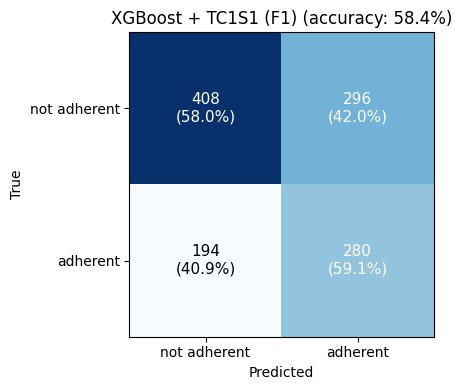

In [519]:
# HalvingGridSearchCV — starts with all candidates on a small n_samples subset,
# prunes losers each round, and escalates survivors to more data. Explores the
# full XGB_PARAM_GRID at roughly the same wall-clock as a small manual grid loop.

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
search = HalvingGridSearchCV(
    estimator=XGBClassifier(objective="binary:logistic", eval_metric="auc" if "roc" in "f1" else "logloss", random_state=RANDOM_STATE, n_jobs=1, tree_method="hist", scale_pos_weight=scale_pos_weight_tc, verbosity=0),
    param_grid=XGB_PARAM_GRID,
    scoring="f1",
    cv=cv,
    factor=3,
    resource="n_samples",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

t0 = time.perf_counter()
search.fit(X_train_xgb_tc, y_train_xgb_tc)
print(f"\nDone in {(time.perf_counter() - t0) / 60:.1f} minutes")
print("Best params:", search.best_params_)
print(f"Best CV f1: {search.best_score_:.4f}")
print(f"Iterations run: {search.n_iterations_} | "
      f"n_candidates per iter: {search.n_candidates_} | "
      f"n_resources per iter: {search.n_resources_}")

best_xgb_tc = search.best_estimator_
y_pred = best_xgb_tc.predict(X_test_xgb_tc)
print("\nClassification report (test set):")
print(classification_report(y_test_xgb_tc, y_pred, digits=3))

cm = confusion_matrix(y_test_xgb_tc, y_pred)
print("Confusion matrix (test set):")
print(cm)

fig, ax = plt.subplots(figsize=(5, 4))
plot_cm_with_recall(cm, ax, "XGBoost + TC1S1 (F1)")
plt.tight_layout()
plt.show()

best_params_xgb_tc = {k: best_xgb_tc.get_params()[k] for k in XGB_PARAM_GRID if k in best_xgb_tc.get_params()}
best_score_xgb_tc = float(search.best_score_)


In [520]:
# MARRYXX / REGIONXX (year-end + backfill) + EDUCYR → merge onto model_df
# MARRY: 1 married … 10 separated-in-round; negatives -1/-7/-8
# REGION: 1 NE, 2 MW, 3 S, 4 W; -1 inapplicable
# EDUCYR: 0–17 years; negatives -1/-7/-8

def _backfill_newest_to_oldest(df, cols_newest_to_oldest, out_name):
    """First non-negative value walking newest → oldest rounds."""
    series = [pd.to_numeric(df[c], errors="coerce") for c in cols_newest_to_oldest]
    out = series[0].copy()
    for s in series[1:]:
        need = out.isna() | (out < 0)
        out = out.where(~need, s)
    df[out_name] = out
    return df


demo_extra = demo_df[
    [
        "DUPERSID",
        "EDUCYR",
        "MARRY23X",
        "MARRY53X",
        "MARRY42X",
        "MARRY31X",
        "REGION23",
        "REGION53",
        "REGION42",
        "REGION31",
    ]
].drop_duplicates("DUPERSID").copy()

demo_extra = _backfill_newest_to_oldest(
    demo_extra,
    ["MARRY23X", "MARRY53X", "MARRY42X", "MARRY31X"],
    "MARRYXX",
)
demo_extra = _backfill_newest_to_oldest(
    demo_extra,
    ["REGION23", "REGION53", "REGION42", "REGION31"],
    "REGIONXX",
)
demo_extra["EDUCYR"] = pd.to_numeric(demo_extra["EDUCYR"], errors="coerce")

keep = demo_extra[["DUPERSID", "MARRYXX", "REGIONXX", "EDUCYR"]].copy()

# Attach to model_df (patient-level)
model_df = model_df.drop(columns=["MARRYXX", "REGIONXX", "EDUCYR"], errors="ignore").merge(
    keep, on="DUPERSID", how="left"
)

# Keep downstream frames in sync if they already exist
for _name in ("model_df_no_rx", "model_df_no_rx_tc"):
    if _name in dir():
        globals()[_name] = (
            globals()[_name]
            .drop(columns=["MARRYXX", "REGIONXX", "EDUCYR"], errors="ignore")
            .merge(keep, on="DUPERSID", how="left")
        )

print(f"model_df rows: {len(model_df):,} | patients: {model_df['DUPERSID'].nunique():,}")
for col in ("MARRYXX", "REGIONXX", "EDUCYR"):
    s = pd.to_numeric(model_df[col], errors="coerce")
    n_neg = int((s < 0).sum())
    n_na = int(s.isna().sum())
    print(f"{col}: negatives={n_neg:,} | NaN={n_na:,}")
    if n_neg:
        print(s[s < 0].value_counts().sort_index().to_string())

print("\nValue counts (non-negative):")
display(model_df["MARRYXX"].value_counts(dropna=False).sort_index().to_frame("n"))
display(model_df["REGIONXX"].value_counts(dropna=False).sort_index().to_frame("n"))
print("EDUCYR describe (non-negative only):")
print(model_df.loc[model_df["EDUCYR"] >= 0, "EDUCYR"].describe().round(2))
model_df[["DUPERSID", "MARRYXX", "REGIONXX", "EDUCYR"]].head()


model_df rows: 5,889 | patients: 5,889
MARRYXX: negatives=1 | NaN=0
MARRYXX
-7    1
REGIONXX: negatives=0 | NaN=0
EDUCYR: negatives=58 | NaN=0
EDUCYR
-8    33
-7     6
-1    19

Value counts (non-negative):


,n
MARRYXX,
-7,1
1,2949
2,728
3,905
4,141
5,949
6,216


,n
REGIONXX,
1,796
2,1396
3,2240
4,1457


EDUCYR describe (non-negative only):
count    5831.00
mean       13.16
std         3.38
min         0.00
25%        12.00
50%        13.00
75%        16.00
max        17.00
Name: EDUCYR, dtype: float64


,DUPERSID,MARRYXX,REGIONXX,EDUCYR
0,2790002101,3,2,17
1,2790011101,1,4,17
2,2790011102,1,4,15
3,2790012101,5,2,17
4,2790012102,2,2,14


In [521]:
# medication_freq = pills/day ≈ RXQUANTY / RXDAYSUP
# medication_dose = strength per unit ≈ RXSTRENG (+ medication_dose_unit from RXSTRUNT)
# medication_qty_unit = RXFORM (TABS/CAPS/…) — unit that RXQUANTY is counted in
# Example: 90 TABS / 45 days = 2 per day; dose 10 MG

MAX_PILLS_PER_DAY = 10  # edit: freqs above this → missing (not clipped)

_rx_cols = [
    "DUPERSID", "DRUGIDX", "RXNAME",
    "RXSTRENG", "RXSTRUNT", "RXQUANTY", "RXFORM", "RXDAYSUP",
]
if "df_248" in dir() and set(_rx_cols).issubset(df_248.columns):
    _rx = df_248[_rx_cols].copy()
else:
    _rx = pd.read_excel(MEPS_DIR / "h248a.xlsx", usecols=_rx_cols, engine="calamine")

_dose = pd.to_numeric(_rx["RXSTRENG"], errors="coerce")
_qty = pd.to_numeric(_rx["RXQUANTY"], errors="coerce")
_days = pd.to_numeric(_rx["RXDAYSUP"], errors="coerce")

_dose = _dose.where(_dose >= 0)
_qty_ok = _qty.where(_qty > 0)
_days_ok = _days.where((_days > 0) & (_days < 990))

_freq = _qty_ok / _days_ok
n_before = int(_freq.notna().sum())
n_implausible = int((_freq > MAX_PILLS_PER_DAY).sum())
_freq = _freq.where((_freq > 0) & (_freq <= MAX_PILLS_PER_DAY))

# Units: treat MEPS -15 / blanks as missing
def _clean_unit(s):
    out = s.astype(str).str.strip()
    bad = out.str.lower().isin({"-15", "nan", "none", "", "<na>"})
    return out.where(~bad)

_rx["medication_dose"] = _dose
_rx["medication_dose_unit"] = _clean_unit(_rx["RXSTRUNT"])
_rx["medication_freq"] = _freq
_rx["medication_qty_unit"] = _clean_unit(_rx["RXFORM"])

print(
    f"Fill-level freq: {n_before:,} calculable → "
    f"{n_implausible:,} dropped as >{MAX_PILLS_PER_DAY}/day → "
    f"{int(_freq.notna().sum()):,} kept"
)
print("Top dose units:", _rx["medication_dose_unit"].value_counts().head(8).to_dict())
print("Top qty units:", _rx["medication_qty_unit"].value_counts().head(8).to_dict())


def _first_non_null(s):
    s = s.dropna()
    return s.iloc[0] if len(s) else pd.NA


med_by_drug = (
    _rx.groupby(["DUPERSID", "RXNAME"], as_index=False)
    .agg(
        medication_freq=("medication_freq", "mean"),
        medication_dose=("medication_dose", "mean"),
        medication_dose_unit=("medication_dose_unit", _first_non_null),
        medication_qty_unit=("medication_qty_unit", _first_non_null),
    )
)

med_by_person = (
    med_by_drug.groupby("DUPERSID", as_index=False)
    .agg(
        medication_freq=("medication_freq", "mean"),
        medication_dose=("medication_dose", "mean"),
        medication_dose_unit=("medication_dose_unit", _first_non_null),
        medication_qty_unit=("medication_qty_unit", _first_non_null),
    )
)

_med_cols = [
    "medication_freq",
    "medication_dose",
    "medication_dose_unit",
    "medication_qty_unit",
]
model_df = model_df.drop(columns=_med_cols, errors="ignore")

if "RXNAME" in model_df.columns:
    model_df = model_df.merge(med_by_drug, on=["DUPERSID", "RXNAME"], how="left")
    level = "pair (DUPERSID × RXNAME)"
else:
    model_df = model_df.merge(med_by_person, on="DUPERSID", how="left")
    level = "patient (mean across drugs)"

if "new_grouped_merge_df" in dir() and "RXNAME" in new_grouped_merge_df.columns:
    new_grouped_merge_df = new_grouped_merge_df.drop(columns=_med_cols, errors="ignore").merge(
        med_by_drug, on=["DUPERSID", "RXNAME"], how="left"
    )

for _name in ("model_df_no_rx", "model_df_no_rx_tc"):
    if _name in dir():
        globals()[_name] = (
            globals()[_name]
            .drop(columns=_med_cols, errors="ignore")
            .merge(med_by_person, on="DUPERSID", how="left")
        )

print(f"Merged at {level} → model_df shape {model_df.shape}")
for c in _med_cols:
    print(f"  {c}: non-null {model_df[c].notna().sum():,} / {len(model_df):,}")

print("\nmedication_freq describe:")
print(model_df["medication_freq"].describe(percentiles=[0.5, 0.9, 0.99]).round(3))
display(
    model_df[
        [
            c
            for c in [
                "DUPERSID",
                "RXNAME",
                "medication_freq",
                "medication_qty_unit",
                "medication_dose",
                "medication_dose_unit",
            ]
            if c in model_df.columns
        ]
    ].head(10)
)


Fill-level freq: 137,134 calculable → 1,395 dropped as >10/day → 135,739 kept
Top dose units: {'MG': 129586, 'MCG': 6478, '%': 5850, 'MCG/ACT': 5293, 'MG/ML': 4501, 'UNIT/ML': 2979, 'MEQ': 1100, 'UNIT': 889}
Top qty units: {'TABS': 106711, 'CAPS': 13959, 'TB24': 7355, 'SOPN': 4784, 'SOLN': 4591, 'TAB': 3965, 'AERS': 3792, 'TBEC': 3621}
Merged at patient (mean across drugs) → model_df shape (5889, 512)
  medication_freq: non-null 5,881 / 5,889
  medication_dose: non-null 5,772 / 5,889
  medication_dose_unit: non-null 5,789 / 5,889
  medication_qty_unit: non-null 5,852 / 5,889

medication_freq describe:
count    5881.000
mean        1.406
std         0.611
min         0.027
50%         1.286
90%         2.085
99%         3.511
max        10.000
Name: medication_freq, dtype: float64


,DUPERSID,medication_freq,medication_qty_unit,medication_dose,medication_dose_unit
0,2790002101,1.464286,MISC,172.083333,MG
1,2790011101,1.000000,TABS,22.500000,MG
2,2790011102,1.666667,CAPS,186.666667,MG
3,2790012101,1.163393,AEPB,23.175000,MCG/ACT
4,2790012102,1.000000,TABS,200.000000,MCG
5,2790012103,1.500000,TABS,150.000000,MG
6,2790012105,NaN,ENEM,4.000000,GM
7,2790019101,1.000000,TABS,189.285714,MG
8,2790023101,1.000000,TABS,10.000000,MG
9,2790032101,1.000000,TABS,10.000000,MG


In [522]:
# --- Paper-driven enrichments: ethnicity + dosing-frequency bins ---
# Adds two columns the scoping review + paper 3 flagged as strong predictors
# but that the notebook was not yet using:
#   RACETHX             : MEPS combined race/ethnicity code (1=Hispanic,
#                         2=NH White, 3=NH Black, 4=NH Asian, 5=NH other).
#   medication_freq_bin : bucketed pills-per-day. Paper 3 (Toy et al., COPD)
#                         found PDC drops 43% -> 23% as dosing frequency rises.
# These join model_df, model_df_no_rx, and model_df_no_rx_tc so all three
# downstream model frames pick them up.

# --- 1. RACETHX ---
if "RACETHX" in demo_df.columns:
    _eth = demo_df[["DUPERSID", "RACETHX"]].drop_duplicates("DUPERSID")
    model_df = model_df.drop(columns=["RACETHX"], errors="ignore").merge(
        _eth, on="DUPERSID", how="left"
    )
    for _name in ("model_df_no_rx", "model_df_no_rx_tc"):
        if _name in dir():
            globals()[_name] = (
                globals()[_name]
                .drop(columns=["RACETHX"], errors="ignore")
                .merge(_eth, on="DUPERSID", how="left")
            )
    print(f"RACETHX non-null: {model_df['RACETHX'].notna().sum():,} / {len(model_df):,}")
    print(model_df["RACETHX"].value_counts(dropna=False).sort_index().to_string())
else:
    print("WARN: RACETHX not in demo_df — pull it from h251 first.")


# --- 2. medication_freq_bin ---
def _freq_bin(f):
    if pd.isna(f): return pd.NA
    if f <= 1.25: return "1x_daily"
    if f <= 2.25: return "2x_daily"
    if f <= 3.25: return "3x_daily"
    return "4x_plus"

for _name in ("model_df", "model_df_no_rx", "model_df_no_rx_tc"):
    if _name in dir():
        _df = globals()[_name]
        if "medication_freq" in _df.columns:
            _df["medication_freq_bin"] = _df["medication_freq"].apply(_freq_bin)
            globals()[_name] = _df

print("\nmedication_freq_bin distribution (model_df):")
print(model_df["medication_freq_bin"].value_counts(dropna=False).to_string())


RACETHX non-null: 5,889 / 5,889
RACETHX
1     810
2    3969
3     713
4     228
5     169

medication_freq_bin distribution (model_df):
medication_freq_bin
1x_daily    2832
2x_daily    2620
3x_daily     342
4x_plus       87
NaN            8


/var/folders/f5/dy840xrs0dq70k185zls6qmc0000gn/T/ipykernel_2357/1874274447.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  _df["medication_freq_bin"] = _df["medication_freq"].apply(_freq_bin)


Model 1 (baseline (RXNAME kept)): 506 features, 5,889 rows
n_iterations: 5
n_required_iterations: 6
n_possible_iterations: 5
min_resources_: 20
max_resources_: 4711
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 576
n_resources: 20
Fitting 5 folds for each of 576 candidates, totalling 2880 fits
----------
iter: 1
n_candidates: 192
n_resources: 60
Fitting 5 folds for each of 192 candidates, totalling 960 fits
----------
iter: 2
n_candidates: 64
n_resources: 180
Fitting 5 folds for each of 64 candidates, totalling 320 fits
----------
iter: 3
n_candidates: 22
n_resources: 540
Fitting 5 folds for each of 22 candidates, totalling 110 fits
----------
iter: 4
n_candidates: 8
n_resources: 1620
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Halving done in 4.0 min | iterations=5
Best CV AUC: 0.6319
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'reg_lambda': 1.0, 'subsample': 0.8}



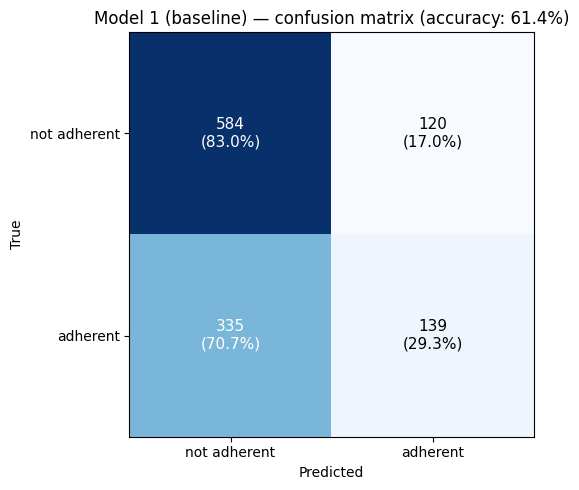

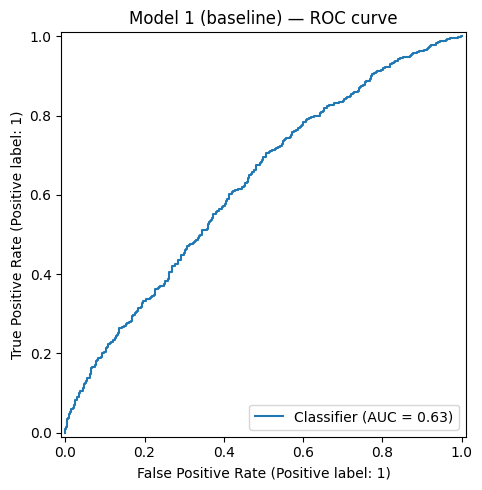


Top 15 by gain:


,gain
ICD_E78,0.048004
ICD_I10,0.021589
RX_FLUTICASONE,0.016201
WHITE,0.015474
RX_LISINOPRIL,0.015279
RX_LEVOTHYROXIN,0.015174
AGE23X,0.014788
RX_FLUOXETINE,0.013240
ICD_E03,0.013193
INSCOV_UNINSURED,0.012825


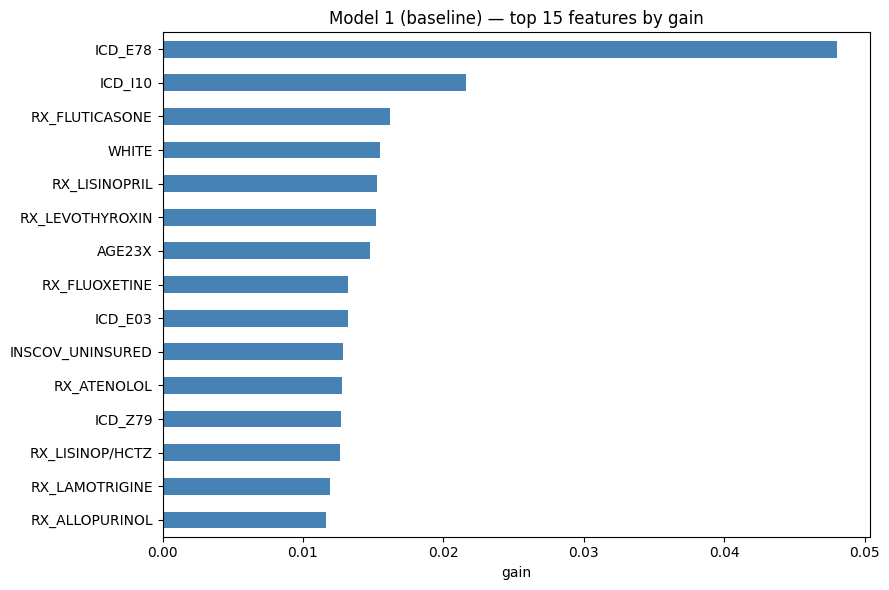


Top 15 by mean |SHAP| (n=500):


,mean_abs_shap
ICD_E78,0.184722
AGE23X,0.121480
ICD_I10,0.090084
RX_LISINOPRIL,0.060786
REGIONXX,0.049712
RX_FLUTICASONE,0.045199
medication_dose,0.041516
RACETHX,0.038191
RX_METFORMIN,0.037310
EDUCYR,0.037169


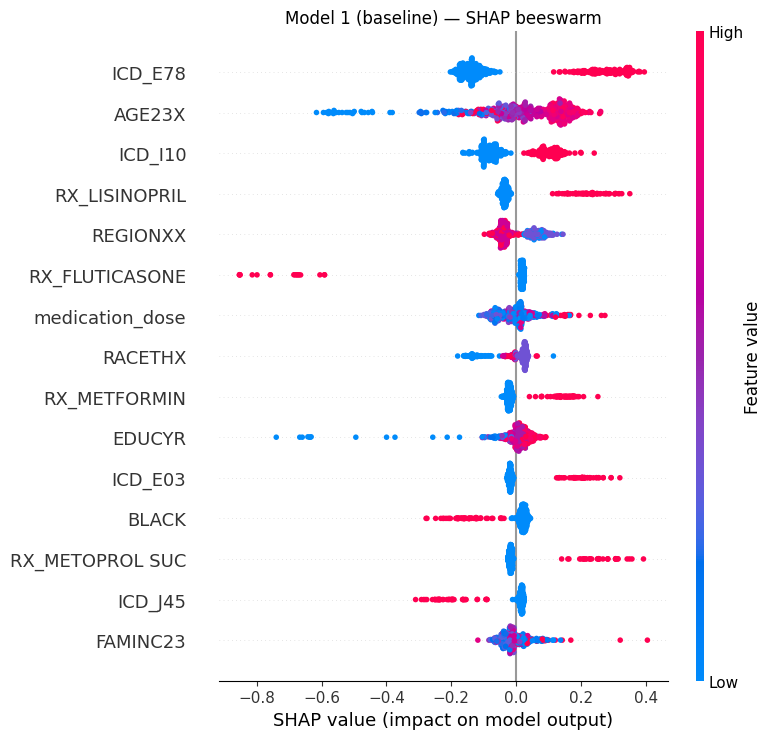

In [523]:
# ============================================================================
# Model 1 — baseline (RXNAME kept)
# ============================================================================
# Same feature set as the RF baseline in cells 91-92: demographics, insurance, cost, ICD dummies, and RXNAME dummies (RX_*). Answers: how far does XGBoost get on the same inputs RF used? n_drugs and n_conditions are DROPPED here to match RF baseline; Model 2 adds them back.
#
# Self-contained: builds its own X/y, runs HalvingGridSearchCV on the full
# XGB_PARAM_GRID from cell 101, prints holdout metrics, then Gini (gain) and
# SHAP for interpretability. Uses the shared plot_cm_with_recall helper from
# cell 89 for the confusion matrix (recall % per row + accuracy in title).
# All plots use separate figures so they do NOT overlap.

RANDOM_STATE_M1 = 42
TEST_SIZE_M1   = 0.2
CV_FOLDS_M1    = 5
TOP_N_M1       = 15
SHAP_SAMPLE_M1 = 500

# --- build feature matrix ---
_LEAK_M1 = ["DUPERSID", "is_adherent", "meps_adherence_ratio",
              "total_valid_days", "total_days_supply", "drug_start_days"]

def _build_m1(df):
    y = df["is_adherent"].astype(int)
    X = df.drop(columns=[c for c in _LEAK_M1 if c in df.columns], errors="ignore").copy()
    X = X.drop(columns=["n_drugs", "n_conditions"], errors="ignore")
    # (no extra categoricals for this model)
    X = X.select_dtypes(include=[np.number, "bool"]).astype(np.float32)
    return X.fillna(-999.0), y

X_m1, y_m1 = _build_m1(model_df)
print(f"Model 1 (baseline (RXNAME kept)): {X_m1.shape[1]} features, {len(X_m1):,} rows")

X_tr_m1, X_te_m1, y_tr_m1, y_te_m1 = train_test_split(
    X_m1, y_m1,
    test_size=TEST_SIZE_M1,
    random_state=RANDOM_STATE_M1,
    stratify=y_m1,
)

# --- HalvingGridSearchCV on the full XGB_PARAM_GRID ---
cv_m1 = StratifiedKFold(n_splits=CV_FOLDS_M1, shuffle=True, random_state=RANDOM_STATE_M1)
search_m1 = HalvingGridSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic", eval_metric="auc",
        tree_method="hist", n_jobs=1,
        random_state=RANDOM_STATE_M1, verbosity=0,
    ),
    param_grid=XGB_PARAM_GRID,
    scoring="roc_auc",
    cv=cv_m1,
    factor=3,
    resource="n_samples",
    random_state=RANDOM_STATE_M1,
    n_jobs=-1,
    verbose=1,
    refit=True,
)
_t0 = time.perf_counter()
search_m1.fit(X_tr_m1, y_tr_m1)
model_m1 = search_m1.best_estimator_
print(f"\nHalving done in {(time.perf_counter() - _t0)/60:.1f} min | "
      f"iterations={search_m1.n_iterations_}")
print(f"Best CV AUC: {search_m1.best_score_:.4f}")
print(f"Best params: {search_m1.best_params_}")

# --- holdout metrics ---
pred_m1  = model_m1.predict(X_te_m1)
proba_m1 = model_m1.predict_proba(X_te_m1)[:, 1]
print(f"\nTest AUC:       {roc_auc_score(y_te_m1, proba_m1):.4f}")
print(f"Test F1:        {f1_score(y_te_m1, pred_m1):.4f}")
print(f"Test precision: {precision_score(y_te_m1, pred_m1):.4f}")
print(f"Test recall:    {recall_score(y_te_m1, pred_m1):.4f}")
print("\nClassification report:")
print(classification_report(y_te_m1, pred_m1, digits=3))

# --- Plot 1: confusion matrix (separate figure) ---
fig1, ax1 = plt.subplots(figsize=(6, 5))
plot_cm_with_recall(
    confusion_matrix(y_te_m1, pred_m1),
    ax1,
    "Model 1 (baseline) — confusion matrix",
)
plt.tight_layout()
plt.show()

# --- Plot 2: ROC curve (separate figure) ---
fig2, ax2 = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_te_m1, proba_m1, ax=ax2)
ax2.set_title("Model 1 (baseline) — ROC curve")
plt.tight_layout()
plt.show()

# --- Plot 3: Gini (gain) top-N (separate figure) ---
gain_m1 = (
    pd.Series(model_m1.feature_importances_, index=X_tr_m1.columns)
    .sort_values(ascending=False)
)
print(f"\nTop {TOP_N_M1} by gain:")
display(gain_m1.head(TOP_N_M1).to_frame("gain"))

fig3, ax3 = plt.subplots(figsize=(9, 6))
gain_m1.head(TOP_N_M1).iloc[::-1].plot(kind="barh", ax=ax3, color="steelblue")
ax3.set_xlabel("gain")
ax3.set_title(f"Model 1 (baseline) — top {TOP_N_M1} features by gain")
plt.tight_layout()
plt.show()

# --- Plot 4: SHAP beeswarm (separate figure) ---
X_shap_m1 = X_tr_m1.sample(
    n=min(SHAP_SAMPLE_M1, len(X_tr_m1)),
    random_state=RANDOM_STATE_M1,
)
explainer_m1 = shap.TreeExplainer(model_m1)
shap_values_m1 = explainer_m1.shap_values(X_shap_m1)
mean_abs_shap_m1 = (
    pd.Series(np.abs(shap_values_m1).mean(axis=0), index=X_shap_m1.columns)
    .sort_values(ascending=False)
)
print(f"\nTop {TOP_N_M1} by mean |SHAP| (n={len(X_shap_m1)}):")
display(mean_abs_shap_m1.head(TOP_N_M1).to_frame("mean_abs_shap"))

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_m1,
    X_shap_m1,
    max_display=TOP_N_M1,
    show=False,
)
plt.title(f"Model 1 (baseline) — SHAP beeswarm")
plt.tight_layout()
plt.show()


Model 2 (+ n_drugs + n_conditions): 508 features, 5,889 rows
n_iterations: 5
n_required_iterations: 6
n_possible_iterations: 5
min_resources_: 20
max_resources_: 4711
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 576
n_resources: 20
Fitting 5 folds for each of 576 candidates, totalling 2880 fits
----------
iter: 1
n_candidates: 192
n_resources: 60
Fitting 5 folds for each of 192 candidates, totalling 960 fits
----------
iter: 2
n_candidates: 64
n_resources: 180
Fitting 5 folds for each of 64 candidates, totalling 320 fits
----------
iter: 3
n_candidates: 22
n_resources: 540
Fitting 5 folds for each of 22 candidates, totalling 110 fits
----------
iter: 4
n_candidates: 8
n_resources: 1620
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Halving done in 5.0 min | iterations=5
Best CV AUC: 0.6328
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'reg_lambda': 5.0, 'subsample': 0.8}

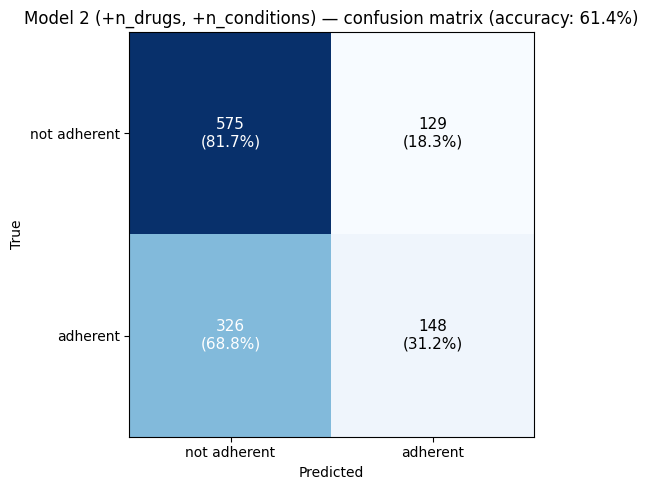

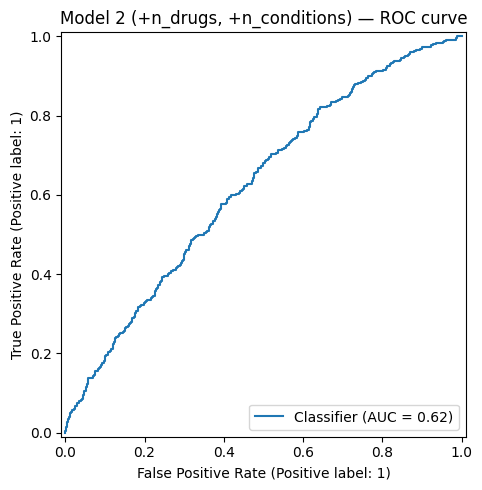


Top 15 by gain:


,gain
ICD_E78,0.101785
ICD_I10,0.037650
RX_LAMOTRIGINE,0.022560
RX_FLUTICASONE,0.021751
AGE23X,0.020264
ICD_E03,0.018754
RX_LEVOTHYROXIN,0.017962
INSCOV_UNINSURED,0.017494
BLACK,0.017439
RX_AMLODIPINE,0.017043


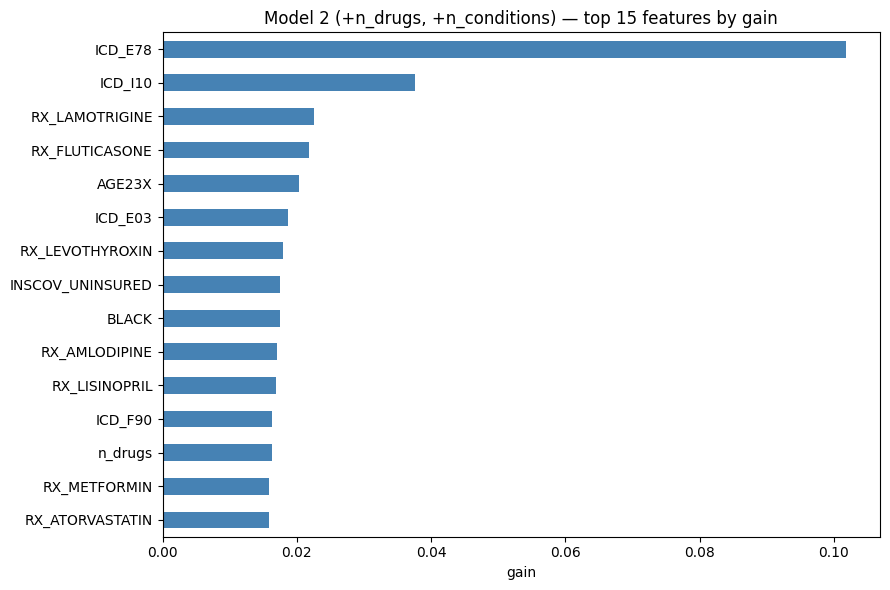


Top 15 by mean |SHAP| (n=500):


,mean_abs_shap
ICD_E78,0.175083
AGE23X,0.127354
ICD_I10,0.099555
n_drugs,0.065145
REGIONXX,0.056866
FAMINC23,0.053484
medication_dose,0.053300
RX_FLUTICASONE,0.051382
RX_LISINOPRIL,0.051116
BLACK,0.041311


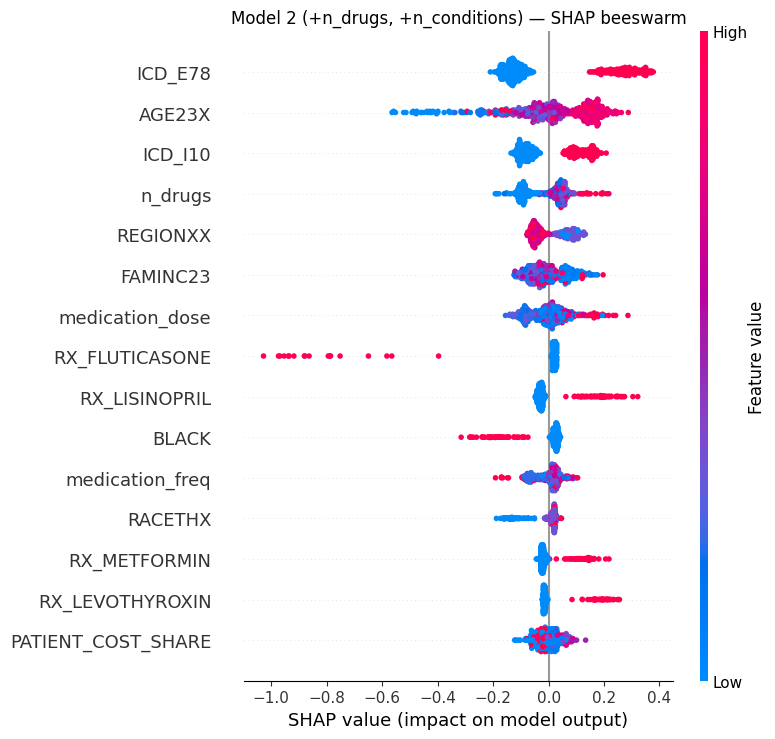

In [524]:
# ============================================================================
# Model 2 — + n_drugs + n_conditions
# ============================================================================
# Model 1 + polypharmacy count (n_drugs) + comorbidity count (n_conditions). Answers: do those two count features add signal on top of the RXNAME dummies?
#
# Self-contained: builds its own X/y, runs HalvingGridSearchCV on the full
# XGB_PARAM_GRID from cell 101, prints holdout metrics, then Gini (gain) and
# SHAP for interpretability. Uses the shared plot_cm_with_recall helper from
# cell 89 for the confusion matrix (recall % per row + accuracy in title).
# All plots use separate figures so they do NOT overlap.

RANDOM_STATE_M2 = 42
TEST_SIZE_M2   = 0.2
CV_FOLDS_M2    = 5
TOP_N_M2       = 15
SHAP_SAMPLE_M2 = 500

# --- build feature matrix ---
_LEAK_M2 = ["DUPERSID", "is_adherent", "meps_adherence_ratio",
              "total_valid_days", "total_days_supply", "drug_start_days"]

def _build_m2(df):
    y = df["is_adherent"].astype(int)
    X = df.drop(columns=[c for c in _LEAK_M2 if c in df.columns], errors="ignore").copy()
    # n_drugs / n_conditions kept as features (polypharmacy + comorbidity signal)
    # (no extra categoricals for this model)
    X = X.select_dtypes(include=[np.number, "bool"]).astype(np.float32)
    return X.fillna(-999.0), y

X_m2, y_m2 = _build_m2(model_df)
print(f"Model 2 (+ n_drugs + n_conditions): {X_m2.shape[1]} features, {len(X_m2):,} rows")

X_tr_m2, X_te_m2, y_tr_m2, y_te_m2 = train_test_split(
    X_m2, y_m2,
    test_size=TEST_SIZE_M2,
    random_state=RANDOM_STATE_M2,
    stratify=y_m2,
)

# --- HalvingGridSearchCV on the full XGB_PARAM_GRID ---
cv_m2 = StratifiedKFold(n_splits=CV_FOLDS_M2, shuffle=True, random_state=RANDOM_STATE_M2)
search_m2 = HalvingGridSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic", eval_metric="auc",
        tree_method="hist", n_jobs=1,
        random_state=RANDOM_STATE_M2, verbosity=0,
    ),
    param_grid=XGB_PARAM_GRID,
    scoring="roc_auc",
    cv=cv_m2,
    factor=3,
    resource="n_samples",
    random_state=RANDOM_STATE_M2,
    n_jobs=-1,
    verbose=1,
    refit=True,
)
_t0 = time.perf_counter()
search_m2.fit(X_tr_m2, y_tr_m2)
model_m2 = search_m2.best_estimator_
print(f"\nHalving done in {(time.perf_counter() - _t0)/60:.1f} min | "
      f"iterations={search_m2.n_iterations_}")
print(f"Best CV AUC: {search_m2.best_score_:.4f}")
print(f"Best params: {search_m2.best_params_}")

# --- holdout metrics ---
pred_m2  = model_m2.predict(X_te_m2)
proba_m2 = model_m2.predict_proba(X_te_m2)[:, 1]
print(f"\nTest AUC:       {roc_auc_score(y_te_m2, proba_m2):.4f}")
print(f"Test F1:        {f1_score(y_te_m2, pred_m2):.4f}")
print(f"Test precision: {precision_score(y_te_m2, pred_m2):.4f}")
print(f"Test recall:    {recall_score(y_te_m2, pred_m2):.4f}")
print("\nClassification report:")
print(classification_report(y_te_m2, pred_m2, digits=3))

# --- Plot 1: confusion matrix (separate figure) ---
fig1, ax1 = plt.subplots(figsize=(6, 5))
plot_cm_with_recall(
    confusion_matrix(y_te_m2, pred_m2),
    ax1,
    "Model 2 (+n_drugs, +n_conditions) — confusion matrix",
)
plt.tight_layout()
plt.show()

# --- Plot 2: ROC curve (separate figure) ---
fig2, ax2 = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_te_m2, proba_m2, ax=ax2)
ax2.set_title("Model 2 (+n_drugs, +n_conditions) — ROC curve")
plt.tight_layout()
plt.show()

# --- Plot 3: Gini (gain) top-N (separate figure) ---
gain_m2 = (
    pd.Series(model_m2.feature_importances_, index=X_tr_m2.columns)
    .sort_values(ascending=False)
)
print(f"\nTop {TOP_N_M2} by gain:")
display(gain_m2.head(TOP_N_M2).to_frame("gain"))

fig3, ax3 = plt.subplots(figsize=(9, 6))
gain_m2.head(TOP_N_M2).iloc[::-1].plot(kind="barh", ax=ax3, color="steelblue")
ax3.set_xlabel("gain")
ax3.set_title(f"Model 2 (+n_drugs, +n_conditions) — top {TOP_N_M2} features by gain")
plt.tight_layout()
plt.show()

# --- Plot 4: SHAP beeswarm (separate figure) ---
X_shap_m2 = X_tr_m2.sample(
    n=min(SHAP_SAMPLE_M2, len(X_tr_m2)),
    random_state=RANDOM_STATE_M2,
)
explainer_m2 = shap.TreeExplainer(model_m2)
shap_values_m2 = explainer_m2.shap_values(X_shap_m2)
mean_abs_shap_m2 = (
    pd.Series(np.abs(shap_values_m2).mean(axis=0), index=X_shap_m2.columns)
    .sort_values(ascending=False)
)
print(f"\nTop {TOP_N_M2} by mean |SHAP| (n={len(X_shap_m2)}):")
display(mean_abs_shap_m2.head(TOP_N_M2).to_frame("mean_abs_shap"))

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_m2,
    X_shap_m2,
    max_display=TOP_N_M2,
    show=False,
)
plt.title(f"Model 2 (+n_drugs, +n_conditions) — SHAP beeswarm")
plt.tight_layout()
plt.show()


Model 3 (drug class instead of drug name): 162 features, 5,889 rows
n_iterations: 5
n_required_iterations: 6
n_possible_iterations: 5
min_resources_: 20
max_resources_: 4711
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 576
n_resources: 20
Fitting 5 folds for each of 576 candidates, totalling 2880 fits
----------
iter: 1
n_candidates: 192
n_resources: 60
Fitting 5 folds for each of 192 candidates, totalling 960 fits
----------
iter: 2
n_candidates: 64
n_resources: 180
Fitting 5 folds for each of 64 candidates, totalling 320 fits
----------
iter: 3
n_candidates: 22
n_resources: 540
Fitting 5 folds for each of 22 candidates, totalling 110 fits
----------
iter: 4
n_candidates: 8
n_resources: 1620
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Halving done in 1.8 min | iterations=5
Best CV AUC: 0.6316
Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'reg_lambda': 1.0, 'subsampl

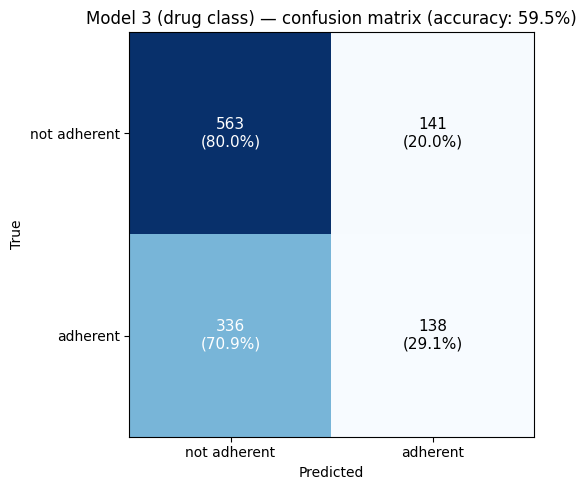

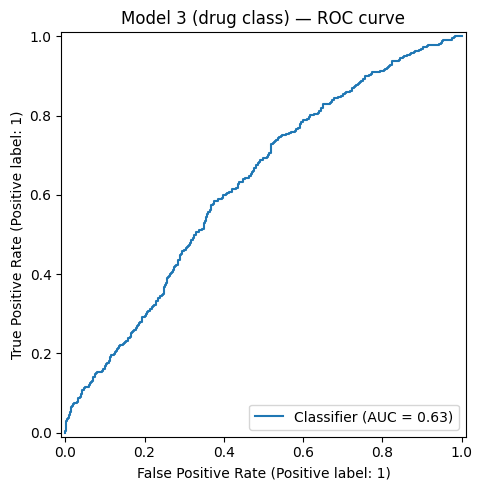


Top 15 by gain:


,gain
TC1S1_19,0.089144
ICD_E78,0.055527
ICD_I10,0.037417
TC1S1_247,0.024453
TC1S1_99,0.022185
AGE23X,0.022073
TC1S1_42,0.020046
ICD_E03,0.019471
INSCOV_UNINSURED,0.018840
TC1S1_194,0.018558


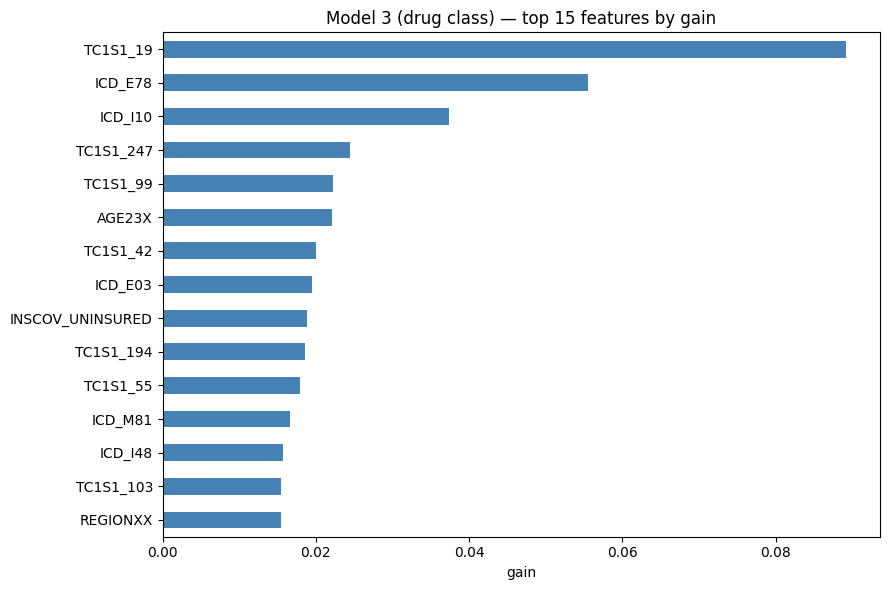


Top 15 by mean |SHAP| (n=500):


,mean_abs_shap
TC1S1_19,0.130324
AGE23X,0.104868
ICD_E78,0.079867
ICD_I10,0.069314
TC1S1_42,0.052268
n_drugs,0.048510
TC1S1_247,0.045034
TC1S1_55,0.044244
REGIONXX,0.038670
medication_dose,0.034762


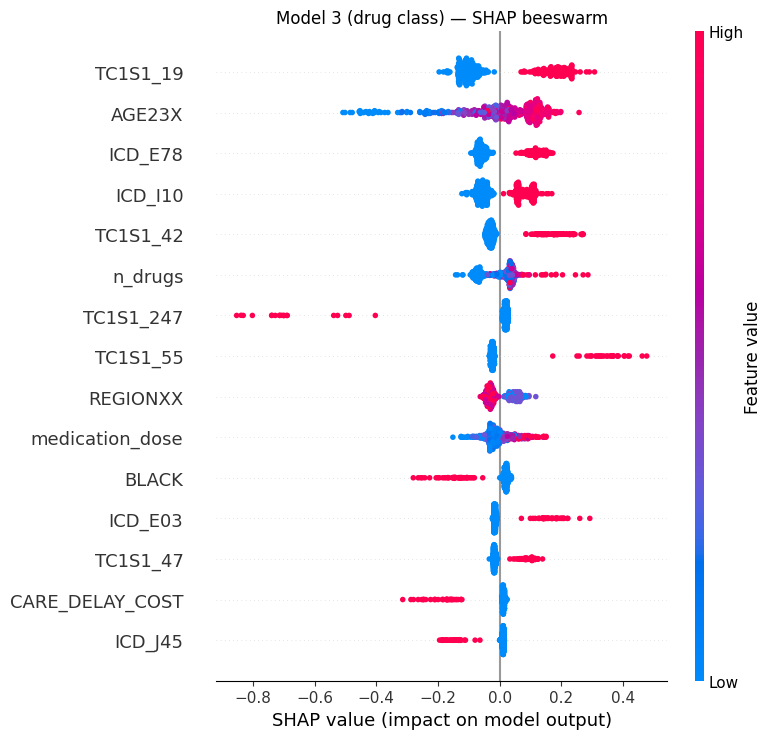

In [525]:
# ============================================================================
# Model 3 — drug class instead of drug name
# ============================================================================
# Model 2 with RXNAME dummies REPLACED by TC1/TC1S1 drug-class dummies (already in model_df_no_rx_tc). Answers: does a coarser drug representation (class not name) generalize better? Keeps n_drugs and n_conditions from Model 2.
#
# Self-contained: builds its own X/y, runs HalvingGridSearchCV on the full
# XGB_PARAM_GRID from cell 101, prints holdout metrics, then Gini (gain) and
# SHAP for interpretability. Uses the shared plot_cm_with_recall helper from
# cell 89 for the confusion matrix (recall % per row + accuracy in title).
# All plots use separate figures so they do NOT overlap.

RANDOM_STATE_M3 = 42
TEST_SIZE_M3   = 0.2
CV_FOLDS_M3    = 5
TOP_N_M3       = 15
SHAP_SAMPLE_M3 = 500

# --- build feature matrix ---
_LEAK_M3 = ["DUPERSID", "is_adherent", "meps_adherence_ratio",
              "total_valid_days", "total_days_supply", "drug_start_days"]

def _build_m3(df):
    y = df["is_adherent"].astype(int)
    X = df.drop(columns=[c for c in _LEAK_M3 if c in df.columns], errors="ignore").copy()
    X = X.drop(columns=[c for c in X.columns if c.startswith("RX_")], errors="ignore")
    # n_drugs / n_conditions kept as features (polypharmacy + comorbidity signal)
    # (no extra categoricals for this model)
    X = X.select_dtypes(include=[np.number, "bool"]).astype(np.float32)
    return X.fillna(-999.0), y

X_m3, y_m3 = _build_m3(model_df_no_rx_tc)
print(f"Model 3 (drug class instead of drug name): {X_m3.shape[1]} features, {len(X_m3):,} rows")

X_tr_m3, X_te_m3, y_tr_m3, y_te_m3 = train_test_split(
    X_m3, y_m3,
    test_size=TEST_SIZE_M3,
    random_state=RANDOM_STATE_M3,
    stratify=y_m3,
)

# --- HalvingGridSearchCV on the full XGB_PARAM_GRID ---
cv_m3 = StratifiedKFold(n_splits=CV_FOLDS_M3, shuffle=True, random_state=RANDOM_STATE_M3)
search_m3 = HalvingGridSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic", eval_metric="auc",
        tree_method="hist", n_jobs=1,
        random_state=RANDOM_STATE_M3, verbosity=0,
    ),
    param_grid=XGB_PARAM_GRID,
    scoring="roc_auc",
    cv=cv_m3,
    factor=3,
    resource="n_samples",
    random_state=RANDOM_STATE_M3,
    n_jobs=-1,
    verbose=1,
    refit=True,
)
_t0 = time.perf_counter()
search_m3.fit(X_tr_m3, y_tr_m3)
model_m3 = search_m3.best_estimator_
print(f"\nHalving done in {(time.perf_counter() - _t0)/60:.1f} min | "
      f"iterations={search_m3.n_iterations_}")
print(f"Best CV AUC: {search_m3.best_score_:.4f}")
print(f"Best params: {search_m3.best_params_}")

# --- holdout metrics ---
pred_m3  = model_m3.predict(X_te_m3)
proba_m3 = model_m3.predict_proba(X_te_m3)[:, 1]
print(f"\nTest AUC:       {roc_auc_score(y_te_m3, proba_m3):.4f}")
print(f"Test F1:        {f1_score(y_te_m3, pred_m3):.4f}")
print(f"Test precision: {precision_score(y_te_m3, pred_m3):.4f}")
print(f"Test recall:    {recall_score(y_te_m3, pred_m3):.4f}")
print("\nClassification report:")
print(classification_report(y_te_m3, pred_m3, digits=3))

# --- Plot 1: confusion matrix (separate figure) ---
fig1, ax1 = plt.subplots(figsize=(6, 5))
plot_cm_with_recall(
    confusion_matrix(y_te_m3, pred_m3),
    ax1,
    "Model 3 (drug class) — confusion matrix",
)
plt.tight_layout()
plt.show()

# --- Plot 2: ROC curve (separate figure) ---
fig2, ax2 = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_te_m3, proba_m3, ax=ax2)
ax2.set_title("Model 3 (drug class) — ROC curve")
plt.tight_layout()
plt.show()

# --- Plot 3: Gini (gain) top-N (separate figure) ---
gain_m3 = (
    pd.Series(model_m3.feature_importances_, index=X_tr_m3.columns)
    .sort_values(ascending=False)
)
print(f"\nTop {TOP_N_M3} by gain:")
display(gain_m3.head(TOP_N_M3).to_frame("gain"))

fig3, ax3 = plt.subplots(figsize=(9, 6))
gain_m3.head(TOP_N_M3).iloc[::-1].plot(kind="barh", ax=ax3, color="steelblue")
ax3.set_xlabel("gain")
ax3.set_title(f"Model 3 (drug class) — top {TOP_N_M3} features by gain")
plt.tight_layout()
plt.show()

# --- Plot 4: SHAP beeswarm (separate figure) ---
X_shap_m3 = X_tr_m3.sample(
    n=min(SHAP_SAMPLE_M3, len(X_tr_m3)),
    random_state=RANDOM_STATE_M3,
)
explainer_m3 = shap.TreeExplainer(model_m3)
shap_values_m3 = explainer_m3.shap_values(X_shap_m3)
mean_abs_shap_m3 = (
    pd.Series(np.abs(shap_values_m3).mean(axis=0), index=X_shap_m3.columns)
    .sort_values(ascending=False)
)
print(f"\nTop {TOP_N_M3} by mean |SHAP| (n={len(X_shap_m3)}):")
display(mean_abs_shap_m3.head(TOP_N_M3).to_frame("mean_abs_shap"))

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_m3,
    X_shap_m3,
    max_display=TOP_N_M3,
    show=False,
)
plt.title(f"Model 3 (drug class) — SHAP beeswarm")
plt.tight_layout()
plt.show()


Model 4 (paper-enriched): 183 features, 5,889 rows
n_iterations: 5
n_required_iterations: 6
n_possible_iterations: 5
min_resources_: 20
max_resources_: 4711
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 576
n_resources: 20
Fitting 5 folds for each of 576 candidates, totalling 2880 fits
----------
iter: 1
n_candidates: 192
n_resources: 60
Fitting 5 folds for each of 192 candidates, totalling 960 fits
----------
iter: 2
n_candidates: 64
n_resources: 180
Fitting 5 folds for each of 64 candidates, totalling 320 fits
----------
iter: 3
n_candidates: 22
n_resources: 540
Fitting 5 folds for each of 22 candidates, totalling 110 fits
----------
iter: 4
n_candidates: 8
n_resources: 1620
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Halving done in 1.7 min | iterations=5
Best CV AUC: 0.6280
Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 200, 'reg_lambda': 5.0, 'subsample': 1.0}

Test AU

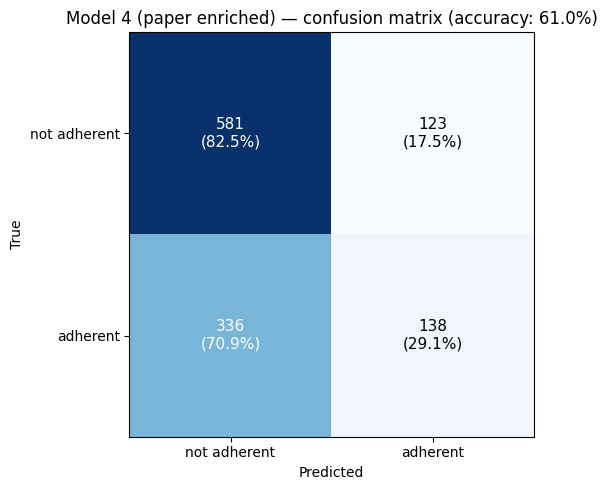

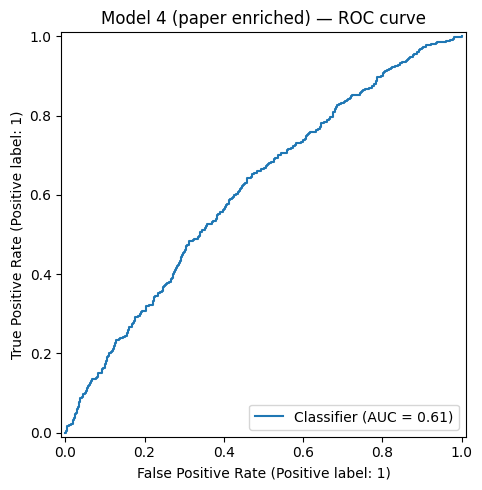


Top 15 by gain:


,gain
TC1S1_19,0.147134
ICD_I10,0.046420
ICD_E78,0.043815
TC1S1_247,0.026725
INSCOV_UNINSURED,0.018285
ICD_E03,0.018039
TC1S1_23,0.017238
TC1S1_55,0.016478
TC1S1_103,0.016000
TC1S1_101,0.014577


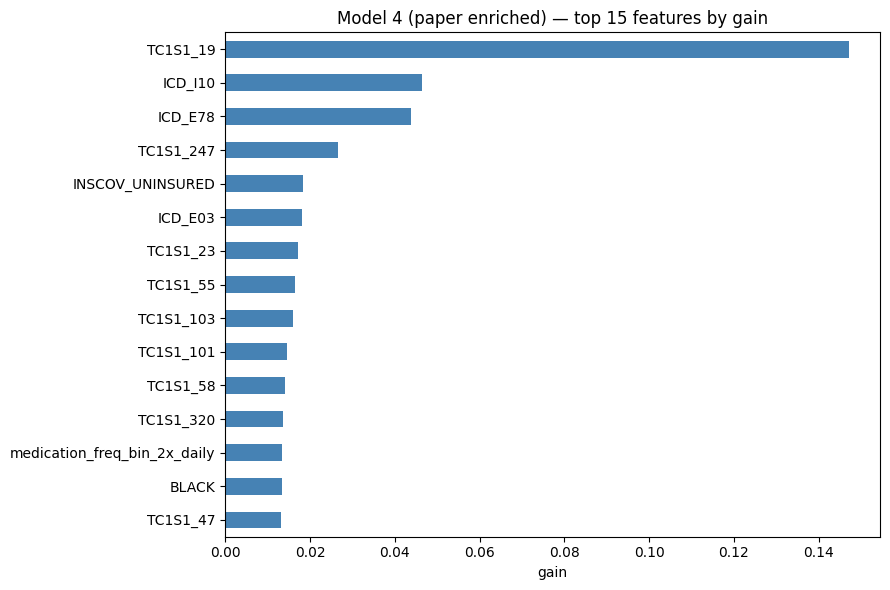


Top 15 by mean |SHAP| (n=500):


,mean_abs_shap
TC1S1_19,0.139864
AGE23X,0.109141
ICD_E78,0.077926
ICD_I10,0.073693
medication_dose,0.042551
TC1S1_42,0.039623
TC1S1_247,0.037387
FAMINC23,0.032547
n_drugs,0.031200
medication_freq,0.028321


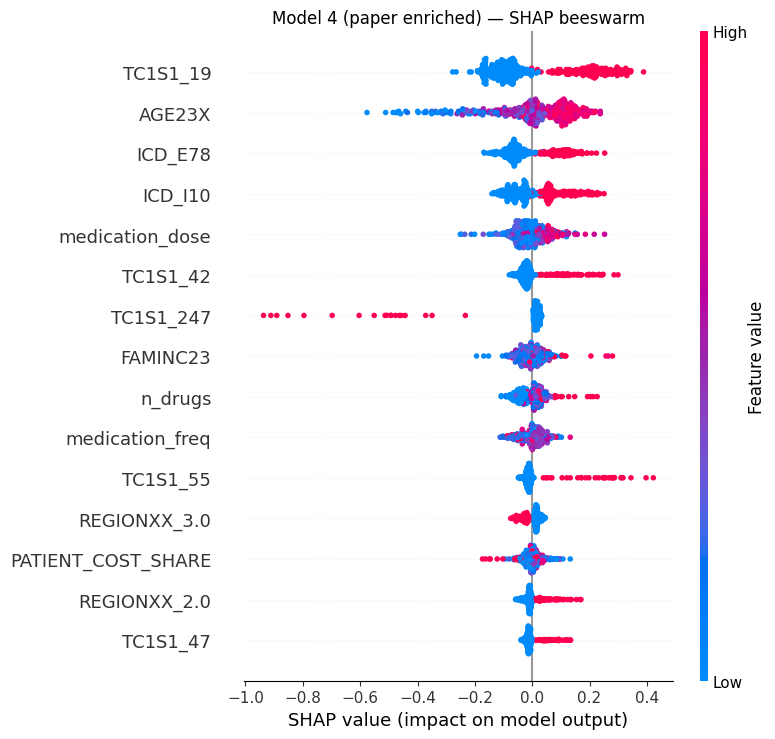

In [526]:
# ============================================================================
# Model 4 — paper-enriched
# ============================================================================
# Model 3 + socioeconomic (MARRYXX, REGIONXX, EDUCYR, RACETHX one-hot) + medication_dose + medication_freq + medication_freq_bin (one-hot). Tests the scoping review's 'socioeconomic factors are strong predictors' recommendation and Toy et al.'s dosing-frequency finding.
#
# Self-contained: builds its own X/y, runs HalvingGridSearchCV on the full
# XGB_PARAM_GRID from cell 101, prints holdout metrics, then Gini (gain) and
# SHAP for interpretability. Uses the shared plot_cm_with_recall helper from
# cell 89 for the confusion matrix (recall % per row + accuracy in title).
# All plots use separate figures so they do NOT overlap.

RANDOM_STATE_M4 = 42
TEST_SIZE_M4   = 0.2
CV_FOLDS_M4    = 5
TOP_N_M4       = 15
SHAP_SAMPLE_M4 = 500

# --- build feature matrix ---
_LEAK_M4 = ["DUPERSID", "is_adherent", "meps_adherence_ratio",
              "total_valid_days", "total_days_supply", "drug_start_days"]

def _build_m4(df):
    y = df["is_adherent"].astype(int)
    X = df.drop(columns=[c for c in _LEAK_M4 if c in df.columns], errors="ignore").copy()
    X = X.drop(columns=[c for c in X.columns if c.startswith("RX_")], errors="ignore")
    # n_drugs / n_conditions kept as features (polypharmacy + comorbidity signal)
    for _c in ["MARRYXX", "REGIONXX", "RACETHX", "medication_freq_bin"]:
        if _c in X.columns:
            X = pd.get_dummies(X, columns=[_c], prefix=_c, dummy_na=True)
    X = X.select_dtypes(include=[np.number, "bool"]).astype(np.float32)
    return X.fillna(-999.0), y

X_m4, y_m4 = _build_m4(model_df_no_rx_tc)
print(f"Model 4 (paper-enriched): {X_m4.shape[1]} features, {len(X_m4):,} rows")

X_tr_m4, X_te_m4, y_tr_m4, y_te_m4 = train_test_split(
    X_m4, y_m4,
    test_size=TEST_SIZE_M4,
    random_state=RANDOM_STATE_M4,
    stratify=y_m4,
)

# --- HalvingGridSearchCV on the full XGB_PARAM_GRID ---
cv_m4 = StratifiedKFold(n_splits=CV_FOLDS_M4, shuffle=True, random_state=RANDOM_STATE_M4)
search_m4 = HalvingGridSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic", eval_metric="auc",
        tree_method="hist", n_jobs=1,
        random_state=RANDOM_STATE_M4, verbosity=0,
    ),
    param_grid=XGB_PARAM_GRID,
    scoring="roc_auc",
    cv=cv_m4,
    factor=3,
    resource="n_samples",
    random_state=RANDOM_STATE_M4,
    n_jobs=-1,
    verbose=1,
    refit=True,
)
_t0 = time.perf_counter()
search_m4.fit(X_tr_m4, y_tr_m4)
model_m4 = search_m4.best_estimator_
print(f"\nHalving done in {(time.perf_counter() - _t0)/60:.1f} min | "
      f"iterations={search_m4.n_iterations_}")
print(f"Best CV AUC: {search_m4.best_score_:.4f}")
print(f"Best params: {search_m4.best_params_}")

# --- holdout metrics ---
pred_m4  = model_m4.predict(X_te_m4)
proba_m4 = model_m4.predict_proba(X_te_m4)[:, 1]
print(f"\nTest AUC:       {roc_auc_score(y_te_m4, proba_m4):.4f}")
print(f"Test F1:        {f1_score(y_te_m4, pred_m4):.4f}")
print(f"Test precision: {precision_score(y_te_m4, pred_m4):.4f}")
print(f"Test recall:    {recall_score(y_te_m4, pred_m4):.4f}")
print("\nClassification report:")
print(classification_report(y_te_m4, pred_m4, digits=3))

# --- Plot 1: confusion matrix (separate figure) ---
fig1, ax1 = plt.subplots(figsize=(6, 5))
plot_cm_with_recall(
    confusion_matrix(y_te_m4, pred_m4),
    ax1,
    "Model 4 (paper enriched) — confusion matrix",
)
plt.tight_layout()
plt.show()

# --- Plot 2: ROC curve (separate figure) ---
fig2, ax2 = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_te_m4, proba_m4, ax=ax2)
ax2.set_title("Model 4 (paper enriched) — ROC curve")
plt.tight_layout()
plt.show()

# --- Plot 3: Gini (gain) top-N (separate figure) ---
gain_m4 = (
    pd.Series(model_m4.feature_importances_, index=X_tr_m4.columns)
    .sort_values(ascending=False)
)
print(f"\nTop {TOP_N_M4} by gain:")
display(gain_m4.head(TOP_N_M4).to_frame("gain"))

fig3, ax3 = plt.subplots(figsize=(9, 6))
gain_m4.head(TOP_N_M4).iloc[::-1].plot(kind="barh", ax=ax3, color="steelblue")
ax3.set_xlabel("gain")
ax3.set_title(f"Model 4 (paper enriched) — top {TOP_N_M4} features by gain")
plt.tight_layout()
plt.show()

# --- Plot 4: SHAP beeswarm (separate figure) ---
X_shap_m4 = X_tr_m4.sample(
    n=min(SHAP_SAMPLE_M4, len(X_tr_m4)),
    random_state=RANDOM_STATE_M4,
)
explainer_m4 = shap.TreeExplainer(model_m4)
shap_values_m4 = explainer_m4.shap_values(X_shap_m4)
mean_abs_shap_m4 = (
    pd.Series(np.abs(shap_values_m4).mean(axis=0), index=X_shap_m4.columns)
    .sort_values(ascending=False)
)
print(f"\nTop {TOP_N_M4} by mean |SHAP| (n={len(X_shap_m4)}):")
display(mean_abs_shap_m4.head(TOP_N_M4).to_frame("mean_abs_shap"))

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_m4,
    X_shap_m4,
    max_display=TOP_N_M4,
    show=False,
)
plt.title(f"Model 4 (paper enriched) — SHAP beeswarm")
plt.tight_layout()
plt.show()


In [527]:
model_df.columns.tolist()

['DUPERSID',
 'AGE23X',
 'FAMINC23',
 'is_adherent',
 'INSCOV_PRIVATE',
 'INSCOV_PUBLIC',
 'INSCOV_UNINSURED',
 'MALE',
 'FEMALE',
 'WHITE',
 'BLACK',
 'AMER_INDIAN',
 'ASIAN_INDIAN',
 'CHINESE',
 'FILIPINO',
 'PMED_DELAY_COST',
 'NO_PMED_DELAY_COST',
 'CARE_DELAY_COST',
 'NO_CARE_DELAY_COST',
 'POV_POOR',
 'POV_NEAR_POOR',
 'POV_LOW',
 'POV_MIDDLE',
 'POV_HIGH',
 'RX_5-AMINOSALICYLATES',
 'RX_ABILIFY MAIN',
 'RX_ACE INHIBITORS WITH THIAZIDES',
 'RX_ADDERALL XR',
 'RX_ADMELOG',
 'RX_ADVAIR DISKU',
 'RX_ADVAIR HFA',
 'RX_AIRDUO DGHLR',
 'RX_ALENDRONATE',
 'RX_ALLOPURINOL',
 'RX_ALPHA-ADRENORECEPTOR ANTAGONISTS',
 'RX_ALPHAGAN P',
 'RX_AMIODARONE',
 'RX_AMITRIPTYLIN',
 'RX_AMLOD/BENAZP',
 'RX_AMLODIPINE',
 'RX_AMLODIPINE BESYLATE',
 'RX_AMLODIPINE BESYLATE TAB',
 'RX_AMPHET/DEXTR',
 'RX_AMPHETAMINE ER TAB',
 'RX_ANASTROZOLE',
 'RX_ANGIOTENSIN CONVERTING ENZYME (ACE) INHIBITORS',
 'RX_ANGIOTENSIN II INHIBITORS',
 'RX_ANGIOTENSIN II INHIBITORS WITH THIAZIDES',
 'RX_ANTIANGINAL AGENTS',
 'R

In [528]:
model_df_no_rx_tc.columns.tolist()


['DUPERSID',
 'AGE23X',
 'FAMINC23',
 'is_adherent',
 'INSCOV_PRIVATE',
 'INSCOV_PUBLIC',
 'INSCOV_UNINSURED',
 'MALE',
 'FEMALE',
 'WHITE',
 'BLACK',
 'AMER_INDIAN',
 'ASIAN_INDIAN',
 'CHINESE',
 'FILIPINO',
 'PMED_DELAY_COST',
 'NO_PMED_DELAY_COST',
 'CARE_DELAY_COST',
 'NO_CARE_DELAY_COST',
 'POV_POOR',
 'POV_NEAR_POOR',
 'POV_LOW',
 'POV_MIDDLE',
 'POV_HIGH',
 'ICD_C18',
 'ICD_C34',
 'ICD_C44',
 'ICD_C50',
 'ICD_C61',
 'ICD_C67',
 'ICD_C73',
 'ICD_C95',
 'ICD_E03',
 'ICD_E05',
 'ICD_E11',
 'ICD_E28',
 'ICD_E29',
 'ICD_E34',
 'ICD_E78',
 'ICD_F03',
 'ICD_F19',
 'ICD_F20',
 'ICD_F31',
 'ICD_F32',
 'ICD_F39',
 'ICD_F41',
 'ICD_F84',
 'ICD_F90',
 'ICD_F99',
 'ICD_G20',
 'ICD_G25',
 'ICD_G40',
 'ICD_G47',
 'ICD_G62',
 'ICD_H35',
 'ICD_H40',
 'ICD_H54',
 'ICD_I10',
 'ICD_I20',
 'ICD_I25',
 'ICD_I48',
 'ICD_I49',
 'ICD_I50',
 'ICD_I51',
 'ICD_J30',
 'ICD_J32',
 'ICD_J42',
 'ICD_J43',
 'ICD_J44',
 'ICD_J45',
 'ICD_K21',
 'ICD_K50',
 'ICD_K57',
 'ICD_K58',
 'ICD_K59',
 'ICD_K76',
 'ICD_M06'